# Nuclear Energy Pipeline (Lower Frequency)
Daily Belgium electricity preparation, nuclear prediction-market integration, model evaluation, scenario branching, and hedge sizing.

## 1) Electricity Data Preparation
Load and clean Belgium electricity prices for 2025, aggregate to daily frequency, and construct a balanced daily panel.

In [3]:
import pandas as pd

# Source requested: GUI day-ahead Belgium price export
file_path = "GUI_ENERGY_PRICES_202412312300-202512312300.csv"
target_year = 2025

start_utc = pd.Timestamp(f"{target_year}-01-01 00:00:00", tz="UTC")
end_utc = pd.Timestamp(f"{target_year + 1}-01-01 00:00:00", tz="UTC")

raw = pd.read_csv(file_path)
required_cols = ["MTU (CET/CEST)", "Area", "Day-ahead Price (EUR/MWh)"]
missing = [c for c in required_cols if c not in raw.columns]
if missing:
    raise ValueError(f"Missing required GUI columns: {missing}")

# Parse start of MTU interval in Europe/Brussels and convert to UTC
mtu_start = raw["MTU (CET/CEST)"].astype(str).str.split(" - ").str[0]
dt_local = pd.to_datetime(mtu_start, dayfirst=True, errors="coerce")
try:
    dt_utc = dt_local.dt.tz_localize("Europe/Brussels", ambiguous="infer", nonexistent="shift_forward").dt.tz_convert("UTC")
except Exception:
    dt_utc = dt_local.dt.tz_localize("Europe/Brussels", ambiguous="NaT", nonexistent="shift_forward").dt.tz_convert("UTC")

work = raw.copy()
work["Datetime (UTC)"] = dt_utc
work = work.dropna(subset=["Datetime (UTC)"])
work = work[(work["Datetime (UTC)"] >= start_utc) & (work["Datetime (UTC)"] < end_utc)].copy()

# Keep Belgium bidding zone rows where available
if "Area" in work.columns:
    be_mask = work["Area"].astype(str).str.contains(r"BZN\|BE", regex=True, na=False)
    if be_mask.any():
        work = work.loc[be_mask].copy()

work["Price (EUR/MWhe)"] = pd.to_numeric(work["Day-ahead Price (EUR/MWh)"], errors="coerce")
work = work.dropna(subset=["Price (EUR/MWhe)"])
work["Country"] = "Belgium"
work["ISO3 Code"] = "BEL"

df_2025 = work[["Country", "ISO3 Code", "Datetime (UTC)", "Price (EUR/MWhe)"]].sort_values("Datetime (UTC)").reset_index(drop=True)

print(df_2025.shape)
print(df_2025.head())

(35026, 4)
   Country ISO3 Code            Datetime (UTC)  Price (EUR/MWhe)
0  Belgium       BEL 2025-01-01 00:00:00+00:00             10.27
1  Belgium       BEL 2025-01-01 00:15:00+00:00             10.27
2  Belgium       BEL 2025-01-01 00:30:00+00:00             10.27
3  Belgium       BEL 2025-01-01 00:45:00+00:00             10.27
4  Belgium       BEL 2025-01-01 01:00:00+00:00              8.38


In [4]:
# Daily average electricity price per country (2025)
df_2025["Date"] = df_2025["Datetime (UTC)"].dt.floor("D")

daily_avg_2025 = (
    df_2025.groupby(["Country", "Date"], as_index=False)["Price (EUR/MWhe)"]
    .mean()
    .rename(columns={"Price (EUR/MWhe)": "Daily Avg Price (EUR/MWhe)"})
    .sort_values(["Country", "Date"], ignore_index=True)
)

print(daily_avg_2025.shape)
print(daily_avg_2025.head())

(365, 3)
   Country                      Date  Daily Avg Price (EUR/MWhe)
0  Belgium 2025-01-01 00:00:00+00:00                   23.627083
1  Belgium 2025-01-02 00:00:00+00:00                  115.652083
2  Belgium 2025-01-03 00:00:00+00:00                  120.500833
3  Belgium 2025-01-04 00:00:00+00:00                  122.087500
4  Belgium 2025-01-05 00:00:00+00:00                   53.136667


In [5]:
# Build balanced daily panel and combined dataset (Europe + country columns)
# 1) Keep country-days with complete intraday coverage
hour_counts = (
    df_2025.assign(Date=df_2025["Datetime (UTC)"].dt.floor("D"))
    .groupby(["Country", "Date"], as_index=False)
    .size()
    .rename(columns={"size": "hours"})
)

if hour_counts.empty:
    raise ValueError("No country-day observations available after filtering df_2025.")

# GUI feed is quarter-hourly (typically 96 points/day), but infer dynamically.
expected_points = int(hour_counts["hours"].mode().iloc[0])
complete_country_days = hour_counts[hour_counts["hours"] == expected_points][["Country", "Date"]]

daily_country_complete = (
    daily_avg_2025
    .merge(complete_country_days, on=["Country", "Date"], how="inner")
    .copy()
)

# 2) Keep only dates with constant country set (balanced panel)
countries_per_day = daily_country_complete.groupby("Date")["Country"].nunique()
if countries_per_day.empty:
    raise ValueError("No balanced daily rows after intraday completeness filter.")

max_countries = int(countries_per_day.max())
all_dates_2025 = countries_per_day[countries_per_day == max_countries].index

balanced_daily_country = daily_country_complete[
    daily_country_complete["Date"].isin(all_dates_2025)
].copy()

# 3) Europe daily average from balanced panel
europe_daily_avg_2025 = (
    balanced_daily_country.groupby("Date", as_index=False)["Daily Avg Price (EUR/MWhe)"]
    .mean()
    .rename(columns={"Daily Avg Price (EUR/MWhe)": "Europe Daily Avg Price (EUR/MWhe)"})
)

# 4) Wide country matrix + Europe
country_daily_wide = (
    balanced_daily_country
    .pivot(index="Date", columns="Country", values="Daily Avg Price (EUR/MWhe)")
    .sort_index()
)
country_daily_wide = country_daily_wide.add_prefix("Country Avg - ")

combined_daily_2025 = (
    europe_daily_avg_2025
    .set_index("Date")
    .join(country_daily_wide, how="inner")
    .reset_index()
    .sort_values("Date", ignore_index=True)
)

print("Expected intraday points/day:", expected_points)
print("Balanced countries per day:", max_countries)
print("Balanced dates:", len(all_dates_2025))
print(combined_daily_2025.shape)
print(combined_daily_2025.head())

Expected intraday points/day: 96
Balanced countries per day: 1
Balanced dates: 362
(362, 3)
                       Date  Europe Daily Avg Price (EUR/MWhe)  \
0 2025-01-01 00:00:00+00:00                          23.627083   
1 2025-01-02 00:00:00+00:00                         115.652083   
2 2025-01-03 00:00:00+00:00                         120.500833   
3 2025-01-04 00:00:00+00:00                         122.087500   
4 2025-01-05 00:00:00+00:00                          53.136667   

   Country Avg - Belgium  
0              23.627083  
1             115.652083  
2             120.500833  
3             122.087500  
4              53.136667  


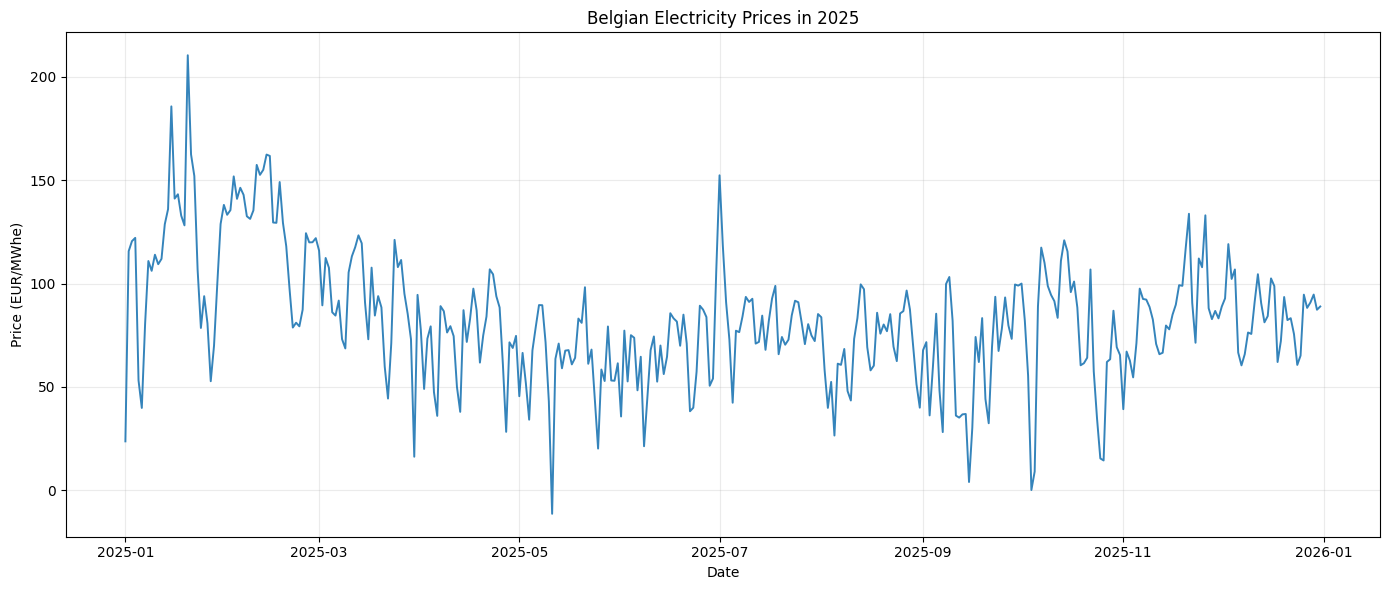

In [6]:
import matplotlib.pyplot as plt

plot_df = daily_avg_2025.dropna(subset=["Date", "Daily Avg Price (EUR/MWhe)"]).copy()
plot_df["Date"] = pd.to_datetime(plot_df["Date"])

fig, ax = plt.subplots(figsize=(14, 6))
for country, country_df in plot_df.groupby("Country"):
    ax.plot(
        country_df["Date"],
        country_df["Daily Avg Price (EUR/MWhe)"],
        linewidth=1.4,
        alpha=0.9,
        color="#1f77b4",
    )

ax.set_title("Belgian Electricity Prices in 2025")
ax.set_xlabel("Date")
ax.set_ylabel("Price (EUR/MWhe)")
ax.grid(True, alpha=0.25)
fig.tight_layout()
plt.show()

## 2) Weather and Prediction-Market Inputs
Load Belgium weather data and local nuclear prediction-market data, then build the daily aligned modeling table.

In [7]:
# Belgium daily weather (2025) using Open-Meteo, merged to energy dataset
import openmeteo_requests
import pandas as pd
import requests_cache
from retry_requests import retry

# Set up a cached + retried API client
cache_session = requests_cache.CachedSession(".cache", expire_after=3600)
retry_session = retry(cache_session, retries=5, backoff_factor=0.2)
openmeteo = openmeteo_requests.Client(session=retry_session)

# Brussels as a Belgium proxy
url = "https://archive-api.open-meteo.com/v1/archive"
params = {
    "latitude": 50.8503,
    "longitude": 4.3517,
    "start_date": "2025-01-01",
    "end_date": "2025-12-31",
    "daily": ["temperature_2m_mean", "temperature_2m_min", "temperature_2m_max", "precipitation_sum", "wind_speed_10m_mean"],
    "timezone": "UTC"
}

responses = openmeteo.weather_api(url, params=params)
response = responses[0]
daily = response.Daily()

belgium_weather_2025 = pd.DataFrame({
    "Date": pd.date_range(
        start=pd.to_datetime(daily.Time(), unit="s", utc=True),
        end=pd.to_datetime(daily.TimeEnd(), unit="s", utc=True),
        freq=pd.Timedelta(seconds=daily.Interval()),
        inclusive="left"
    ),
    "BE Temp Avg (C)": daily.Variables(0).ValuesAsNumpy(),
    "BE Temp Min (C)": daily.Variables(1).ValuesAsNumpy(),
    "BE Temp Max (C)": daily.Variables(2).ValuesAsNumpy(),
    "BE Precipitation (mm)": daily.Variables(3).ValuesAsNumpy(),
    "BE Wind Speed (km/h)": daily.Variables(4).ValuesAsNumpy(),
})

combined_daily_2025_with_be_weather = combined_daily_2025.merge(
    belgium_weather_2025,
    on="Date",
    how="left"
)

print(belgium_weather_2025.head())
print(combined_daily_2025_with_be_weather.shape)
print(combined_daily_2025_with_be_weather.head())

                       Date  BE Temp Avg (C)  BE Temp Min (C)  \
0 2025-01-01 00:00:00+00:00         6.604167             2.95   
1 2025-01-02 00:00:00+00:00         2.904167             0.90   
2 2025-01-03 00:00:00+00:00         0.687500            -1.05   
3 2025-01-04 00:00:00+00:00         1.004167            -0.65   
4 2025-01-05 00:00:00+00:00         7.585416             0.80   

   BE Temp Max (C)  BE Precipitation (mm)  BE Wind Speed (km/h)  
0             8.80              11.000000             27.924313  
1             5.45               8.000000             10.333981  
2             2.70               0.000000             13.145383  
3             2.30               0.100000              9.542207  
4            11.60              26.399998             22.833347  
(362, 8)
                       Date  Europe Daily Avg Price (EUR/MWhe)  \
0 2025-01-01 00:00:00+00:00                          23.627083   
1 2025-01-02 00:00:00+00:00                         115.652083   
2 2025

In [8]:
# Daily weather compatibility frame (2025)
# Keep a timestamp-based view for downstream cells that expect this variable name.
if "belgium_weather_2025" not in globals() or belgium_weather_2025.empty:
    raise ValueError("Run the Belgium daily weather cell first.")

belgium_weather_hourly_pm = belgium_weather_2025.rename(
    columns={
        "Date": "timestamp",
        "BE Temp Avg (C)": "BE Temp (C)",
    }
).copy()

# Ensure UTC-aware daily timestamp
belgium_weather_hourly_pm["timestamp"] = pd.to_datetime(
    belgium_weather_hourly_pm["timestamp"], utc=True, errors="coerce"
).dt.floor("D")

keep_cols = ["timestamp", "BE Temp (C)", "BE Precipitation (mm)", "BE Wind Speed (km/h)"]
existing_cols = [c for c in keep_cols if c in belgium_weather_hourly_pm.columns]
belgium_weather_hourly_pm = belgium_weather_hourly_pm[existing_cols].dropna(subset=["timestamp"]).reset_index(drop=True)

print("Daily weather compatibility frame prepared:", belgium_weather_hourly_pm.shape)
print(belgium_weather_hourly_pm.head())

Daily weather compatibility frame prepared: (365, 4)
                  timestamp  BE Temp (C)  BE Precipitation (mm)  \
0 2025-01-01 00:00:00+00:00     6.604167              11.000000   
1 2025-01-02 00:00:00+00:00     2.904167               8.000000   
2 2025-01-03 00:00:00+00:00     0.687500               0.000000   
3 2025-01-04 00:00:00+00:00     1.004167               0.100000   
4 2025-01-05 00:00:00+00:00     7.585416              26.399998   

   BE Wind Speed (km/h)  
0             27.924313  
1             10.333981  
2             13.145383  
3              9.542207  
4             22.833347  


In [9]:
# CSV-only: local PM hourly market data (last month)
from pathlib import Path
import pandas as pd

csv_candidates = [
    "pm_hourly_last_month_pipeline_wide.csv",
    "pm_hourly_last_month.csv",
]

chosen_path = None
for p in csv_candidates:
    if Path(p).exists():
        chosen_path = p
        break

if chosen_path is None:
    raise FileNotFoundError(
        "No local PM hourly CSV found. Expected one of: " + ", ".join(csv_candidates)
    )

pm_hourly_last_month = pd.read_csv(chosen_path)

required_cols = {"timestamp", "price_Yes", "price_No"}
missing = required_cols - set(pm_hourly_last_month.columns)
if missing:
    raise ValueError(f"Missing required columns in {chosen_path}: {sorted(missing)}")

pm_hourly_last_month["timestamp"] = pd.to_datetime(
    pm_hourly_last_month["timestamp"], utc=True, errors="coerce"
 )
pm_hourly_last_month = (
    pm_hourly_last_month
    .dropna(subset=["timestamp"] )
    .sort_values("timestamp")
    .drop_duplicates(subset=["timestamp"], keep="last")
    .reset_index(drop=True)
)

# Keep compatibility with downstream references
now_utc = pd.Timestamp.now(tz="UTC").floor("h")
window_start = now_utc - pd.Timedelta(days=29)
selected_market = {
    "id": "csv_source",
    "question": "Nuclear PM (from local CSV)",
    "title": "Nuclear PM (from local CSV)",
    "slug": "nuclear-pm-csv",
}
source_used = f"local_csv:{chosen_path}"
scored_candidates = []
candidate_markets = [selected_market]

print("Selected market:", selected_market["question"] )
print("Market id:", selected_market["id"] )
print("Data source used:", source_used)
print("Rows:", pm_hourly_last_month.shape)
print(pm_hourly_last_month.head())

Selected market: Nuclear PM (from local CSV)
Market id: csv_source
Data source used: local_csv:pm_hourly_last_month_pipeline_wide.csv
Rows: (50, 3)
                  timestamp  price_No  price_Yes
0 2026-02-26 12:00:00+00:00  0.760526   0.239474
1 2026-02-26 13:00:00+00:00  0.760000   0.240000
2 2026-02-26 14:00:00+00:00  0.760000   0.240000
3 2026-02-26 15:00:00+00:00  0.760000   0.240000
4 2026-02-26 16:00:00+00:00  0.760000   0.240000


In [8]:
# CSV-only retry alias: provide compatibility variables without API calls
import pandas as pd

if "pm_hourly_last_month" not in globals() or pm_hourly_last_month is None or pm_hourly_last_month.empty:
    raise ValueError("Run the CSV-only PM hourly load cell first.")

pm_hourly_last_month_retry2 = pm_hourly_last_month.copy()
selected_market_retry2 = {
    "id": "csv_source",
    "question": "Nuclear Peace Parlay (from local CSV)",
    "slug": "nuclear-peace-parlay-csv",
}
attempt_log2 = [("csv_source", selected_market_retry2["question"], len(pm_hourly_last_month_retry2))]
candidates = []

print("Candidates found:", len(candidates))
print("Top attempted (id, question, status/rows):")
for row in attempt_log2[:12]:
    print(row)

print("\nSelected market:", selected_market_retry2.get("question") or selected_market_retry2.get("slug"))
print("Rows:", pm_hourly_last_month_retry2.shape)
print(pm_hourly_last_month_retry2.head())

Candidates found: 0
Top attempted (id, question, status/rows):
('csv_source', 'Nuclear Peace Parlay (from local CSV)', 50)

Selected market: Nuclear Peace Parlay (from local CSV)
Rows: (50, 3)
                  timestamp  price_No  price_Yes
0 2026-02-26 12:00:00+00:00  0.760526   0.239474
1 2026-02-26 13:00:00+00:00  0.760000   0.240000
2 2026-02-26 14:00:00+00:00  0.760000   0.240000
3 2026-02-26 15:00:00+00:00  0.760000   0.240000
4 2026-02-26 16:00:00+00:00  0.760000   0.240000


In [9]:
# CSV schema debug (replaces remote payload debug)
import pandas as pd

if "pm_hourly_last_month_retry2" in globals() and isinstance(pm_hourly_last_month_retry2, pd.DataFrame) and not pm_hourly_last_month_retry2.empty:
    debug_df = pm_hourly_last_month_retry2.copy()
elif "pm_hourly_last_month" in globals() and isinstance(pm_hourly_last_month, pd.DataFrame) and not pm_hourly_last_month.empty:
    debug_df = pm_hourly_last_month.copy()
else:
    raise ValueError("No PM hourly DataFrame available. Run the CSV-only PM load cell first.")

print("source: local CSV-backed DataFrame")
print("shape:", debug_df.shape)
print("columns:", debug_df.columns.tolist())
print("dtypes:")
print(debug_df.dtypes)
print("head:")
print(debug_df.head())

source: local CSV-backed DataFrame
shape: (50, 3)
columns: ['timestamp', 'price_No', 'price_Yes']
dtypes:
timestamp    datetime64[us, UTC]
price_No                 float64
price_Yes                float64
dtype: object
head:
                  timestamp  price_No  price_Yes
0 2026-02-26 12:00:00+00:00  0.760526   0.239474
1 2026-02-26 13:00:00+00:00  0.760000   0.240000
2 2026-02-26 14:00:00+00:00  0.760000   0.240000
3 2026-02-26 15:00:00+00:00  0.760000   0.240000
4 2026-02-26 16:00:00+00:00  0.760000   0.240000


In [7]:
# Import nuclear daily prediction market (2025) from local CSV
import pandas as pd

def load_daily_pm_csv(path, yes_col_name):
    df = pd.read_csv(path)
    required = {"category", "Yes"}
    if not required.issubset(df.columns):
        raise ValueError(f"{path} must contain columns: {required}")

    out = df[["category", "Yes"]].copy()
    out["Date"] = pd.to_datetime(out["category"], utc=True, errors="coerce").dt.floor("D")
    out = out.dropna(subset=["Date"]).rename(columns={"Yes": yes_col_name})
    out[yes_col_name] = pd.to_numeric(out[yes_col_name], errors="coerce")
    out = out.dropna(subset=[yes_col_name])
    out = out[["Date", yes_col_name]].sort_values("Date").drop_duplicates(subset=["Date"], keep="last")
    return out

pm_nuclear = load_daily_pm_csv("NuclearDetonation.csv", "price_Yes_nuclear")

# Build 2025 daily PM panel
start_utc = pd.Timestamp("2025-01-01", tz="UTC")
end_utc = pd.Timestamp("2026-01-01", tz="UTC")
daily_index_2025 = pd.DataFrame({"Date": pd.date_range(start_utc, end_utc, freq="D", inclusive="left")})

pm_daily_2025 = (
    daily_index_2025
    .merge(pm_nuclear, on="Date", how="left")
    .sort_values("Date", ignore_index=True)
)

# Fill gaps with time interpolation + carry edges for clean daily alignment
pm_daily_2025["price_Yes_nuclear"] = pm_daily_2025["price_Yes_nuclear"].interpolate(method="linear", limit_direction="both")

# Backward-compatible single-market aliases for downstream cells
pm_daily_2025["price_Yes"] = pm_daily_2025["price_Yes_nuclear"]
pm_daily_2025["price_No"] = 1.0 - pm_daily_2025["price_Yes"]

print("Daily PM panel built:", pm_daily_2025.shape)
print(pm_daily_2025.head())
print(pm_daily_2025.tail())

Daily PM panel built: (365, 4)
                       Date  price_Yes_nuclear  price_Yes  price_No
0 2025-01-01 00:00:00+00:00               0.22       0.22      0.78
1 2025-01-02 00:00:00+00:00               0.20       0.20      0.80
2 2025-01-03 00:00:00+00:00               0.19       0.19      0.81
3 2025-01-04 00:00:00+00:00               0.18       0.18      0.82
4 2025-01-05 00:00:00+00:00               0.18       0.18      0.82
                         Date  price_Yes_nuclear  price_Yes  price_No
360 2025-12-27 00:00:00+00:00              0.002      0.002     0.998
361 2025-12-28 00:00:00+00:00              0.002      0.002     0.998
362 2025-12-29 00:00:00+00:00              0.001      0.001     0.999
363 2025-12-30 00:00:00+00:00              0.001      0.001     0.999
364 2025-12-31 00:00:00+00:00              0.001      0.001     0.999


In [8]:
# Save two-market daily PM data, then build a daily aligned dataset for 2025
if "pm_daily_2025" not in globals() or pm_daily_2025.empty:
    raise ValueError("Run the two-market PM import cell first.")
if "combined_daily_2025_with_be_weather" not in globals() or combined_daily_2025_with_be_weather.empty:
    raise ValueError("Run electricity + weather daily prep cells first.")

pm_csv_path = "pm_two_markets_daily_2025.csv"
pm_daily_2025.to_csv(pm_csv_path, index=False)

energy_daily = combined_daily_2025_with_be_weather.copy()
energy_daily["Date"] = pd.to_datetime(energy_daily["Date"], utc=True, errors="coerce").dt.floor("D")

# Add daily Belgium load factors from local load CSV
load_path = "Belgium 2025 hourly load.csv"
load_raw = pd.read_csv(load_path)
load_required = ["MTU (CET/CEST)", "Actual Total Load (MW)", "Day-ahead Total Load Forecast (MW)"]
missing_load_cols = [c for c in load_required if c not in load_raw.columns]
if missing_load_cols:
    raise ValueError(f"Missing required load columns in {load_path}: {missing_load_cols}")

load_start = load_raw["MTU (CET/CEST)"].astype(str).str.split(" - ").str[0]
load_dt_local = pd.to_datetime(load_start, dayfirst=True, errors="coerce")
try:
    load_dt_utc = load_dt_local.dt.tz_localize("Europe/Brussels", ambiguous="infer", nonexistent="shift_forward").dt.tz_convert("UTC")
except Exception:
    load_dt_utc = load_dt_local.dt.tz_localize("Europe/Brussels", ambiguous="NaT", nonexistent="shift_forward").dt.tz_convert("UTC")

load_work = load_raw.copy()
load_work["timestamp"] = load_dt_utc
load_work = load_work.dropna(subset=["timestamp"]).copy()
load_work = load_work[(load_work["timestamp"] >= pd.Timestamp("2025-01-01", tz="UTC")) & (load_work["timestamp"] < pd.Timestamp("2026-01-01", tz="UTC"))].copy()

load_work["Actual Total Load (MW)"] = pd.to_numeric(load_work["Actual Total Load (MW)"], errors="coerce")
load_work["Day-ahead Total Load Forecast (MW)"] = pd.to_numeric(load_work["Day-ahead Total Load Forecast (MW)"], errors="coerce")
load_work = load_work.dropna(subset=["Actual Total Load (MW)", "Day-ahead Total Load Forecast (MW)"])
load_work["Date"] = load_work["timestamp"].dt.floor("D")

load_daily = (
    load_work.groupby("Date", as_index=False)
    .agg(
        {
            "Actual Total Load (MW)": "mean",
            "Day-ahead Total Load Forecast (MW)": "mean",
        }
    )
    .sort_values("Date")
)
load_daily["pct_BE_actual_load"] = load_daily["Actual Total Load (MW)"].pct_change() * 100
load_daily["pct_BE_forecast_load"] = load_daily["Day-ahead Total Load Forecast (MW)"].pct_change() * 100
load_daily["pct_BE_forecast_vs_actual_load"] = (
    load_daily["Day-ahead Total Load Forecast (MW)"] / load_daily["Actual Total Load (MW)"] - 1.0
) * 100

load_keep = ["Date", "pct_BE_actual_load", "pct_BE_forecast_load", "pct_BE_forecast_vs_actual_load"]
energy_daily = energy_daily.merge(load_daily[load_keep], on="Date", how="left")

# Select Belgium daily electricity level with robust fallback names
belgium_candidates = [
    "Country Avg - Belgium",
    "Daily Avg Price (EUR/MWhe)",
    "Country Hourly - Belgium",
]
belgium_col = next((c for c in belgium_candidates if c in energy_daily.columns), None)
if belgium_col is None:
    raise ValueError("Could not find Belgium daily electricity column in combined_daily_2025_with_be_weather.")

daily_aligned = (
    pm_daily_2025
    .merge(energy_daily, on="Date", how="left")
    .sort_values("Date", ignore_index=True)
)

# Keep columns needed downstream and create backward-compatible names
if belgium_col != "Country Hourly - Belgium":
    daily_aligned["Country Hourly - Belgium"] = daily_aligned[belgium_col]
if "BE Temp (C)" not in daily_aligned.columns and "BE Temp Avg (C)" in daily_aligned.columns:
    daily_aligned["BE Temp (C)"] = daily_aligned["BE Temp Avg (C)"]

# Use timestamp name expected by later cells
daily_aligned["timestamp"] = pd.to_datetime(daily_aligned["Date"], utc=True, errors="coerce").dt.floor("D")

preferred_cols = [
    "timestamp",
    "price_No",
    "price_Yes",
    "price_Yes_nuclear",
    "Country Hourly - Belgium",
    "BE Temp (C)",
    "BE Precipitation (mm)",
    "BE Wind Speed (km/h)",
    "pct_BE_actual_load",
    "pct_BE_forecast_load",
    "pct_BE_forecast_vs_actual_load",
]
existing_cols = [c for c in preferred_cols if c in daily_aligned.columns]
hourly_aligned = daily_aligned[existing_cols].copy().sort_values("timestamp", ignore_index=True)

aligned_csv_path = "daily_aligned_with_two_pm_2025.csv"
hourly_aligned.to_csv(aligned_csv_path, index=False)

print("Saved:", pm_csv_path)
print("Saved:", aligned_csv_path)
print("Final columns:", hourly_aligned.columns.tolist())
print("daily aligned shape:", hourly_aligned.shape)
print(hourly_aligned.head())

Saved: pm_two_markets_daily_2025.csv
Saved: daily_aligned_with_two_pm_2025.csv
Final columns: ['timestamp', 'price_No', 'price_Yes', 'price_Yes_nuclear', 'Country Hourly - Belgium', 'BE Temp (C)', 'BE Precipitation (mm)', 'BE Wind Speed (km/h)', 'pct_BE_actual_load', 'pct_BE_forecast_load', 'pct_BE_forecast_vs_actual_load']
daily aligned shape: (365, 11)
                  timestamp  price_No  price_Yes  price_Yes_nuclear  \
0 2025-01-01 00:00:00+00:00      0.78       0.22               0.22   
1 2025-01-02 00:00:00+00:00      0.80       0.20               0.20   
2 2025-01-03 00:00:00+00:00      0.81       0.19               0.19   
3 2025-01-04 00:00:00+00:00      0.82       0.18               0.18   
4 2025-01-05 00:00:00+00:00      0.82       0.18               0.18   

   Country Hourly - Belgium  BE Temp (C)  BE Precipitation (mm)  \
0                 23.627083     6.604167              11.000000   
1                115.652083     2.904167               8.000000   
2              

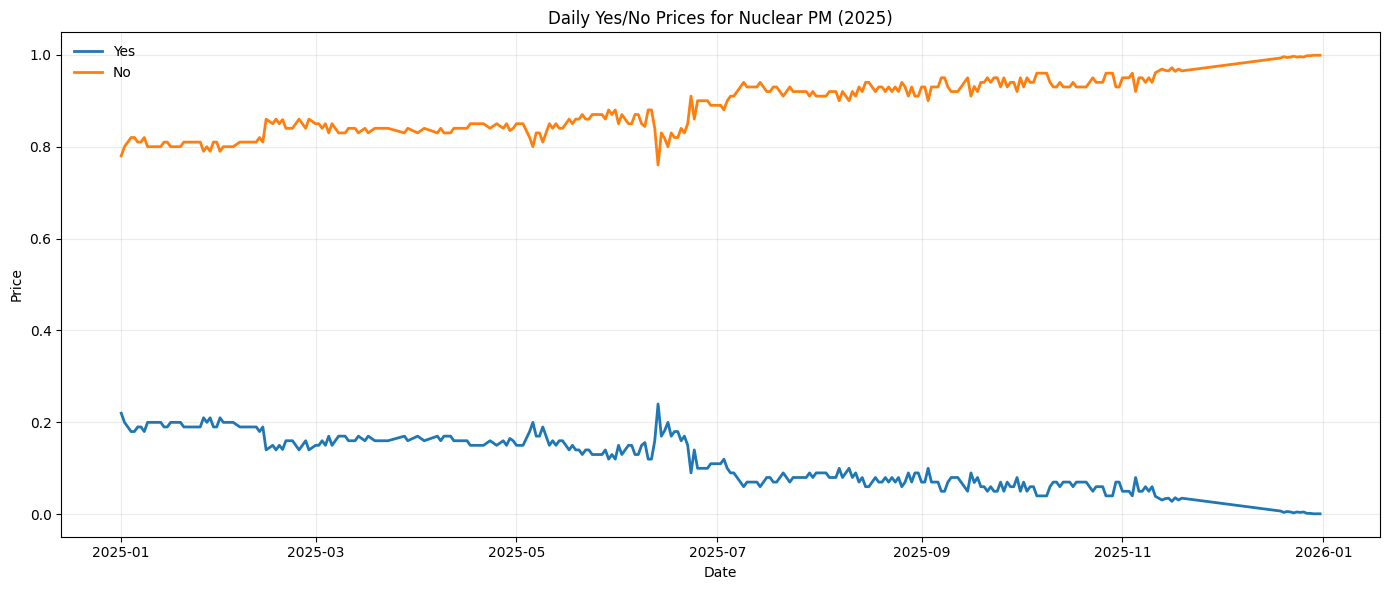

In [12]:
import matplotlib.pyplot as plt

pm_source = None
for candidate_name in ["pm_daily_2025", "pm_hourly_last_month_retry2", "pm_hourly_last_month"]:
    candidate = globals().get(candidate_name)
    if isinstance(candidate, pd.DataFrame) and not candidate.empty:
        pm_source = candidate.copy()
        break

if pm_source is None:
    raise ValueError("No PM price dataframe available for plotting yes/no prices.")

time_col = next((c for c in ["timestamp", "Datetime (UTC)", "Date"] if c in pm_source.columns), None)
if time_col is None:
    raise ValueError("Could not find a time column for the PM price plot.")

pm_source[time_col] = pd.to_datetime(pm_source[time_col], errors="coerce")
pm_source = pm_source.dropna(subset=[time_col]).copy()
pm_source["Date"] = pm_source[time_col].dt.floor("D")

price_cols = [c for c in ["price_Yes", "price_No"] if c in pm_source.columns]
if len(price_cols) < 2:
    raise ValueError("Could not find both price_Yes and price_No columns.")

pm_daily_prices = (
    pm_source.groupby("Date", as_index=False)[price_cols]
    .mean()
    .sort_values("Date")
)

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(pm_daily_prices["Date"], pm_daily_prices["price_Yes"], label="Yes", linewidth=2)
ax.plot(pm_daily_prices["Date"], pm_daily_prices["price_No"], label="No", linewidth=2)
ax.set_title("Daily Yes/No Prices for Nuclear PM (2025)")
ax.set_xlabel("Date")
ax.set_ylabel("Price")
ax.legend(frameon=False)
ax.grid(True, alpha=0.25)
fig.tight_layout()
plt.show()

In [13]:
# UTC audit + alignment for daily PM, electricity, weather, and final aligned dataset

def _ensure_utc(series):
    s = pd.to_datetime(series, errors="coerce")
    if getattr(s.dt, "tz", None) is None:
        return s.dt.tz_localize("UTC")
    return s.dt.tz_convert("UTC")

if "pm_daily_2025" not in globals() or pm_daily_2025.empty:
    raise ValueError("pm_daily_2025 is missing. Run the two-market PM import cell first.")
if "df_2025" not in globals() or df_2025.empty:
    raise ValueError("df_2025 is missing. Run the electricity import cell first.")
if "belgium_weather_2025" not in globals() or belgium_weather_2025.empty:
    raise ValueError("belgium_weather_2025 is missing. Run the weather cell first.")
if "hourly_aligned" not in globals() or hourly_aligned.empty:
    raise ValueError("hourly_aligned is missing. Run the daily alignment cell first.")

# Align all core time columns to UTC
pm_daily_2025["Date"] = _ensure_utc(pm_daily_2025["Date"])
df_2025["Datetime (UTC)"] = _ensure_utc(df_2025["Datetime (UTC)"])
belgium_weather_2025["Date"] = _ensure_utc(belgium_weather_2025["Date"])
hourly_aligned["timestamp"] = _ensure_utc(hourly_aligned["timestamp"])

pm_tz = str(pm_daily_2025["Date"].dt.tz)
elec_tz = str(df_2025["Datetime (UTC)"].dt.tz)
weather_tz = str(belgium_weather_2025["Date"].dt.tz)
final_tz = str(hourly_aligned["timestamp"].dt.tz)

print("PM Date tz:", pm_tz)
print("Electricity Datetime (UTC) tz:", elec_tz)
print("Weather Date tz:", weather_tz)
print("Final DF timestamp tz:", final_tz)

if not all(tz == "UTC" for tz in [pm_tz, elec_tz, weather_tz, final_tz]):
    raise ValueError("One or more time columns are not UTC after alignment.")

print("All core time columns are aligned to UTC.")

PM Date tz: UTC
Electricity Datetime (UTC) tz: UTC
Weather Date tz: UTC
Final DF timestamp tz: UTC
All core time columns are aligned to UTC.


## 3) Time Alignment and Feature Transformations
Validate UTC alignment across sources and generate differenced and percent-change feature datasets for downstream modeling.

In [14]:
# Build differenced dataset: difference all series, while retaining PM prices in levels too
hourly_aligned_diff = hourly_aligned.copy().sort_values("timestamp").reset_index(drop=True)

# Numeric columns to difference
numeric_cols = [c for c in hourly_aligned_diff.columns if c != "timestamp"]

# First differences
diff_values = hourly_aligned_diff[numeric_cols].diff()
diff_values = diff_values.rename(columns={c: f"d_{c}" for c in numeric_cols})

# Keep PM prices in levels as requested
level_cols = ["timestamp", "price_No", "price_Yes"]
level_cols = [c for c in level_cols if c in hourly_aligned_diff.columns]

hourly_aligned_diff = pd.concat([
    hourly_aligned_diff[level_cols],
    diff_values,
], axis=1)

# Drop first row with NaN diffs
hourly_aligned_diff = hourly_aligned_diff.dropna().reset_index(drop=True)

# Save
hourly_diff_csv_path = "hourly_aligned_with_pm_window_differences.csv"
hourly_aligned_diff.to_csv(hourly_diff_csv_path, index=False)

print("Saved:", hourly_diff_csv_path)
print("Shape:", hourly_aligned_diff.shape)
print("Columns:", hourly_aligned_diff.columns.tolist())
print(hourly_aligned_diff.head())

Saved: hourly_aligned_with_pm_window_differences.csv
Shape: (358, 13)
Columns: ['timestamp', 'price_No', 'price_Yes', 'd_price_No', 'd_price_Yes', 'd_price_Yes_nuclear', 'd_Country Hourly - Belgium', 'd_BE Temp (C)', 'd_BE Precipitation (mm)', 'd_BE Wind Speed (km/h)', 'd_pct_BE_actual_load', 'd_pct_BE_forecast_load', 'd_pct_BE_forecast_vs_actual_load']
                  timestamp  price_No  price_Yes  d_price_No  d_price_Yes  \
0 2025-01-03 00:00:00+00:00      0.81       0.19        0.01        -0.01   
1 2025-01-04 00:00:00+00:00      0.82       0.18        0.01        -0.01   
2 2025-01-05 00:00:00+00:00      0.82       0.18        0.00         0.00   
3 2025-01-06 00:00:00+00:00      0.81       0.19       -0.01         0.01   
4 2025-01-07 00:00:00+00:00      0.81       0.19        0.00         0.00   

   d_price_Yes_nuclear  d_Country Hourly - Belgium  d_BE Temp (C)  \
0                -0.01                    4.848750      -2.216667   
1                -0.01                    1

In [15]:
# Percentage-change dataset: put all series on a common scale (%)
# while retaining PM prices in levels
import numpy as np

hourly_aligned_pct = hourly_aligned.copy().sort_values("timestamp").reset_index(drop=True)

level_cols = [
    c
    for c in [
        "timestamp",
        "price_No",
        "price_Yes",
        "price_Yes_nuclear",
        "price_Yes_nuclear",
    ]
    if c in hourly_aligned_pct.columns
]
numeric_cols = [c for c in hourly_aligned_pct.columns if c not in level_cols]

# pct_change gives fractional changes; multiply by 100 for percent
pct_vals = hourly_aligned_pct[numeric_cols].pct_change() * 100

# Avoid pandas replace edge bug by masking non-finite values directly
pct_vals = pct_vals.mask(~np.isfinite(pct_vals), pd.NA)
pct_vals = pct_vals.rename(columns={c: f"pct_{c}" for c in numeric_cols})

hourly_aligned_pct = pd.concat([
    hourly_aligned_pct[level_cols],
    pct_vals,
], axis=1)

# Keep rows where at least one pct-change feature is valid
pct_cols = [c for c in hourly_aligned_pct.columns if c.startswith("pct_")]
hourly_aligned_pct = hourly_aligned_pct.dropna(how="all", subset=pct_cols).reset_index(drop=True)

hourly_pct_csv_path = "daily_aligned_with_two_pm_2025_pct_changes.csv"
hourly_aligned_pct.to_csv(hourly_pct_csv_path, index=False)

print("Saved:", hourly_pct_csv_path)
print("Shape:", hourly_aligned_pct.shape)
print("Columns:", hourly_aligned_pct.columns.tolist())
print(hourly_aligned_pct.head())

Saved: daily_aligned_with_two_pm_2025_pct_changes.csv
Shape: (359, 12)
Columns: ['timestamp', 'price_No', 'price_Yes', 'price_Yes_nuclear', 'price_Yes_nuclear', 'pct_Country Hourly - Belgium', 'pct_BE Temp (C)', 'pct_BE Precipitation (mm)', 'pct_BE Wind Speed (km/h)', 'pct_pct_BE_actual_load', 'pct_pct_BE_forecast_load', 'pct_pct_BE_forecast_vs_actual_load']
                  timestamp  price_No  price_Yes  price_Yes_nuclear  \
0 2025-01-02 00:00:00+00:00      0.80       0.20               0.20   
1 2025-01-03 00:00:00+00:00      0.81       0.19               0.19   
2 2025-01-04 00:00:00+00:00      0.82       0.18               0.18   
3 2025-01-05 00:00:00+00:00      0.82       0.18               0.18   
4 2025-01-06 00:00:00+00:00      0.81       0.19               0.19   

   price_Yes_nuclear  pct_Country Hourly - Belgium  pct_BE Temp (C)  \
0               0.20                    389.489463       -56.025230   
1               0.19                      4.192531       -76.327118   

## 4) Daily Factor Model and Idiosyncratic Returns
Construct Belgium electricity idiosyncratic returns by removing weather and load-factor structure from daily electricity returns.

In [9]:
# Build BEL idiosyncratic returns from an in-cell PCA factor model (idempotent)
import numpy as np
import pandas as pd

if "hourly_aligned" not in globals() or not isinstance(hourly_aligned, pd.DataFrame):
    raise ValueError("hourly_aligned is required. Run the alignment cell first.")

target_col = "Country Hourly - Belgium"
if target_col not in hourly_aligned.columns:
    raise ValueError(f"Missing target column: {target_col}")

# Enforce factor model inputs: weather + load factors
weather_factor_cols = ["BE Temp (C)", "BE Precipitation (mm)", "BE Wind Speed (km/h)"]
load_factor_cols = ["pct_BE_actual_load", "pct_BE_forecast_load", "pct_BE_forecast_vs_actual_load"]
required_factors = weather_factor_cols + load_factor_cols
missing_factors = [c for c in required_factors if c not in hourly_aligned.columns]
if missing_factors:
    raise ValueError(f"Missing required weather/load factor columns: {missing_factors}")

factor_cols = required_factors

work = hourly_aligned[["timestamp", target_col] + factor_cols].copy().sort_values("timestamp").reset_index(drop=True)
work[[target_col] + factor_cols] = work[[target_col] + factor_cols].interpolate(method="linear", limit_area="inside")
work["BEL_returns"] = work[target_col].pct_change() * 100
ret_df = work[["timestamp", "BEL_returns"] + factor_cols].dropna().copy()

if len(ret_df) < 10:
    raise ValueError(f"Not enough rows to estimate factor model after cleaning: {len(ret_df)}")

# Keep non-constant factors
std = ret_df[factor_cols].std(axis=0, ddof=0)
active = std[std > 0].index.tolist()
if not active:
    raise ValueError("All factor columns are constant after cleaning.")

X_raw = ret_df[active].copy()
y = ret_df["BEL_returns"].copy()
X_mean = X_raw.mean(axis=0)
X_std = X_raw.std(axis=0, ddof=0).replace(0.0, np.nan)
Xz = ((X_raw - X_mean) / X_std).dropna().copy()
y = y.loc[Xz.index]
ts = ret_df.loc[Xz.index, "timestamp"].copy()

Xz_np = Xz.to_numpy(dtype=float)
U, S, Vt = np.linalg.svd(Xz_np, full_matrices=False)
explained = (S**2) / np.sum(S**2)
cum_explained = np.cumsum(explained)
n_components = max(1, int(np.searchsorted(cum_explained, 0.95) + 1))
scores_all = Xz_np @ Vt.T
X_pca = scores_all[:, :n_components]

X_design = np.column_stack([np.ones(len(X_pca)), X_pca])
coef = np.linalg.lstsq(X_design, y.to_numpy(dtype=float), rcond=None)[0]
fitted = X_design @ coef
resid = y.to_numpy(dtype=float) - fitted

loadings = pd.DataFrame(
    Vt[:n_components, :].T,
    index=active,
    columns=[f"PC{i + 1}" for i in range(n_components)],
)

model_out = pd.DataFrame(
    {
        "timestamp": ts.to_numpy(),
        "BEL_returns": y.to_numpy(dtype=float),
        "BEL_fitted": fitted,
        "BEL_idiosyncratic": resid,
    }
)

# Idempotent merge into hourly_aligned
idio_cols = ["BEL_returns", "BEL_fitted", "BEL_idiosyncratic"]
hourly_aligned = hourly_aligned.drop(columns=[c for c in idio_cols if c in hourly_aligned.columns], errors="ignore")
hourly_aligned = hourly_aligned.merge(model_out, on="timestamp", how="left")

# Persist reusable factor-model state for diagnostics and robustness checks
factor_model_state = {
    "target_col": target_col,
    "factor_cols": factor_cols,
    "active_factors": active,
    "timestamps": ts.reset_index(drop=True),
    "X_raw": X_raw.loc[Xz.index].reset_index(drop=True),
    "Xz": Xz.reset_index(drop=True),
    "y": y.reset_index(drop=True),
    "X_mean": X_mean,
    "X_std": X_std,
    "Vt": Vt,
    "singular_values": S,
    "explained_variance_ratio": explained,
    "cumulative_explained_variance": cum_explained,
    "selected_n_components": int(n_components),
    "scores_all": scores_all,
    "pca_loadings": loadings,
    "baseline_fitted": fitted,
    "baseline_residuals": resid,
}

print("BEL idiosyncratic series added.")
print("Rows in model_out:", len(model_out))
print("Active factors:", active)
print("PCA components:", n_components)
print(hourly_aligned[["timestamp", "BEL_returns", "BEL_fitted", "BEL_idiosyncratic"]].tail())

BEL idiosyncratic series added.
Rows in model_out: 363
Active factors: ['BE Temp (C)', 'BE Precipitation (mm)', 'BE Wind Speed (km/h)', 'pct_BE_actual_load', 'pct_BE_forecast_load', 'pct_BE_forecast_vs_actual_load']
PCA components: 5
                    timestamp  BEL_returns  BEL_fitted  BEL_idiosyncratic
360 2025-12-27 00:00:00+00:00    -6.773714   76.192885         -82.966599
361 2025-12-28 00:00:00+00:00     2.945702   41.696337         -38.750635
362 2025-12-29 00:00:00+00:00     4.237631   12.352521          -8.114889
363 2025-12-30 00:00:00+00:00    -7.753242   34.740579         -42.493820
364 2025-12-31 00:00:00+00:00          NaN         NaN                NaN


### Factor Model Validation and Robustness
Validate PCA stability, linear specification adequacy, residual diagnostics, influence/outliers, parameter stability, and out-of-sample residualization performance.

Raw-factor correlation matrix:


,BE Temp (C),BE Precipitation (mm),BE Wind Speed (km/h),pct_BE_actual_load,pct_BE_forecast_load,pct_BE_forecast_vs_actual_load
BE Temp (C),1.000000,-0.059033,-0.015754,-0.024348,-0.023966,0.050054
BE Precipitation (mm),-0.059033,1.000000,0.398933,-0.071448,-0.053507,-0.052038
BE Wind Speed (km/h),-0.015754,0.398933,1.000000,0.016418,0.030475,-0.041277
pct_BE_actual_load,-0.024348,-0.071448,0.016418,1.000000,0.893368,-0.125973
pct_BE_forecast_load,-0.023966,-0.053507,0.030475,0.893368,1.000000,0.106663
pct_BE_forecast_vs_actual_load,0.050054,-0.052038,-0.041277,-0.125973,0.106663,1.000000


PCA loadings (selected components):


,PC1,PC2,PC3,PC4,PC5
BE Temp (C),0.031829,-0.149886,0.573049,-0.801001,0.080445
BE Precipitation (mm),0.096934,0.686566,0.119720,0.032109,0.709588
BE Wind Speed (km/h),0.005245,0.685787,0.203996,-0.052234,-0.696578
pct_BE_actual_load,-0.704600,0.052481,-0.069826,-0.090319,0.042892
pct_BE_forecast_load,-0.702121,0.037584,0.126512,0.067778,0.053516
pct_BE_forecast_vs_actual_load,0.011298,-0.178019,0.771224,0.584711,0.009430


Scree and cumulative explained variance:


,component,explained_variance_ratio,cumulative_explained_variance
0,1,0.317175,0.317175
1,2,0.236078,0.553254
2,3,0.174516,0.727770
3,4,0.160681,0.888451
4,5,0.098774,0.987225
5,6,0.012775,1.000000


Selected number of components (95% variance threshold): 5
Component-count sensitivity:


,k,r2,rmse,resid_std
0,1,0.000124,559.983742,560.756667
1,2,0.001441,559.614866,560.387282
2,3,0.001465,559.608126,560.380532
3,4,0.001511,559.595299,560.367687
4,5,0.011082,556.906799,557.675476
5,6,0.013808,556.138605,556.906222


Linear fit summary (selected PCA components):
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.011
Model:                            OLS   Adj. R-squared:                 -0.003
Method:                 Least Squares   F-statistic:                    0.8001
Date:                Mon, 27 Apr 2026   Prob (F-statistic):              0.550
Time:                        14:27:45   Log-Likelihood:                -2810.1
No. Observations:                 363   AIC:                             5632.
Df Residuals:                     357   BIC:                             5656.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const 

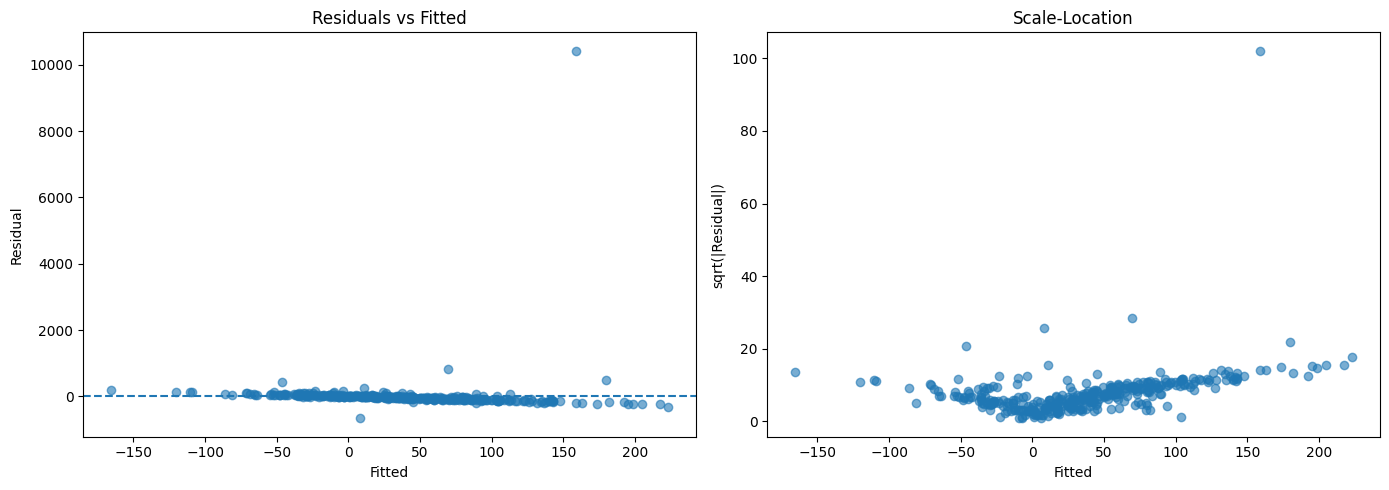

RESET F-stat p-value: 0.05508
Augmented nonlinear specification summary:
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.012
Model:                            OLS   Adj. R-squared:                 -0.011
Method:                 Least Squares   F-statistic:                    0.5218
Date:                Mon, 27 Apr 2026   Prob (F-statistic):              0.840
Time:                        14:27:45   Log-Likelihood:                -2810.0
No. Observations:                 363   AIC:                             5638.
Df Residuals:                     354   BIC:                             5673.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------

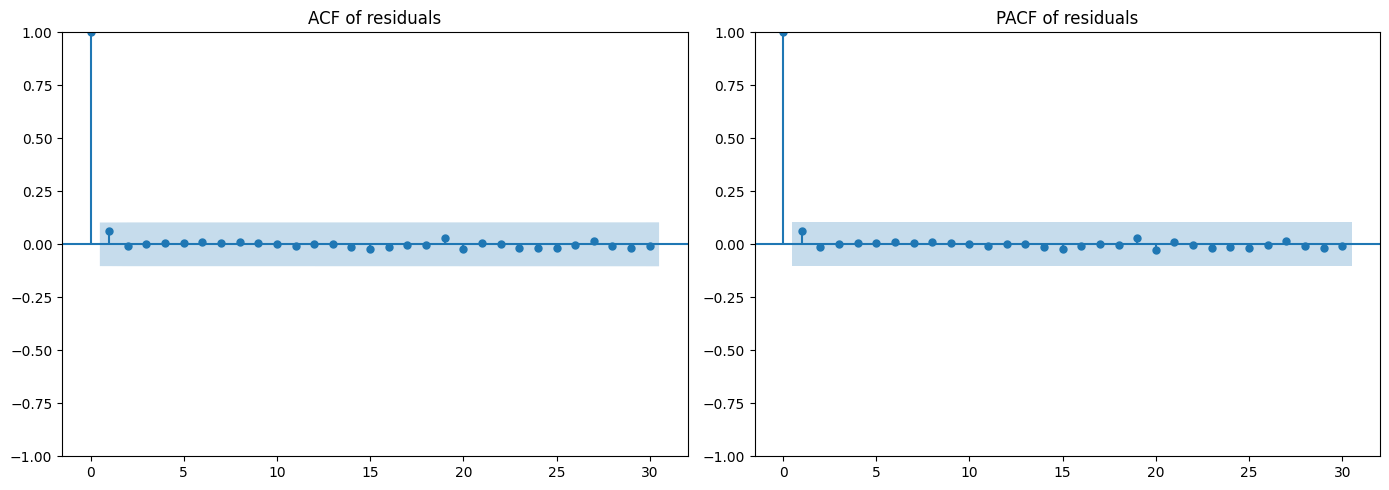

Ljung-Box test:


,lb_stat,lb_pvalue
5,1.532512,0.909288
10,1.643014,0.998417
20,2.495456,0.999999


Durbin-Watson: 1.8717
Heteroskedasticity diagnostics:


,test,stat,p_value
0,Breusch-Pagan,5.016893,0.413822
1,White,16.728068,0.670554
2,ARCH LM (lag=5),0.016758,0.999998


Top 10 influential observations:


,timestamp,leverage,cooks_d,studentized_resid,abs_studentized_resid
276,2025-10-05 00:00:00+00:00,0.016375,0.971862,136.083746,136.083746
277,2025-10-06 00:00:00+00:00,0.019531,0.007144,1.469302,1.469302
0,2025-01-02 00:00:00+00:00,0.056273,0.006342,0.798463,0.798463
130,2025-05-12 00:00:00+00:00,0.023041,0.005632,-1.197707,1.197707
257,2025-09-16 00:00:00+00:00,0.023083,0.002974,0.868736,0.868736
256,2025-09-15 00:00:00+00:00,0.048334,0.002751,-0.569547,0.569547
23,2025-01-25 00:00:00+00:00,0.090583,0.001987,0.345521,0.345521
4,2025-01-06 00:00:00+00:00,0.041504,0.001404,-0.440582,0.440582
275,2025-10-04 00:00:00+00:00,0.060006,0.001283,-0.346786,0.346786
25,2025-01-27 00:00:00+00:00,0.034128,0.001111,-0.433860,0.433860


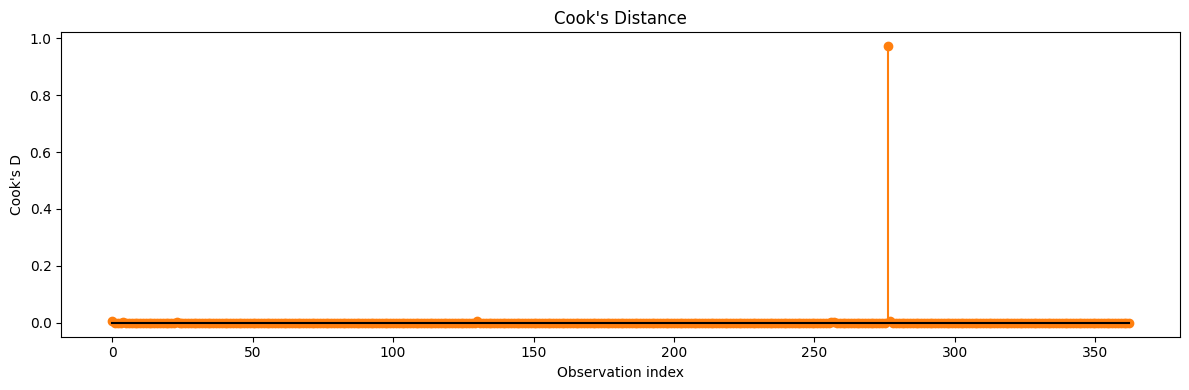

Out-of-sample residualization performance:


,evaluation,RMSE,MAE,R2,n_obs
0,Rolling one-step,622.748553,88.498353,-0.017353,298
1,Chronological holdout,173.215042,143.960198,-31.873666,73


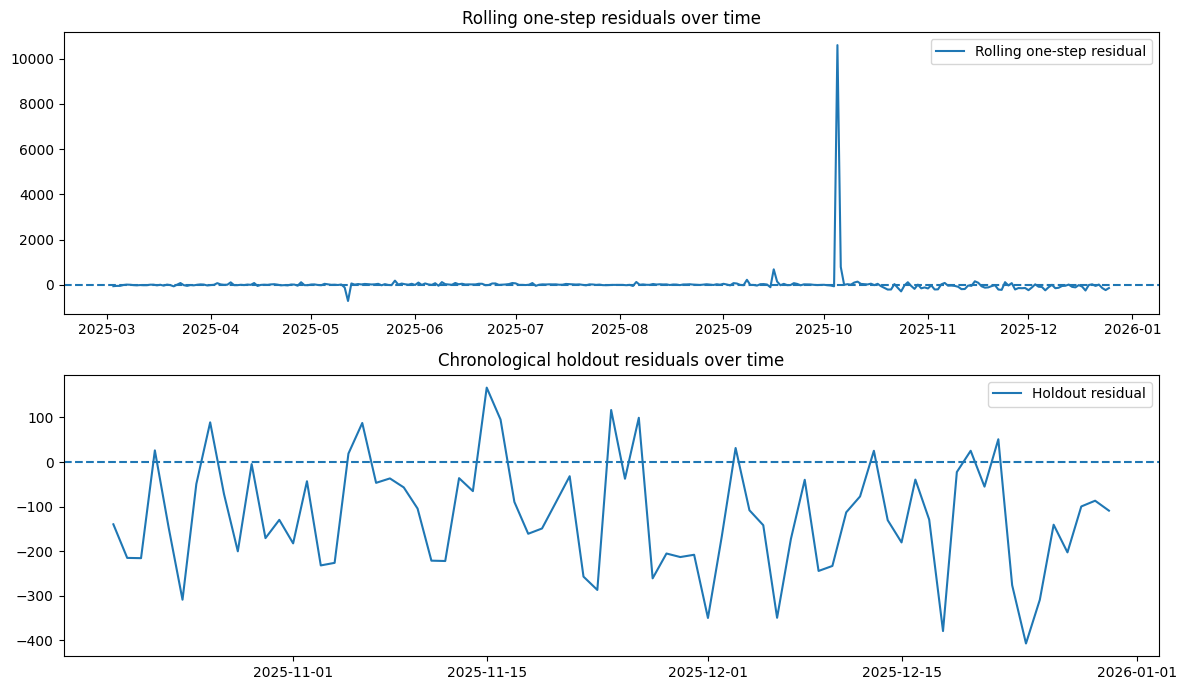

Saved validation outputs in factor_model_validation_outputs.


In [17]:
# Comprehensive validation checks for PCA/factor-model residualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from statsmodels.api import OLS, add_constant
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import (
    acorr_ljungbox,
    het_arch,
    het_breuschpagan,
    het_white,
    linear_reset,
    normal_ad,
    linear_rainbow,
    )
from statsmodels.stats.outliers_influence import OLSInfluence
from statsmodels.stats.stattools import durbin_watson

if "factor_model_state" not in globals() or not isinstance(factor_model_state, dict):
    raise ValueError("factor_model_state not found. Run the factor-model construction cell first.")

state = factor_model_state
ts = pd.to_datetime(state["timestamps"]).reset_index(drop=True)
X_raw = state["X_raw"].copy().reset_index(drop=True)
Xz = state["Xz"].copy().reset_index(drop=True)
y = pd.Series(state["y"], name="BEL_returns").reset_index(drop=True)
Vt = np.asarray(state["Vt"], dtype=float)
explained = np.asarray(state["explained_variance_ratio"], dtype=float)
cum_explained = np.asarray(state["cumulative_explained_variance"], dtype=float)
active_factors = list(state["active_factors"])
selected_n = int(state["selected_n_components"])

scores_all = np.asarray(state["scores_all"], dtype=float)
if scores_all.ndim != 2:
    raise ValueError("scores_all has unexpected shape.")

# Backward-compatible loading reconstruction if state lacks explicit loadings key.
if "pca_loadings" in state:
    pca_loadings = state["pca_loadings"]
else:
    pca_loadings = pd.DataFrame(
        Vt[:selected_n, :].T,
        index=active_factors,
        columns=[f"PC{i + 1}" for i in range(selected_n)],
    )

# 1) PCA stability diagnostics
print("Raw-factor correlation matrix:")
display(X_raw.corr())

print("PCA loadings (selected components):")
display(pca_loadings)

scree_df = pd.DataFrame(
    {
        "component": np.arange(1, len(explained) + 1),
        "explained_variance_ratio": explained,
        "cumulative_explained_variance": cum_explained,
    }
)
print("Scree and cumulative explained variance:")
display(scree_df)
print(f"Selected number of components (95% variance threshold): {selected_n}")

# 2) Sensitivity to component count
k_max = min(scores_all.shape[1], max(1, selected_n + 2))
component_sensitivity = []
for k in range(1, k_max + 1):
    Xk = scores_all[:, :k]
    Xk_const = add_constant(Xk, has_constant="add")
    ols_k = OLS(y.to_numpy(dtype=float), Xk_const).fit()
    fitted_k = ols_k.fittedvalues
    resid_k = y.to_numpy(dtype=float) - fitted_k
    component_sensitivity.append(
        {
            "k": k,
            "r2": float(ols_k.rsquared),
            "rmse": float(np.sqrt(np.mean(resid_k**2))),
            "resid_std": float(np.std(resid_k, ddof=1)),
        }
    )
component_sensitivity = pd.DataFrame(component_sensitivity)
print("Component-count sensitivity:")
display(component_sensitivity)

X_sel = scores_all[:, :selected_n]
X_sel_const = add_constant(X_sel, has_constant="add")
ols_linear = OLS(y.to_numpy(dtype=float), X_sel_const).fit()
fitted_sel = ols_linear.fittedvalues
resid_sel = y.to_numpy(dtype=float) - fitted_sel

# 3) Linear specification diagnostics
print("Linear fit summary (selected PCA components):")
print(ols_linear.summary())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(fitted_sel, resid_sel, alpha=0.6)
axes[0].axhline(0.0, linestyle="--")
axes[0].set_title("Residuals vs Fitted")
axes[0].set_xlabel("Fitted")
axes[0].set_ylabel("Residual")

axes[1].scatter(fitted_sel, np.sqrt(np.abs(resid_sel)), alpha=0.6)
axes[1].set_title("Scale-Location")
axes[1].set_xlabel("Fitted")
axes[1].set_ylabel("sqrt(|Residual|)")
plt.tight_layout()
plt.show()

reset_res = linear_reset(ols_linear, power=2, use_f=True)
print(f"RESET F-stat p-value: {float(reset_res.pvalue):.4g}")

aug_df = pd.DataFrame(X_sel, columns=[f"PC{i+1}" for i in range(selected_n)])
aug_df["T_sq"] = aug_df["PC1"] ** 2 if "PC1" in aug_df.columns else 0.0
aug_df["load_sq"] = aug_df["PC2"] ** 2 if "PC2" in aug_df.columns else 0.0
if "BE Temp (C)" in X_raw.columns and "pct_BE_actual_load" in X_raw.columns:
    aug_df["T_x_load"] = X_raw["BE Temp (C)"].to_numpy() * X_raw["pct_BE_actual_load"].to_numpy()
else:
    aug_df["T_x_load"] = 0.0
aug_df = add_constant(aug_df, has_constant="add")
ols_aug = OLS(y.to_numpy(dtype=float), aug_df).fit()
print("Augmented nonlinear specification summary:")
print(ols_aug.summary())

# 4) Serial correlation diagnostics
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_acf(resid_sel, lags=min(30, len(resid_sel) // 2), ax=axes[0])
plot_pacf(resid_sel, lags=min(30, len(resid_sel) // 2), method="ywm", ax=axes[1])
axes[0].set_title("ACF of residuals")
axes[1].set_title("PACF of residuals")
plt.tight_layout()
plt.show()

lb_df = acorr_ljungbox(resid_sel, lags=[5, 10, 20], return_df=True)
dw_stat = durbin_watson(resid_sel)
print("Ljung-Box test:")
display(lb_df)
print(f"Durbin-Watson: {dw_stat:.4f}")

# 5) Heteroskedasticity diagnostics
exog_bp = add_constant(X_sel, has_constant="add")
bp_stat, bp_p, _, _ = het_breuschpagan(resid_sel, exog_bp)
white_stat, white_p, _, _ = het_white(resid_sel, exog_bp)
arch_stat, arch_p, _, _ = het_arch(resid_sel, nlags=5)

hetero_table = pd.DataFrame(
    {
        "test": ["Breusch-Pagan", "White", "ARCH LM (lag=5)"],
        "stat": [bp_stat, white_stat, arch_stat],
        "p_value": [bp_p, white_p, arch_p],
    }
)
print("Heteroskedasticity diagnostics:")
display(hetero_table)

# 6) Influence diagnostics
influence = OLSInfluence(ols_linear)
leverage = influence.hat_matrix_diag
cooks_d = influence.cooks_distance[0]
stud_resid = influence.resid_studentized_external

influence_df = pd.DataFrame(
    {
        "timestamp": ts,
        "leverage": leverage,
        "cooks_d": cooks_d,
        "studentized_resid": stud_resid,
        "abs_studentized_resid": np.abs(stud_resid),
    }
).sort_values(["cooks_d", "abs_studentized_resid"], ascending=False)

print("Top 10 influential observations:")
display(influence_df.head(10))

fig, ax = plt.subplots(figsize=(12, 4))
ax.stem(np.arange(len(cooks_d)), cooks_d, linefmt="C1-", markerfmt="C1o", basefmt="k-")
ax.set_title("Cook's Distance")
ax.set_xlabel("Observation index")
ax.set_ylabel("Cook's D")
plt.tight_layout()
plt.show()

# 7) Parameter stability and OOS residualization checks
y_np = y.to_numpy(dtype=float)
min_train = max(60, selected_n * 8)
rolling_end_idx = np.arange(min_train, len(y_np) - 5, dtype=int)
rolling_rows = []
for end_idx in rolling_end_idx.tolist():
    X_train = X_sel[:end_idx, :]
    y_train = y_np[:end_idx]
    X_test = X_sel[end_idx : end_idx + 1, :]
    y_test = y_np[end_idx : end_idx + 1]

    model = Ridge(alpha=1.0, fit_intercept=True)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)[0]
    rolling_rows.append(
        {
            "timestamp": ts.iloc[end_idx],
            "y_true": float(y_test[0]),
            "y_pred": float(pred),
            "residual": float(y_test[0] - pred),
        }
    )

rolling_stats = pd.DataFrame(rolling_rows)
if len(rolling_stats) >= 2:
    rmse_r = float(np.sqrt(mean_squared_error(rolling_stats["y_true"], rolling_stats["y_pred"])))
    mae_r = float(mean_absolute_error(rolling_stats["y_true"], rolling_stats["y_pred"]))
    r2_r = float(r2_score(rolling_stats["y_true"], rolling_stats["y_pred"]))
elif len(rolling_stats) == 1:
    rmse_r = float(np.sqrt(mean_squared_error(rolling_stats["y_true"], rolling_stats["y_pred"])))
    mae_r = float(mean_absolute_error(rolling_stats["y_true"], rolling_stats["y_pred"]))
    r2_r = np.nan
else:
    rmse_r = np.nan
    mae_r = np.nan
    r2_r = np.nan

split_idx = int(len(y_np) * 0.8)
X_train = X_sel[:split_idx, :]
X_test = X_sel[split_idx:, :]
y_train = y_np[:split_idx]
y_test = y_np[split_idx:]
ts_test = ts.iloc[split_idx:].reset_index(drop=True)

model_train = Ridge(alpha=1.0, fit_intercept=True)
model_train.fit(X_train, y_train)
y_pred = model_train.predict(X_test)

oos_comparison = pd.DataFrame(
    {
        "timestamp": ts_test,
        "y_true": y_test,
        "y_pred": y_pred,
        "residual": y_test - y_pred,
    }
)

if len(oos_comparison) >= 2:
    rmse_e = float(np.sqrt(mean_squared_error(oos_comparison["y_true"], oos_comparison["y_pred"])))
    mae_e = float(mean_absolute_error(oos_comparison["y_true"], oos_comparison["y_pred"]))
    r2_e = float(r2_score(oos_comparison["y_true"], oos_comparison["y_pred"]))
elif len(oos_comparison) == 1:
    rmse_e = float(np.sqrt(mean_squared_error(oos_comparison["y_true"], oos_comparison["y_pred"])))
    mae_e = float(mean_absolute_error(oos_comparison["y_true"], oos_comparison["y_pred"]))
    r2_e = np.nan
else:
    rmse_e = np.nan
    mae_e = np.nan
    r2_e = np.nan

stability_summary = pd.DataFrame(
    {
        "evaluation": ["Rolling one-step", "Chronological holdout"],
        "RMSE": [rmse_r, rmse_e],
        "MAE": [mae_r, mae_e],
        "R2": [r2_r, r2_e],
        "n_obs": [len(rolling_stats), len(oos_comparison)],
    }
)
print("Out-of-sample residualization performance:")
display(stability_summary)

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=False)
if not rolling_stats.empty:
    axes[0].plot(rolling_stats["timestamp"], rolling_stats["residual"], label="Rolling one-step residual")
    axes[0].axhline(0.0, linestyle="--")
    axes[0].set_title("Rolling one-step residuals over time")
    axes[0].legend(loc="upper right")
else:
    axes[0].text(0.5, 0.5, "Insufficient data for rolling window", ha="center", va="center")
    axes[0].set_title("Rolling one-step residuals over time")

if not oos_comparison.empty:
    axes[1].plot(oos_comparison["timestamp"], oos_comparison["residual"], label="Holdout residual")
    axes[1].axhline(0.0, linestyle="--")
    axes[1].set_title("Chronological holdout residuals over time")
    axes[1].legend(loc="upper right")
else:
    axes[1].text(0.5, 0.5, "Insufficient data for holdout", ha="center", va="center")
    axes[1].set_title("Chronological holdout residuals over time")
plt.tight_layout()
plt.show()

factor_model_validation_outputs = {
    "scree": scree_df,
    "component_sensitivity": component_sensitivity,
    "linear_model": ols_linear,
    "augmented_model": ols_aug,
    "ljung_box": lb_df,
    "heteroskedasticity": hetero_table,
    "influence": influence_df,
    "rolling_oos": rolling_stats,
    "holdout_oos": oos_comparison,
    "stability_summary": stability_summary,
}
print("Saved validation outputs in factor_model_validation_outputs.")

### Robust Factor-Model Handoff for Downstream Cells

This cell rebuilds the Belgium idiosyncratic series with outlier-resistant choices and then writes the result back to the canonical downstream columns.

Modeling choices used here:
- Return transform: use symmetric returns instead of plain percent returns to avoid denominator explosions near zero price levels.
- Missing-data consistency: if either current or lagged raw Belgium level is missing, the return is forced to missing (no hidden interpolation in reported returns).
- Estimation: fit a Huber robust regression on PCA factor scores so one or two extreme days do not dominate coefficients.
- Handoff contract: overwrite BEL_returns, BEL_fitted, and BEL_idiosyncratic in hourly_aligned so all later cells automatically consume the fixed series.

Practical note: legacy series are preserved with _legacy_pct suffix the first time this cell runs.

In [18]:
# Rebuild BEL series with robust return transform and robust regression, then hand off to downstream columns
import numpy as np
import pandas as pd
from sklearn.linear_model import HuberRegressor

if "hourly_aligned" not in globals() or not isinstance(hourly_aligned, pd.DataFrame):
    raise ValueError("hourly_aligned is required. Run alignment cells first.")

target_col = "Country Hourly - Belgium"
weather_factor_cols = ["BE Temp (C)", "BE Precipitation (mm)", "BE Wind Speed (km/h)"]
load_factor_cols = ["pct_BE_actual_load", "pct_BE_forecast_load", "pct_BE_forecast_vs_actual_load"]
factor_cols = weather_factor_cols + load_factor_cols

required_cols = ["timestamp", target_col] + factor_cols
missing_cols = [c for c in required_cols if c not in hourly_aligned.columns]
if missing_cols:
    raise ValueError(f"Missing required columns for robust factor model: {missing_cols}")

work = hourly_aligned[required_cols].copy().sort_values("timestamp").reset_index(drop=True)
raw_target_missing = work[target_col].isna()

# Interpolate only for model fitting internals; reported returns below still honor raw-level missingness.
work[[target_col] + factor_cols] = work[[target_col] + factor_cols].interpolate(method="linear", limit_area="inside")

p_t = work[target_col]
p_lag = p_t.shift(1)
raw_target_missing_lag = raw_target_missing.shift(1).fillna(True)

# Symmetric return stabilizes near-zero denominators compared with plain pct_change.
eps = 1e-9
denom = p_t.abs() + p_lag.abs() + eps
work["BEL_returns_fixed"] = 200.0 * (p_t - p_lag) / denom
work.loc[raw_target_missing | raw_target_missing_lag, "BEL_returns_fixed"] = np.nan

ret_df = work[["timestamp", "BEL_returns_fixed"] + factor_cols].dropna().copy()
if len(ret_df) < 10:
    raise ValueError(f"Not enough clean rows to fit robust factor model: {len(ret_df)}")

# Remove constant factors.
std = ret_df[factor_cols].std(axis=0, ddof=0)
active = std[std > 0].index.tolist()
if not active:
    raise ValueError("All factor columns are constant after cleaning.")

X_raw = ret_df[active].copy()
y = ret_df["BEL_returns_fixed"].copy()

X_mean = X_raw.mean(axis=0)
X_std = X_raw.std(axis=0, ddof=0).replace(0.0, np.nan)
Xz = ((X_raw - X_mean) / X_std).dropna().copy()
y = y.loc[Xz.index]
ts = ret_df.loc[Xz.index, "timestamp"].copy()

Xz_np = Xz.to_numpy(dtype=float)
U, S, Vt = np.linalg.svd(Xz_np, full_matrices=False)
explained = (S ** 2) / np.sum(S ** 2)
cum_explained = np.cumsum(explained)
n_components = max(1, int(np.searchsorted(cum_explained, 0.95) + 1))
scores_all = Xz_np @ Vt.T
X_pca = scores_all[:, :n_components]

loadings = pd.DataFrame(
    Vt[:n_components, :].T,
    index=active,
    columns=[f"PC{i + 1}" for i in range(n_components)],
)

huber = HuberRegressor(epsilon=1.35, alpha=1e-4, max_iter=2000)
huber.fit(X_pca, y.to_numpy(dtype=float))
fitted = huber.predict(X_pca)
resid = y.to_numpy(dtype=float) - fitted

model_out = pd.DataFrame(
    {
        "timestamp": ts.to_numpy(),
        "BEL_returns": y.to_numpy(dtype=float),
        "BEL_fitted": fitted,
        "BEL_idiosyncratic": resid,
    }
)

# Preserve prior canonical series once, then overwrite canonical columns for downstream compatibility.
canonical_cols = ["BEL_returns", "BEL_fitted", "BEL_idiosyncratic"]
for c in canonical_cols:
    legacy_col = f"{c}_legacy_pct"
    if c in hourly_aligned.columns and legacy_col not in hourly_aligned.columns:
        hourly_aligned[legacy_col] = hourly_aligned[c]

hourly_aligned = hourly_aligned.drop(columns=[c for c in canonical_cols if c in hourly_aligned.columns], errors="ignore")
hourly_aligned = hourly_aligned.merge(model_out, on="timestamp", how="left")

# Save fixed-state bundle and rebind factor_model_state so later diagnostics use fixed configuration by default.
factor_model_state_fixed = {
    "target_col": target_col,
    "factor_cols": factor_cols,
    "active_factors": active,
    "timestamps": ts.reset_index(drop=True),
    "X_raw": X_raw.loc[Xz.index].reset_index(drop=True),
    "Xz": Xz.reset_index(drop=True),
    "y": y.reset_index(drop=True),
    "X_mean": X_mean,
    "X_std": X_std,
    "Vt": Vt,
    "singular_values": S,
    "explained_variance_ratio": explained,
    "cumulative_explained_variance": cum_explained,
    "selected_n_components": int(n_components),
    "scores_all": scores_all,
    "pca_loadings": loadings,
    "baseline_fitted": fitted,
    "baseline_residuals": resid,
    "return_transform": "symmetric_200",
    "estimator": "HuberRegressor",
    "estimator_params": {"epsilon": 1.35, "alpha": 1e-4, "max_iter": 2000},
}
factor_model_state = factor_model_state_fixed

print("Robust BEL handoff completed.")
print("Rows in robust model_out:", len(model_out))
print("Selected components:", int(n_components))
print("Active factors:", active)
print("Current BEL columns now map to robust series for downstream cells.")
display(hourly_aligned[["timestamp", "BEL_returns", "BEL_fitted", "BEL_idiosyncratic"]].tail())

Robust BEL handoff completed.
Rows in robust model_out: 359
Selected components: 5
Active factors: ['BE Temp (C)', 'BE Precipitation (mm)', 'BE Wind Speed (km/h)', 'pct_BE_actual_load', 'pct_BE_forecast_load', 'pct_BE_forecast_vs_actual_load']
Current BEL columns now map to robust series for downstream cells.


,timestamp,BEL_returns,BEL_fitted,BEL_idiosyncratic
360,2025-12-27 00:00:00+00:00,-7.011172,-16.734008,9.722835
361,2025-12-28 00:00:00+00:00,2.902946,-8.190353,11.093299
362,2025-12-29 00:00:00+00:00,4.149707,14.258096,-10.108389
363,2025-12-30 00:00:00+00:00,-8.065927,1.116354,-9.182281
364,2025-12-31 00:00:00+00:00,NaN,NaN,NaN


### Best Main-Text Figures (Saved to Images/)

This section exports the two core figures for the thesis write-up:
1. Scree plot with cumulative explained variance.
2. Final robust factor-model residual diagnostics panel (2x2).

Both figures are saved to the Images folder with fixed, publication-friendly filenames.

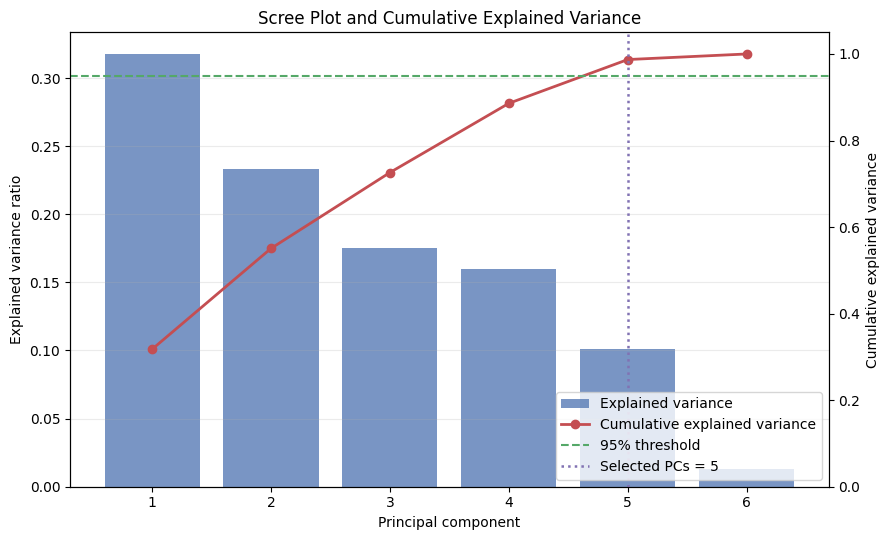

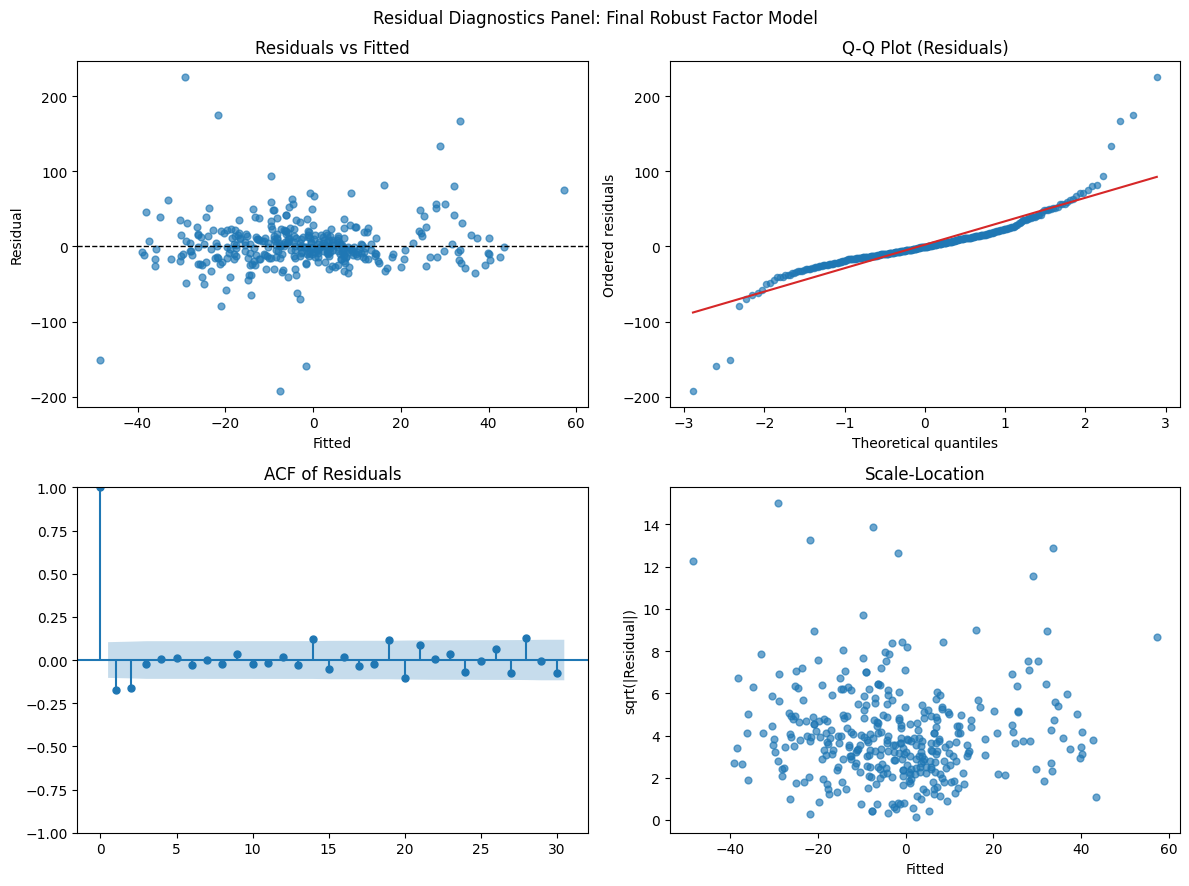

Saved best main-text figures:
- Images/01_scree_cumulative_explained_variance.png
- Images/02_residual_diagnostics_panel_robust_factor_model.png


In [19]:
# Export best main-text figures from the final robust factor model
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.graphics.tsaplots import plot_acf

if "factor_model_state" not in globals() or not isinstance(factor_model_state, dict):
    raise ValueError("factor_model_state not found. Run the robust factor-model handoff cell first.")

state = factor_model_state
explained = np.asarray(state["explained_variance_ratio"], dtype=float)
cum_explained = np.asarray(state["cumulative_explained_variance"], dtype=float)
selected_n = int(state["selected_n_components"])
fitted = np.asarray(state["baseline_fitted"], dtype=float)
resid = np.asarray(state["baseline_residuals"], dtype=float)

if explained.size == 0 or cum_explained.size == 0:
    raise ValueError("Missing explained-variance arrays in factor_model_state.")
if fitted.size == 0 or resid.size == 0:
    raise ValueError("Missing fitted/residual arrays in factor_model_state.")

out_dir = "Images"
os.makedirs(out_dir, exist_ok=True)

# 1) Scree plot with cumulative explained variance
components = np.arange(1, explained.size + 1)
fig, ax1 = plt.subplots(figsize=(9, 5.5))
ax1.bar(components, explained, alpha=0.75, color="#4C72B0", label="Explained variance")
ax1.set_xlabel("Principal component")
ax1.set_ylabel("Explained variance ratio")
ax1.set_xticks(components)
ax1.grid(axis="y", alpha=0.25)

ax2 = ax1.twinx()
ax2.plot(components, cum_explained, color="#C44E52", marker="o", linewidth=2.0, label="Cumulative explained variance")
ax2.axhline(0.95, color="#55A868", linestyle="--", linewidth=1.5, label="95% threshold")
ax2.axvline(selected_n, color="#8172B3", linestyle=":", linewidth=1.8, label=f"Selected PCs = {selected_n}")
ax2.set_ylabel("Cumulative explained variance")
ax2.set_ylim(0, 1.05)

handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(handles1 + handles2, labels1 + labels2, loc="lower right")
plt.title("Scree Plot and Cumulative Explained Variance")
plt.tight_layout()
scree_path = os.path.join(out_dir, "01_scree_cumulative_explained_variance.png")
plt.savefig(scree_path, dpi=300, bbox_inches="tight")
plt.show()

# 2) Residual diagnostics panel (2x2)
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# Residuals vs fitted
axes[0, 0].scatter(fitted, resid, alpha=0.65, s=24)
axes[0, 0].axhline(0.0, color="black", linestyle="--", linewidth=1)
axes[0, 0].set_title("Residuals vs Fitted")
axes[0, 0].set_xlabel("Fitted")
axes[0, 0].set_ylabel("Residual")

# Q-Q plot
(qq_theoretical, qq_ordered), (qq_slope, qq_intercept, qq_r) = stats.probplot(resid, dist="norm")
axes[0, 1].scatter(qq_theoretical, qq_ordered, alpha=0.65, s=20)
xline = np.array([qq_theoretical.min(), qq_theoretical.max()])
axes[0, 1].plot(xline, qq_intercept + qq_slope * xline, color="C3", linewidth=1.5)
axes[0, 1].set_title("Q-Q Plot (Residuals)")
axes[0, 1].set_xlabel("Theoretical quantiles")
axes[0, 1].set_ylabel("Ordered residuals")

# ACF of residuals
plot_acf(resid, lags=min(30, max(5, len(resid) // 3)), ax=axes[1, 0])
axes[1, 0].set_title("ACF of Residuals")

# Scale-location
sqrt_abs_resid = np.sqrt(np.abs(resid))
axes[1, 1].scatter(fitted, sqrt_abs_resid, alpha=0.65, s=24)
axes[1, 1].set_title("Scale-Location")
axes[1, 1].set_xlabel("Fitted")
axes[1, 1].set_ylabel("sqrt(|Residual|)")

fig.suptitle("Residual Diagnostics Panel: Final Robust Factor Model", y=0.98)
plt.tight_layout()
diag_path = os.path.join(out_dir, "02_residual_diagnostics_panel_robust_factor_model.png")
plt.savefig(diag_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved best main-text figures:")
print("-", scree_path)
print("-", diag_path)

Series: PM_nuclear_returns
Observations: 364


,mean,std,min,max,skew,kurtosis
PM_nuclear_returns,-0.131937,16.755938,-60.0,100.0,1.335911,7.248701


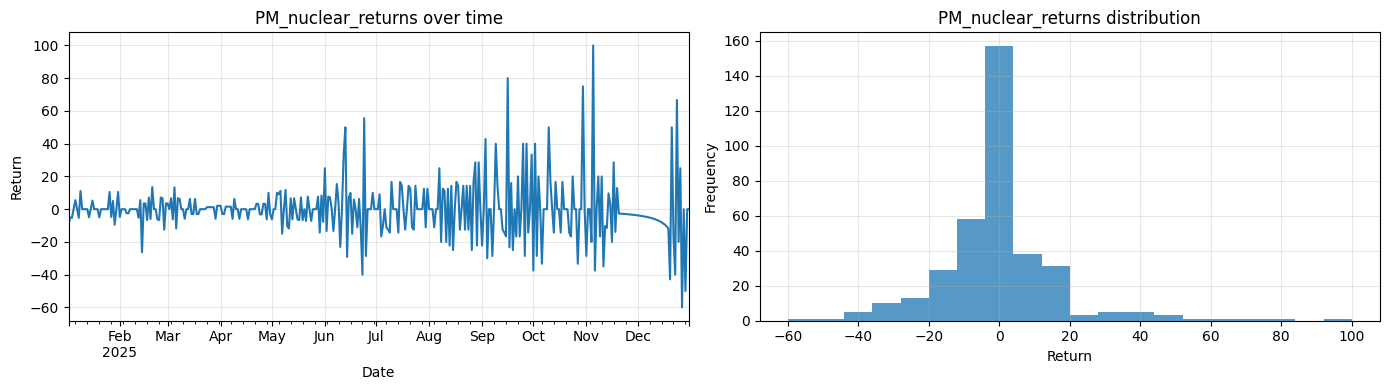

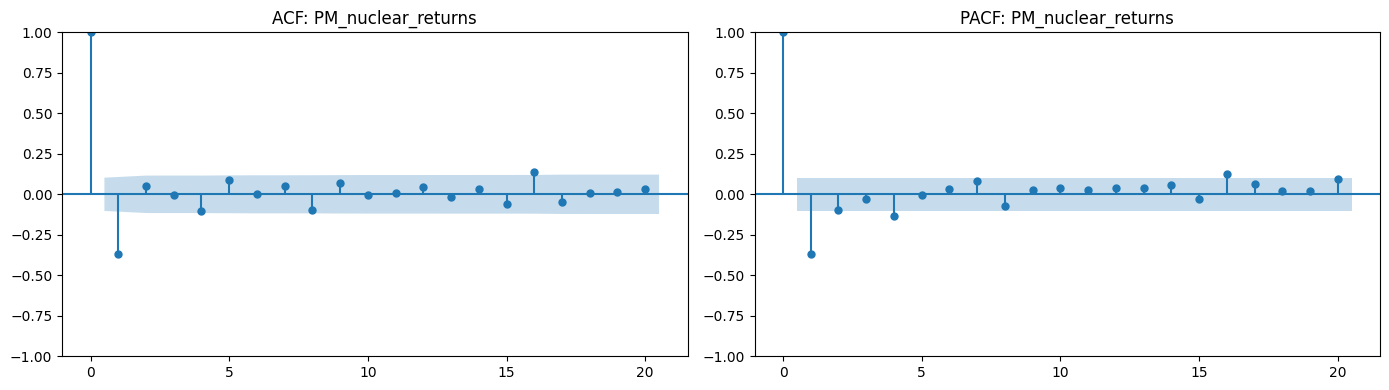

ADF statistic: -12.1695 | p-value: 0.0000
ADF conclusion (5%): Stationary
KPSS statistic: 0.2604 | p-value: 0.1000
KPSS conclusion (5%): Stationary

Series: BEL_idiosyncratic
Observations: 359


/var/folders/h9/cypcrhp14dn4gqqq118p8dyh0000gn/T/ipykernel_65829/2529918737.py:84: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(sr, regression="c", nlags="auto")


,mean,std,min,max,skew,kurtosis
BEL_idiosyncratic,2.256744,34.504008,-192.543773,225.458652,0.697868,12.32233


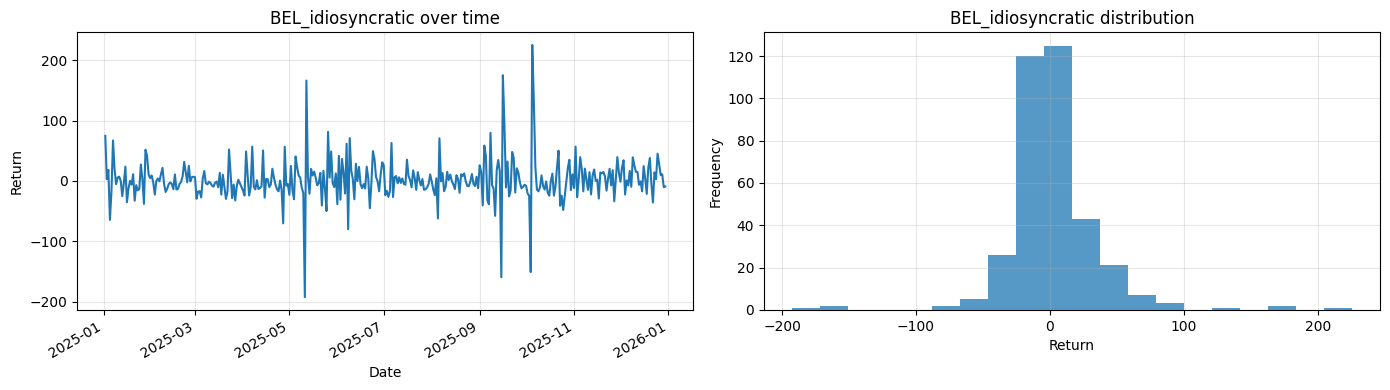

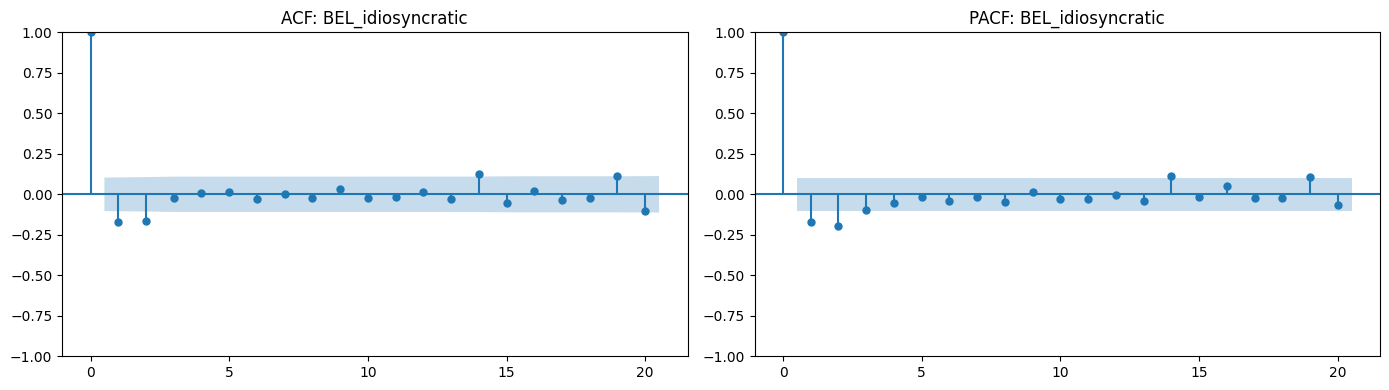

ADF statistic: -14.2283 | p-value: 0.0000
ADF conclusion (5%): Stationary
KPSS statistic: 0.4964 | p-value: 0.0425
KPSS conclusion (5%): Non-stationary



In [20]:
# ====================================================
# Time-series EDA: nuclear PM returns and Belgian idiosyncratic returns
# Includes autocorrelation and stationarity checks
# ====================================================
import matplotlib.pyplot as plt

try:
    from statsmodels.tsa.stattools import adfuller, kpss
    from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
    statsmodels_available = True
except Exception as exc:
    statsmodels_available = False
    print("statsmodels is required for ACF/PACF and ADF/KPSS tests.")
    print("Install with: pip install statsmodels")
    print("Import error:", exc)

required_pm_cols = ["price_Yes_nuclear"]
missing = [c for c in required_pm_cols if c not in hourly_aligned.columns]
if missing:
    raise ValueError(f"Missing PM level columns in hourly_aligned: {missing}")
if "BEL_idiosyncratic" not in hourly_aligned.columns:
    raise ValueError("BEL_idiosyncratic not found. Run the Belgian factor model cell first.")

pm_returns = hourly_aligned.copy().sort_values("timestamp")
pm_returns["PM_nuclear_returns"] = pm_returns["price_Yes_nuclear"].pct_change() * 100

series_map = {
    "PM_nuclear_returns": pm_returns.set_index("timestamp")["PM_nuclear_returns"],
    "BEL_idiosyncratic": hourly_aligned.set_index("timestamp")["BEL_idiosyncratic"],
}

for name, sr in series_map.items():
    sr = sr.dropna().copy()
    if sr.empty:
        print(f"Skipping {name}: no non-NaN observations.")
        continue

    print("=" * 70)
    print(f"Series: {name}")
    print(f"Observations: {len(sr)}")

    desc = pd.DataFrame(
        {
            "mean": [sr.mean()],
            "std": [sr.std()],
            "min": [sr.min()],
            "max": [sr.max()],
            "skew": [sr.skew()],
            "kurtosis": [sr.kurt()],
        },
        index=[name],
    )
    display(desc)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    sr.plot(ax=axes[0], title=f"{name} over time")
    axes[0].set_xlabel("Date")
    axes[0].set_ylabel("Return")
    axes[0].grid(alpha=0.3)

    axes[1].hist(sr, bins=20, alpha=0.75)
    axes[1].set_title(f"{name} distribution")
    axes[1].set_xlabel("Return")
    axes[1].set_ylabel("Frequency")
    axes[1].grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    if statsmodels_available and len(sr) >= 8:
        max_lags = min(20, max(1, len(sr) // 2 - 1))
        fig, axes = plt.subplots(1, 2, figsize=(14, 4))
        plot_acf(sr, lags=max_lags, ax=axes[0])
        axes[0].set_title(f"ACF: {name}")
        plot_pacf(sr, lags=max_lags, ax=axes[1], method="ywm")
        axes[1].set_title(f"PACF: {name}")
        plt.tight_layout()
        plt.show()

        adf_stat, adf_p, *_ = adfuller(sr, autolag="AIC")
        print(f"ADF statistic: {adf_stat:.4f} | p-value: {adf_p:.4f}")
        print("ADF conclusion (5%):", "Stationary" if adf_p < 0.05 else "Non-stationary")

        try:
            kpss_stat, kpss_p, *_ = kpss(sr, regression="c", nlags="auto")
            print(f"KPSS statistic: {kpss_stat:.4f} | p-value: {kpss_p:.4f}")
            print("KPSS conclusion (5%):", "Stationary" if kpss_p >= 0.05 else "Non-stationary")
        except Exception as kpss_exc:
            print("KPSS test failed:", kpss_exc)

        print()
    elif not statsmodels_available:
        print("Skipping ACF/PACF and ADF/KPSS because statsmodels is unavailable.")
    else:
        print("Skipping ACF/PACF and ADF/KPSS due to too few observations.")

## 5) Daily Predictive Modeling
Fit daily models linking prediction-market return series to Belgium idiosyncratic electricity returns.

In [11]:
# ====================================================
# Modeling stage: VAR, SVAR, and ML benchmark
# Target: PM_nuclear_returns + time_to_expiry -> BEL_idiosyncratic
# ====================================================

import warnings
import numpy as np
import pandas as pd
from statsmodels.tsa.api import VAR
from statsmodels.tsa.vector_ar.svar_model import SVAR
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import ParameterGrid
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor

required_cols = ["timestamp", "price_Yes_nuclear", "BEL_idiosyncratic"]
missing = [c for c in required_cols if c not in hourly_aligned.columns]
if missing:
    raise ValueError(f"Missing required columns in hourly_aligned: {missing}")

ts_raw = hourly_aligned[required_cols].copy()
ts_raw["timestamp"] = pd.to_datetime(ts_raw["timestamp"], utc=True, errors="coerce")
ts_raw = ts_raw.dropna(subset=["timestamp"]).sort_values("timestamp")
ts_raw = ts_raw[ts_raw["timestamp"].dt.year == 2025].copy()
if ts_raw.empty:
    raise ValueError("No 2025 observations found in hourly_aligned for fitting.")

ts_raw["date"] = ts_raw["timestamp"].dt.floor("D")
ts_daily = (
    ts_raw.groupby("date", as_index=False)
    .agg({
        "price_Yes_nuclear": "last",
        "BEL_idiosyncratic": "mean",
    })
    .rename(columns={"date": "timestamp"})
)

# Add time-to-expiry variable (days until market resolution on 2026-01-01)
resolution_date = pd.Timestamp("2026-01-01", tz="UTC")
ts_daily["time_to_expiry"] = (resolution_date - ts_daily["timestamp"]).dt.days

ts_df = ts_daily.copy()
ts_df["PM_nuclear_returns"] = ts_df["price_Yes_nuclear"].pct_change() * 100

x_cols = ["PM_nuclear_returns", "time_to_expiry"]
y_col = "BEL_idiosyncratic"
model_cols = x_cols + [y_col]
ts_df = ts_df[["timestamp"] + model_cols].dropna().reset_index(drop=True)

if len(ts_df) < 60:
    raise ValueError(f"Not enough observations for robust model comparison: {len(ts_df)}")

ts_model = ts_df[model_cols].copy()
split_idx = len(ts_model) - 10
if split_idx < 30:
    raise ValueError(f"Training sample too small after 10-step holdout: train={split_idx}")
train_df = ts_model.iloc[:split_idx].copy()
val_df = ts_model.iloc[split_idx:].copy()

span_start = ts_df["timestamp"].min()
span_end = ts_df["timestamp"].max()
print(f"Target relationship: {x_cols} -> {y_col}")
print(f"Fitting frequency: daily | year filter: 2025 | span: {span_start.date()} to {span_end.date()}")
print(f"Total obs: {len(ts_model)} | Train: {len(train_df)} | Validation: {len(val_df)}")
print(f"Resolution date: {resolution_date.date()} | Time-to-expiry range: {ts_df['time_to_expiry'].min()} to {ts_df['time_to_expiry'].max()} days")
display(ts_df.head())
ts_df = ts_model.copy()

def one_step_from_params(history_window, coefs, intercept):
    yhat = np.array(intercept, dtype=float).copy()
    k_ar = coefs.shape[0]
    for lag in range(1, k_ar + 1):
        yhat += coefs[lag - 1] @ history_window[-lag]
    return yhat

def rolling_forecast_multivariate_from_params(coefs, intercept, train_data, val_data):
    k_ar = coefs.shape[0]
    history = train_data.to_numpy().tolist()
    preds = []
    for i in range(len(val_data)):
        history_window = np.array(history[-k_ar:])
        yhat = one_step_from_params(history_window, coefs, intercept)
        preds.append(yhat)
        history.append(val_data.iloc[i].to_numpy())
    pred_df = pd.DataFrame(preds, index=val_data.index, columns=train_data.columns)
    return pred_df

def rmse(actual, pred):
    return np.sqrt(mean_squared_error(actual, pred))

var_candidates = []
max_lag = min(10, max(2, len(train_df) // 10))
for p in range(1, max_lag + 1):
    try:
        var_fit = VAR(train_df).fit(p)
        var_pred = rolling_forecast_multivariate_from_params(var_fit.coefs, var_fit.intercept, train_df, val_df)
        score = rmse(val_df[y_col], var_pred[y_col])
        var_candidates.append({"model": "VAR", "lag": p, "val_rmse": score, "fit": var_fit})
    except Exception as exc:
        print(f"VAR lag {p} failed: {exc}")
if not var_candidates:
    raise RuntimeError("All VAR candidates failed.")
best_var = min(var_candidates, key=lambda x: x["val_rmse"])
print(f"\nBest VAR lag: {best_var['lag']} | Validation RMSE: {best_var['val_rmse']:.6f}")

svar_candidates = []
A_template = np.array(
    [
        [1, 0, 0],
        ["E", 1, 0],
        ["E", "E", 1],
    ],
    dtype=object,
)
for p in range(1, max_lag + 1):
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=FutureWarning)
            svar_mod = SVAR(train_df, svar_type="A", A=A_template)
            svar_fit = svar_mod.fit(maxlags=p, ic=None, trend="c", solver="nm", maxiter=3000, maxfun=6000)
        p_eff = int(svar_fit.k_ar)
        if p_eff < 1:
            continue
        svar_pred = rolling_forecast_multivariate_from_params(svar_fit.coefs, svar_fit.intercept, train_df, val_df)
        score = rmse(val_df[y_col], svar_pred[y_col])
        svar_candidates.append({"model": "SVAR", "lag": p_eff, "val_rmse": score, "fit": svar_fit})
    except Exception as exc:
        print(f"SVAR lag {p} failed: {exc}")

if svar_candidates:
    best_svar = min(svar_candidates, key=lambda x: x["val_rmse"])
    print(f"Best SVAR lag: {best_svar['lag']} | Validation RMSE: {best_svar['val_rmse']:.6f}")
else:
    best_svar = None
    print("SVAR candidates failed; check sample size or identification assumptions.")

# Summary of model comparison
print(f"\n{'='*70}")
print("MODEL COMPARISON WITH TIME-TO-EXPIRY VARIABLE")
print(f"{'='*70}")
print(f"Predictors: {x_cols}")
print(f"Target: {y_col}")
print(f"Observations: {len(ts_model)} | Train: {len(train_df)} | Validation: {len(val_df)}")
print(f"Time-to-expiry descriptive stats:")
print(ts_df["time_to_expiry"].describe())

Target relationship: ['PM_nuclear_returns', 'time_to_expiry'] -> BEL_idiosyncratic
Fitting frequency: daily | year filter: 2025 | span: 2025-01-02 to 2025-12-30
Total obs: 363 | Train: 353 | Validation: 10
Resolution date: 2026-01-01 | Time-to-expiry range: 2 to 364 days


,timestamp,PM_nuclear_returns,time_to_expiry,BEL_idiosyncratic
0,2025-01-02 00:00:00+00:00,-9.090909,364,435.813306
1,2025-01-03 00:00:00+00:00,-5.000000,363,-76.531023
2,2025-01-04 00:00:00+00:00,-5.263158,362,-34.339273
3,2025-01-05 00:00:00+00:00,0.000000,361,25.123767
4,2025-01-06 00:00:00+00:00,5.555556,360,-242.501661



Best VAR lag: 1 | Validation RMSE: 162.382974
SVAR lag 1 failed: Rank condition not met: solution may not be unique.
SVAR lag 2 failed: Rank condition not met: solution may not be unique.
SVAR lag 3 failed: Rank condition not met: solution may not be unique.
SVAR lag 4 failed: Rank condition not met: solution may not be unique.
SVAR lag 5 failed: Rank condition not met: solution may not be unique.
SVAR lag 8 failed: Rank condition not met: solution may not be unique.
SVAR lag 9 failed: Rank condition not met: solution may not be unique.
SVAR lag 10 failed: Rank condition not met: solution may not be unique.
Best SVAR lag: 6 | Validation RMSE: 350.789122

MODEL COMPARISON WITH TIME-TO-EXPIRY VARIABLE
Predictors: ['PM_nuclear_returns', 'time_to_expiry']
Target: BEL_idiosyncratic
Observations: 363 | Train: 353 | Validation: 10
Time-to-expiry descriptive stats:
count    363.000000
mean     183.000000
std      104.933312
min        2.000000
25%       92.500000
50%      183.000000
75%      

/Users/seamusconlon/Desktop/KUL/Thesis/.venv/lib/python3.13/site-packages/statsmodels/base/model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
/Users/seamusconlon/Desktop/KUL/Thesis/.venv/lib/python3.13/site-packages/statsmodels/base/model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '


## 6) Single-Market Attribution
Compare nuclear-only PM driver models for fit and shock sensitivity versus idiosyncratic electricity returns.

Best model for nuclear PM-driver:


,market,driver,family,model,rmse,mae,spec
0,Nuclear,PM_nuclear_returns,ML,GradientBoosting,64.845663,51.69348,"{'n_lags': 1, 'params': {'learning_rate': 0.1,..."


Sensitivity diagnostics for the best model:


,market,driver,best_model,best_family,rmse,mae,local_dy_dx_lag1,delta_y_if_xlag1_plus5pp,delta_y_if_xlag1_minus5pp
0,Nuclear,PM_nuclear_returns,GradientBoosting,ML,64.845663,51.69348,-16.597552,12.944227,-35.015354


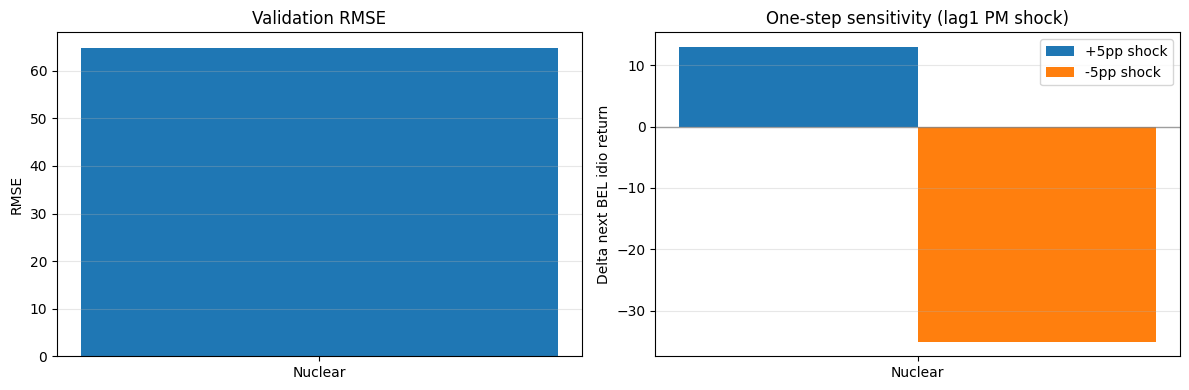

In [12]:
# ====================================================
# Nuclear PM-driver model diagnostics
# Best-fit performance and one-step PM shock sensitivity
# ====================================================

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.api import VAR
from statsmodels.tsa.vector_ar.svar_model import SVAR
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import ParameterGrid

if "hourly_aligned" not in globals() or not isinstance(hourly_aligned, pd.DataFrame):
    raise ValueError("hourly_aligned is required. Run alignment/factor cells first.")

required_cols = ["timestamp", "price_Yes_nuclear", "BEL_idiosyncratic"]
missing = [c for c in required_cols if c not in hourly_aligned.columns]
if missing:
    raise ValueError(f"Missing required columns in hourly_aligned: {missing}")

ts_raw = hourly_aligned[required_cols].copy()
ts_raw["timestamp"] = pd.to_datetime(ts_raw["timestamp"], utc=True, errors="coerce")
ts_raw = ts_raw.dropna(subset=["timestamp"]).sort_values("timestamp")
ts_raw = ts_raw[ts_raw["timestamp"].dt.year == 2025].copy()
if ts_raw.empty:
    raise ValueError("No 2025 observations found for nuclear PM-driver diagnostics.")

ts_raw["date"] = ts_raw["timestamp"].dt.floor("D")
ts_daily = (
    ts_raw.groupby("date", as_index=False)
    .agg(
        {
            "price_Yes_nuclear": "last",
            "BEL_idiosyncratic": "mean",
        }
    )
    .rename(columns={"date": "timestamp"})
)
ts_daily["PM_nuclear_returns"] = ts_daily["price_Yes_nuclear"].pct_change() * 100

def _rmse(a, p):
    a = np.asarray(a, dtype=float)
    p = np.asarray(p, dtype=float)
    return float(np.sqrt(np.mean((a - p) ** 2)))

def _mae(a, p):
    a = np.asarray(a, dtype=float)
    p = np.asarray(p, dtype=float)
    return float(np.mean(np.abs(a - p)))

def _rolling_from_params(coefs, intercept, train_df, val_df):
    k_ar = int(coefs.shape[0])
    hist = train_df.to_numpy(dtype=float).tolist()
    preds = []
    for i in range(len(val_df)):
        yhat = np.array(intercept, dtype=float).copy()
        for lag in range(1, k_ar + 1):
            yhat += coefs[lag - 1] @ np.array(hist[-lag], dtype=float)
        preds.append(yhat)
        hist.append(val_df.iloc[i].to_numpy(dtype=float))
    return pd.DataFrame(preds, columns=train_df.columns, index=val_df.index)

def _build_lagged_xy(df, x_col, y_col, n_lags):
    out = pd.DataFrame(index=df.index)
    for lag in range(1, n_lags + 1):
        out[f"{x_col}_lag{lag}"] = df[x_col].shift(lag)
        out[f"{y_col}_lag{lag}"] = df[y_col].shift(lag)
    out[y_col] = df[y_col]
    out = out.dropna()
    X = out.drop(columns=[y_col])
    y = out[y_col]
    return X, y

def _make_ml_est(model_name, params):
    if model_name == "Ridge":
        return Pipeline([("scaler", StandardScaler()), ("model", Ridge(alpha=params["alpha"]))])
    if model_name == "SVR":
        return Pipeline(
            [
                ("scaler", StandardScaler()),
                ("model", SVR(C=params["C"], epsilon=params["epsilon"], gamma=params["gamma"], kernel=params["kernel"])),
            ]
        )
    if model_name == "RandomForest":
        return RandomForestRegressor(
            n_estimators=params["n_estimators"],
            max_depth=params["max_depth"],
            min_samples_leaf=params["min_samples_leaf"],
            random_state=42,
            n_jobs=-1,
        )
    if model_name == "GradientBoosting":
        return GradientBoostingRegressor(
            n_estimators=params["n_estimators"],
            learning_rate=params["learning_rate"],
            max_depth=params["max_depth"],
            random_state=42,
        )
    raise ValueError(f"Unsupported ML model: {model_name}")

x_col = "PM_nuclear_returns"
market_label = "Nuclear"
ts_mkt = ts_daily[["timestamp", x_col, "BEL_idiosyncratic"]].dropna().reset_index(drop=True)
if len(ts_mkt) < 80:
    raise ValueError(f"Not enough rows for {market_label} model diagnostics: {len(ts_mkt)}")

split_idx = len(ts_mkt) - 10
train = ts_mkt.iloc[:split_idx][[x_col, "BEL_idiosyncratic"]].copy()
val = ts_mkt.iloc[split_idx:][[x_col, "BEL_idiosyncratic"]].copy()

candidates = []
max_lag = min(8, max(2, len(train) // 10))
for p in range(1, max_lag + 1):
    try:
        fit_var = VAR(train).fit(p)
        pred_var = _rolling_from_params(fit_var.coefs, fit_var.intercept, train, val)
        y_true = val["BEL_idiosyncratic"].to_numpy(dtype=float)
        y_pred = pred_var["BEL_idiosyncratic"].to_numpy(dtype=float)
        candidates.append(
            {
                "market": market_label,
                "driver": x_col,
                "family": "Traditional",
                "model": "VAR",
                "spec": {"lag": int(fit_var.k_ar)},
                "rmse": _rmse(y_true, y_pred),
                "mae": _mae(y_true, y_pred),
            }
        )
    except Exception:
        pass

    try:
        A_template = np.array([[1, 0], ["E", 1]], dtype=object)
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=FutureWarning)
            mod = SVAR(train, svar_type="A", A=A_template)
            fit_svar = mod.fit(maxlags=p, ic=None, trend="c", solver="nm", maxiter=2000, maxfun=4000)
        if int(fit_svar.k_ar) >= 1:
            pred_svar = _rolling_from_params(fit_svar.coefs, fit_svar.intercept, train, val)
            y_true = val["BEL_idiosyncratic"].to_numpy(dtype=float)
            y_pred = pred_svar["BEL_idiosyncratic"].to_numpy(dtype=float)
            candidates.append(
                {
                    "market": market_label,
                    "driver": x_col,
                    "family": "Traditional",
                    "model": "SVAR",
                    "spec": {"lag": int(fit_svar.k_ar)},
                    "rmse": _rmse(y_true, y_pred),
                    "mae": _mae(y_true, y_pred),
                }
            )
    except Exception:
        pass

ml_space = {
    "Ridge": {"alpha": [0.1, 1.0, 10.0]},
    "SVR": {"C": [1.0, 5.0], "epsilon": [0.1, 0.2], "gamma": ["scale"], "kernel": ["linear", "rbf"]},
    "RandomForest": {"n_estimators": [200], "max_depth": [3, 5, None], "min_samples_leaf": [1, 2]},
    "GradientBoosting": {"n_estimators": [150, 300], "learning_rate": [0.03, 0.1], "max_depth": [2, 3]},
}
for n_lags in [1, 2, 3, 5]:
    X_all, y_all = _build_lagged_xy(ts_mkt[[x_col, "BEL_idiosyncratic"]], x_col, "BEL_idiosyncratic", n_lags)
    if len(X_all) < 40:
        continue
    split_ml = len(X_all) - 10
    if split_ml < 30:
        continue

    X_train, X_val = X_all.iloc[:split_ml], X_all.iloc[split_ml:]
    y_train, y_val = y_all.iloc[:split_ml], y_all.iloc[split_ml:]

    for model_name, param_space in ml_space.items():
        for params in ParameterGrid(param_space):
            try:
                est = _make_ml_est(model_name, params)
                est.fit(X_train, y_train)
                pred = est.predict(X_val)
                candidates.append(
                    {
                        "market": market_label,
                        "driver": x_col,
                        "family": "ML",
                        "model": model_name,
                        "spec": {"n_lags": int(n_lags), "params": dict(params)},
                        "rmse": _rmse(y_val.to_numpy(dtype=float), pred),
                        "mae": _mae(y_val.to_numpy(dtype=float), pred),
                    }
                )
            except Exception:
                pass

if not candidates:
    raise RuntimeError("All candidates failed for nuclear PM-driver diagnostics.")

cand_df = pd.DataFrame(candidates).sort_values(["rmse", "mae"]).reset_index(drop=True)
best = cand_df.iloc[0].to_dict()
model_artifacts_by_market = {market_label: {"best": best, "all": cand_df}}

x_hist = train[x_col].astype(float).tolist()
y_hist = train["BEL_idiosyncratic"].astype(float).tolist()

if best["family"] == "Traditional":
    lag = int(best["spec"].get("lag", 1))
    if best["model"] == "SVAR":
        A_template = np.array([[1, 0], ["E", 1]], dtype=object)
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=FutureWarning)
            fit_best = SVAR(train, svar_type="A", A=A_template).fit(maxlags=lag, ic=None, trend="c", solver="nm", maxiter=2000, maxfun=4000)
        coefs = np.array(fit_best.coefs, dtype=float)
        intercept = np.array(fit_best.intercept, dtype=float)
    else:
        fit_best = VAR(train).fit(lag)
        coefs = np.array(fit_best.coefs, dtype=float)
        intercept = np.array(fit_best.intercept, dtype=float)

    k_ar = int(coefs.shape[0])

    def _one_step_linear(xh, yh):
        y_next = float(intercept[1])
        for l in range(1, k_ar + 1):
            A = coefs[l - 1]
            y_next += float(A[1, 0]) * float(xh[-l])
            y_next += float(A[1, 1]) * float(yh[-l])
        return float(y_next)

    base = _one_step_linear(x_hist, y_hist)
    x_plus = list(x_hist)
    x_minus = list(x_hist)
    x_plus[-1] += 5.0
    x_minus[-1] -= 5.0
    plus_delta = _one_step_linear(x_plus, y_hist) - base
    minus_delta = _one_step_linear(x_minus, y_hist) - base
    local_dydx = float(coefs[0, 1, 0])

else:
    n_lags = int(best["spec"].get("n_lags", 2))
    params = dict(best["spec"].get("params", {}))
    X_all, y_all = _build_lagged_xy(ts_mkt[[x_col, "BEL_idiosyncratic"]], x_col, "BEL_idiosyncratic", n_lags)
    split_ml = len(X_all) - 10
    X_train = X_all.iloc[:split_ml].copy()
    y_train = y_all.iloc[:split_ml].copy()

    est = _make_ml_est(best["model"], params)
    est.fit(X_train, y_train)
    base_row = X_train.iloc[[-1]].copy()
    x_lag1_col = f"{x_col}_lag1"
    if x_lag1_col not in base_row.columns:
        raise RuntimeError(f"Missing expected feature column: {x_lag1_col}")

    base = float(est.predict(base_row)[0])

    row_p = base_row.copy()
    row_m = base_row.copy()
    row_p.loc[:, x_lag1_col] = float(row_p.iloc[0][x_lag1_col] + 1.0)
    row_m.loc[:, x_lag1_col] = float(row_m.iloc[0][x_lag1_col] - 1.0)
    local_dydx = float((est.predict(row_p)[0] - est.predict(row_m)[0]) / 2.0)

    row_p5 = base_row.copy()
    row_m5 = base_row.copy()
    row_p5.loc[:, x_lag1_col] = float(row_p5.iloc[0][x_lag1_col] + 5.0)
    row_m5.loc[:, x_lag1_col] = float(row_m5.iloc[0][x_lag1_col] - 5.0)
    plus_delta = float(est.predict(row_p5)[0] - base)
    minus_delta = float(est.predict(row_m5)[0] - base)

separate_pm_performance = pd.DataFrame([best])
separate_pm_sensitivity = pd.DataFrame(
    [
        {
            "market": market_label,
            "driver": x_col,
            "best_model": best["model"],
            "best_family": best["family"],
            "rmse": float(best["rmse"]),
            "mae": float(best["mae"]),
            "local_dy_dx_lag1": float(local_dydx),
            "delta_y_if_xlag1_plus5pp": float(plus_delta),
            "delta_y_if_xlag1_minus5pp": float(minus_delta),
        }
    ]
)

print("Best model for nuclear PM-driver:")
display(separate_pm_performance[["market", "driver", "family", "model", "rmse", "mae", "spec"]])

print("Sensitivity diagnostics for the best model:")
display(separate_pm_sensitivity)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(separate_pm_sensitivity["market"], separate_pm_sensitivity["rmse"], color=["tab:blue"])
axes[0].set_title("Validation RMSE")
axes[0].set_ylabel("RMSE")
axes[0].grid(axis="y", alpha=0.3)

bar_w = 0.35
x = np.arange(len(separate_pm_sensitivity))
axes[1].bar(x - bar_w / 2, separate_pm_sensitivity["delta_y_if_xlag1_plus5pp"], width=bar_w, label="+5pp shock")
axes[1].bar(x + bar_w / 2, separate_pm_sensitivity["delta_y_if_xlag1_minus5pp"], width=bar_w, label="-5pp shock")
axes[1].set_xticks(x)
axes[1].set_xticklabels(separate_pm_sensitivity["market"].tolist())
axes[1].set_title("One-step sensitivity (lag1 PM shock)")
axes[1].set_ylabel("Delta next BEL idio return")
axes[1].axhline(0.0, color="gray", lw=1.0, alpha=0.7)
axes[1].legend()
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [19]:
# ====================================================
# Expanding-window backtest across Traditional + ML + GARCH + Foundation
# Target: BEL_idiosyncratic
# Ridge/Lasso/ElasticNet/SVR now use standardized predictors
# ====================================================

import warnings
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.ensemble import ExtraTreesRegressor, GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import ElasticNet, Lasso, Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from statsmodels.tsa.api import VAR
from statsmodels.tsa.vector_ar.svar_model import SVAR

try:
    from arch import arch_model
    HAS_ARCH = True
except Exception:
    HAS_ARCH = False

if "ts_df" not in globals() or not isinstance(ts_df, pd.DataFrame):
    raise ValueError("ts_df is required. Run the modeling stage cell first.")

required_bt_cols = ["PM_nuclear_returns", "BEL_idiosyncratic", "time_to_expiry"]
missing_bt = [c for c in required_bt_cols if c not in ts_df.columns]
if missing_bt:
    raise ValueError(f"Backtest requires columns in ts_df: {missing_bt}")

bt_df = ts_df[required_bt_cols].dropna().copy().reset_index(drop=True)
if len(bt_df) < 80:
    raise ValueError(f"Need at least 80 observations for robust backtesting; got {len(bt_df)}")

n_lags_ml = 3
min_train = max(50, n_lags_ml + 20)
if len(bt_df) <= min_train + 10:
    raise ValueError(
        f"Not enough data for backtest with min_train={min_train}. Need > {min_train + 10}, got {len(bt_df)}."
    )

var_lag_bt = int(best_var.get("lag", 1)) if isinstance(best_var, dict) else 1
svar_lag_bt = int(best_svar.get("lag", 1)) if isinstance(best_svar, dict) and best_svar else 1

print(f"Backtest sample size: {len(bt_df)}")
print(f"Expanding window starts at train size: {min_train}")
print(f"Traditional settings used: VAR lag={var_lag_bt}, SVAR lag={svar_lag_bt}")
print(f"Features: {required_bt_cols}")


def make_lagged_xy(df_slice, n_lags):
    rows = []
    for t in range(n_lags, len(df_slice)):
        rec = {"target": float(df_slice.iloc[t]["BEL_idiosyncratic"])}
        for lag in range(1, n_lags + 1):
            rec[f"nuclear_lag{lag}"] = float(df_slice.iloc[t - lag]["PM_nuclear_returns"])
            rec[f"idio_lag{lag}"] = float(df_slice.iloc[t - lag]["BEL_idiosyncratic"])
            rec[f"tte_lag{lag}"] = float(df_slice.iloc[t - lag]["time_to_expiry"])
        rec["tte_current"] = float(df_slice.iloc[t]["time_to_expiry"])
        rows.append(rec)
    out = pd.DataFrame(rows)
    if out.empty:
        return pd.DataFrame(), pd.Series(dtype=float), []
    feature_cols = [c for c in out.columns if c != "target"]
    return out[feature_cols], out["target"], feature_cols


def make_next_features(df_slice, n_lags, feature_cols):
    rec = {}
    for lag in range(1, n_lags + 1):
        rec[f"nuclear_lag{lag}"] = float(df_slice.iloc[-lag]["PM_nuclear_returns"])
        rec[f"idio_lag{lag}"] = float(df_slice.iloc[-lag]["BEL_idiosyncratic"])
        rec[f"tte_lag{lag}"] = float(df_slice.iloc[-lag]["time_to_expiry"])
    rec["tte_current"] = float(df_slice.iloc[-1]["time_to_expiry"])
    return pd.DataFrame([rec], columns=feature_cols)


def one_step_var(train_slice):
    try:
        fit = VAR(train_slice[["PM_nuclear_returns", "time_to_expiry", "BEL_idiosyncratic"]]).fit(var_lag_bt)
        hist = train_slice[["PM_nuclear_returns", "time_to_expiry", "BEL_idiosyncratic"]].to_numpy(dtype=float)[-fit.k_ar :]
        return float(fit.forecast(hist, steps=1)[0, 2])
    except Exception:
        return np.nan


def one_step_svar(train_slice):
    try:
        A_template = np.array(
            [
                [1, 0, 0],
                ["E", 1, 0],
                ["E", "E", 1],
            ],
            dtype=object,
        )
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=FutureWarning)
            mod = SVAR(train_slice[["PM_nuclear_returns", "time_to_expiry", "BEL_idiosyncratic"]], svar_type="A", A=A_template)
            fit = mod.fit(maxlags=svar_lag_bt, ic=None, trend="c", solver="nm", maxiter=3000, maxfun=6000)

        coefs = np.array(fit.coefs, dtype=float)
        intercept = np.array(fit.intercept, dtype=float)
        k_ar = int(coefs.shape[0])
        n_hist = train_slice["PM_nuclear_returns"].astype(float).tolist()
        tte_hist = train_slice["time_to_expiry"].astype(float).tolist()
        y_hist = train_slice["BEL_idiosyncratic"].astype(float).tolist()
        if len(y_hist) < k_ar:
            return np.nan

        y_next = float(intercept[2])
        for lag_i in range(1, k_ar + 1):
            A_lag = coefs[lag_i - 1]
            y_next += float(A_lag[2, 0]) * float(n_hist[-lag_i])
            y_next += float(A_lag[2, 1]) * float(tte_hist[-lag_i])
            y_next += float(A_lag[2, 2]) * float(y_hist[-lag_i])
        return float(y_next)
    except Exception:
        return np.nan


def one_step_garch(train_slice):
    if not HAS_ARCH:
        return np.nan
    try:
        y_vals = train_slice["BEL_idiosyncratic"].astype(float).to_numpy()
        if len(y_vals) < 30:
            return np.nan
        model = arch_model(y_vals, vol="Garch", p=1, q=1, mean="AR", lags=1)
        fit = model.fit(disp="off")
        return float(fit.forecast(horizon=1).mean.iloc[-1, 0])
    except Exception:
        return np.nan


def make_ml_model_space():
    return {
        "Ridge": Pipeline([("scale", StandardScaler()), ("model", Ridge(alpha=1.0))]),
        "Lasso": Pipeline([("scale", StandardScaler()), ("model", Lasso(alpha=0.01, max_iter=20000, random_state=42))]),
        "ElasticNet": Pipeline([("scale", StandardScaler()), ("model", ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=20000, random_state=42))]),
        "RandomForest": RandomForestRegressor(n_estimators=300, min_samples_leaf=2, random_state=42),
        "ExtraTrees": ExtraTreesRegressor(n_estimators=400, min_samples_leaf=2, random_state=42),
        "GradientBoosting": GradientBoostingRegressor(random_state=42),
        "SVR": Pipeline([("scale", StandardScaler()), ("svr", SVR(C=1.0, epsilon=0.1, gamma="scale"))]),
        "SVR_linear": Pipeline([("scale", StandardScaler()), ("svr", SVR(C=5.0, epsilon=0.1, kernel="linear", gamma="scale"))]),
        "FoundationModel": GradientBoostingRegressor(n_estimators=500, learning_rate=0.02, max_depth=2, random_state=42),
    }


ml_model_space = make_ml_model_space()


def _rmse_np(y_true_arr, y_pred_arr):
    return float(np.sqrt(np.mean((y_true_arr - y_pred_arr) ** 2)))


def fit_predict_with_early_stopping(model_name, estimator, X_train, y_train, X_next):
    n = len(X_train)
    split = int(n * 0.8)
    if n < 35 or split < 20 or (n - split) < 8:
        estimator.fit(X_train, y_train)
        return float(estimator.predict(X_next)[0])

    X_tr = X_train.iloc[:split]
    y_tr = y_train.iloc[:split]
    X_va = X_train.iloc[split:]
    y_va = y_train.iloc[split:]

    if model_name in ["RandomForest", "ExtraTrees"]:
        n_grid = [50, 100, 200, 300, 500]
        best_rmse = np.inf
        best_n = n_grid[0]
        worse_streak = 0
        for n_est in n_grid:
            est_try = clone(estimator).set_params(n_estimators=n_est)
            est_try.fit(X_tr, y_tr)
            score = _rmse_np(y_va.to_numpy(dtype=float), est_try.predict(X_va))
            if score + 1e-9 < best_rmse:
                best_rmse = score
                best_n = n_est
                worse_streak = 0
            else:
                worse_streak += 1
                if worse_streak >= 1:
                    break
        final_est = clone(estimator).set_params(n_estimators=best_n)
        final_est.fit(X_train, y_train)
        return float(final_est.predict(X_next)[0])

    if model_name in ["GradientBoosting", "FoundationModel"]:
        est_try = clone(estimator)
        est_try.fit(X_tr, y_tr)
        if hasattr(est_try, "staged_predict"):
            best_iter = 1
            best_rmse = np.inf
            worse_streak = 0
            for i, pred_stage in enumerate(est_try.staged_predict(X_va), start=1):
                score = _rmse_np(y_va.to_numpy(dtype=float), pred_stage)
                if score + 1e-9 < best_rmse:
                    best_rmse = score
                    best_iter = i
                    worse_streak = 0
                else:
                    worse_streak += 1
                    if worse_streak >= 5:
                        break
            final_est = clone(estimator).set_params(n_estimators=max(10, best_iter))
            final_est.fit(X_train, y_train)
            return float(final_est.predict(X_next)[0])

    estimator.fit(X_train, y_train)
    return float(estimator.predict(X_next)[0])


print("Backtest initialized with time_to_expiry feature included.")
print(f"Shape of backtest dataframe: {bt_df.shape}")

# Run expanding-window backtest
rows = []
for t in range(min_train, len(bt_df)):
    train_slice = bt_df.iloc[:t].copy()
    y_true = float(bt_df.iloc[t]["BEL_idiosyncratic"])

    row = {"t": int(t), "y_true": y_true}
    row["VAR"] = one_step_var(train_slice)
    row["SVAR"] = one_step_svar(train_slice)
    row["GARCH"] = one_step_garch(train_slice)

    X_train, y_train, feat_cols = make_lagged_xy(train_slice, n_lags_ml)
    if len(X_train) < 25:
        for ml_name in ml_model_space.keys():
            row[ml_name] = np.nan
    else:
        X_next = make_next_features(train_slice, n_lags_ml, feat_cols)
        for ml_name, estimator in ml_model_space.items():
            try:
                row[ml_name] = fit_predict_with_early_stopping(
                    ml_name,
                    clone(estimator),
                    X_train,
                    y_train,
                    X_next,
                )
            except Exception:
                row[ml_name] = np.nan

    rows.append(row)

backtest_predictions_energy_lowerfreq = pd.DataFrame(rows)
model_cols_bt = [c for c in backtest_predictions_energy_lowerfreq.columns if c not in ["t", "y_true"]]

metric_rows = []
for m in model_cols_bt:
    tmp = backtest_predictions_energy_lowerfreq[["y_true", m]].dropna().copy()
    if len(tmp) == 0:
        continue
    err = tmp[m].to_numpy(dtype=float) - tmp["y_true"].to_numpy(dtype=float)
    rmse = float(np.sqrt(np.mean(err ** 2)))
    mae = float(np.mean(np.abs(err)))
    dir_acc = float(np.mean(np.sign(tmp[m].to_numpy()) == np.sign(tmp["y_true"].to_numpy())))
    y_true_arr = tmp["y_true"].to_numpy(dtype=float)
    y_pred_arr = tmp[m].to_numpy(dtype=float)
    ss_res = float(np.sum((y_true_arr - y_pred_arr) ** 2))
    ss_tot = float(np.sum((y_true_arr - float(np.mean(y_true_arr))) ** 2))
    r2_backtest = float(1.0 - ss_res / ss_tot) if ss_tot > 0 else np.nan
    corr = float(tmp[m].corr(tmp["y_true"])) if len(tmp) > 2 else np.nan
    family = "Traditional" if m in ["VAR", "SVAR"] else ("GARCH" if m == "GARCH" else ("Foundation" if m == "FoundationModel" else "ML"))
    metric_rows.append(
        {
            "model": m,
            "family": family,
            "n_forecasts": int(len(tmp)),
            "rmse": rmse,
            "mae": mae,
            "directional_accuracy": dir_acc,
            "r2_backtest": r2_backtest,
            "pred_actual_corr": corr,
        }
    )

backtest_metrics_energy_lowerfreq = pd.DataFrame(metric_rows).sort_values(["rmse", "mae"]).reset_index(drop=True)

print("Backtest model ranking (lower RMSE/MAE is better; higher R2 is better):")
display(backtest_metrics_energy_lowerfreq)

if backtest_metrics_energy_lowerfreq.empty:
    raise RuntimeError("No valid model forecasts in backtest.")

best_overall = backtest_metrics_energy_lowerfreq.iloc[0]
best_model_name = str(best_overall["model"])
best_model_family = str(best_overall["family"])

family_summary = (
    backtest_metrics_energy_lowerfreq.groupby("family", as_index=False)
    .agg(
        n_models=("model", "count"),
        best_rmse=("rmse", "min"),
        median_rmse=("rmse", "median"),
        best_mae=("mae", "min"),
        median_mae=("mae", "median"),
        best_directional_accuracy=("directional_accuracy", "max"),
    )
    .sort_values("best_rmse")
    .reset_index(drop=True)
)

print(f"Best backtested model overall: {best_model_name} ({best_model_family})")
print("\nFamily-level summary:")
display(family_summary)

Backtest sample size: 363
Expanding window starts at train size: 50
Traditional settings used: VAR lag=1, SVAR lag=6
Features: ['PM_nuclear_returns', 'BEL_idiosyncratic', 'time_to_expiry']
Backtest initialized with time_to_expiry feature included.
Shape of backtest dataframe: (363, 3)


/Users/seamusconlon/Desktop/KUL/Thesis/.venv/lib/python3.13/site-packages/statsmodels/base/model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
/Users/seamusconlon/Desktop/KUL/Thesis/.venv/lib/python3.13/site-packages/statsmodels/base/model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
/Users/seamusconlon/Desktop/KUL/Thesis/.venv/lib/python3.13/site-packages/statsmodels/base/model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
/Users/seamusconlon/Desktop/KUL/Thesis/.venv/lib/python3.13/site-packages/statsmodels/base/model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or c

Backtest model ranking (lower RMSE/MAE is better; higher R2 is better):


,model,family,n_forecasts,rmse,mae,directional_accuracy,r2_backtest,pred_actual_corr
0,SVAR,Traditional,203,465.174546,150.067172,0.541872,-24.301058,-0.002376
1,SVR,ML,313,598.764963,96.798020,0.677316,-0.001535,-0.008197
2,SVR_linear,ML,313,598.957064,97.692376,0.670927,-0.002177,0.051127
3,GARCH,GARCH,313,614.806189,104.967040,0.607029,-0.055917,-0.084262
4,FoundationModel,Foundation,313,619.037074,116.440775,0.645367,-0.070500,0.037467
5,ExtraTrees,ML,313,641.322974,141.488589,0.610224,-0.148965,0.017580
6,RandomForest,ML,313,679.382269,164.064235,0.600639,-0.289382,0.024828
7,VAR,Traditional,313,754.037711,137.703264,0.568690,-0.588325,-0.077938
8,Ridge,ML,313,811.415865,166.392064,0.568690,-0.839248,-0.062417
9,ElasticNet,ML,313,812.609521,166.633562,0.568690,-0.844663,-0.062395


Best backtested model overall: SVAR (Traditional)

Family-level summary:


,family,n_models,best_rmse,median_rmse,best_mae,median_mae,best_directional_accuracy
0,Traditional,2,465.174546,609.606128,137.703264,143.885218,0.568690
1,ML,8,598.764963,745.399067,96.798020,165.228149,0.677316
2,GARCH,1,614.806189,614.806189,104.967040,104.967040,0.607029
3,Foundation,1,619.037074,619.037074,116.440775,116.440775,0.645367


In [ ]:
# ====================================================
# Generalizability validation + final model selection
# Uses the full shared candidate pool from the bakeoff cell
# Ridge/Lasso/ElasticNet/SVR now use standardized predictors
# ====================================================

import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.ensemble import ExtraTreesRegressor, GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import ElasticNet, Lasso, Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

if "ts_daily" not in globals() or not isinstance(ts_daily, pd.DataFrame):
    raise ValueError("Need ts_daily in kernel. Run the modeling stage cell first.")
if "backtest_metrics_energy_lowerfreq" not in globals() or not isinstance(backtest_metrics_energy_lowerfreq, pd.DataFrame):
    raise ValueError("Run the bakeoff cell first so the validation cell can rank against the same candidate pool.")

x_col = "PM_nuclear_returns"
y_col = "BEL_idiosyncratic"
ts_mkt = ts_daily[["timestamp", x_col, y_col, "time_to_expiry"]].dropna().reset_index(drop=True)

# Keep the same validation design as the current notebook, but evaluate the full model set.
n_lags = int(globals().get("n_lags", 1))
min_train = int(globals().get("min_train", 180))
test_size = int(globals().get("test_size", 10))
step = int(globals().get("step", 10))
rolling_train_size = int(globals().get("rolling_train_size", 180))

if len(ts_mkt) < min_train + test_size + 20:
    raise ValueError(f"Not enough rows ({len(ts_mkt)}) for CV config.")


def build_lagged_train(df, n_lags):
    rows = []
    for t in range(n_lags, len(df)):
        rec = {"target": float(df.iloc[t][y_col])}
        for lag in range(1, n_lags + 1):
            rec[f"x_lag{lag}"] = float(df.iloc[t - lag][x_col])
            rec[f"y_lag{lag}"] = float(df.iloc[t - lag][y_col])
            rec[f"tte_lag{lag}"] = float(df.iloc[t - lag]["time_to_expiry"])
        rec["tte_current"] = float(df.iloc[t]["time_to_expiry"])
        rows.append(rec)
    out = pd.DataFrame(rows)
    feat_cols = [c for c in out.columns if c != "target"]
    return out[feat_cols], out["target"], feat_cols


def one_step_recursive_forecast(train_df, test_df, n_lags, model):
    X_train, y_train, feat_cols = build_lagged_train(train_df, n_lags)
    est = clone(model)
    est.fit(X_train, y_train)

    preds = []
    for i in range(len(test_df)):
        hist = pd.concat([train_df, test_df.iloc[:i]], axis=0).reset_index(drop=True)
        rec = {}
        for lag in range(1, n_lags + 1):
            rec[f"x_lag{lag}"] = float(hist.iloc[-lag][x_col])
            rec[f"y_lag{lag}"] = float(hist.iloc[-lag][y_col])
            rec[f"tte_lag{lag}"] = float(hist.iloc[-lag]["time_to_expiry"])
        rec["tte_current"] = float(hist.iloc[-1]["time_to_expiry"])
        x_next = pd.DataFrame([rec], columns=feat_cols)
        preds.append(float(est.predict(x_next)[0]))

    y_true = test_df[y_col].to_numpy(dtype=float)
    y_pred = np.array(preds, dtype=float)
    rmse = float(np.sqrt(np.mean((y_pred - y_true) ** 2)))
    mae = float(np.mean(np.abs(y_pred - y_true)))
    da = float(np.mean(np.sign(y_pred) == np.sign(y_true)))
    return rmse, mae, da


def make_estimator(name):
    if name == "Ridge":
        return Pipeline([("scale", StandardScaler()), ("model", Ridge(alpha=1.0))])
    if name == "Lasso":
        return Pipeline([("scale", StandardScaler()), ("model", Lasso(alpha=0.01, max_iter=20000, random_state=42))])
    if name == "ElasticNet":
        return Pipeline([("scale", StandardScaler()), ("model", ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=20000, random_state=42))])
    if name == "RandomForest":
        return RandomForestRegressor(n_estimators=300, min_samples_leaf=2, random_state=42)
    if name == "ExtraTrees":
        return ExtraTreesRegressor(n_estimators=400, min_samples_leaf=2, random_state=42)
    if name == "GradientBoosting":
        return GradientBoostingRegressor(random_state=42, learning_rate=0.1, max_depth=3, n_estimators=300)
    if name == "SVR_linear":
        return Pipeline([("scale", StandardScaler()), ("svr", SVR(C=5.0, epsilon=0.1, kernel="linear", gamma="scale"))])
    if name == "SVR":
        return Pipeline([("scale", StandardScaler()), ("svr", SVR(C=1.0, epsilon=0.1, gamma="scale"))])
    if name == "FoundationModel":
        return GradientBoostingRegressor(n_estimators=500, learning_rate=0.02, max_depth=2, random_state=42)
    raise ValueError(f"Unknown model: {name}")


candidate_models = {
    "Ridge": make_estimator("Ridge"),
    "Lasso": make_estimator("Lasso"),
    "ElasticNet": make_estimator("ElasticNet"),
    "RandomForest": make_estimator("RandomForest"),
    "ExtraTrees": make_estimator("ExtraTrees"),
    "GradientBoosting": make_estimator("GradientBoosting"),
    "SVR_linear": make_estimator("SVR_linear"),
    "SVR": make_estimator("SVR"),
    "FoundationModel": make_estimator("FoundationModel"),
}

rows = []
for model_name, model in candidate_models.items():
    expanding_metrics = []
    rolling_metrics = []

    for train_end in range(min_train, len(ts_mkt) - test_size + 1, step):
        test_start = train_end
        test_end = train_end + test_size
        test_fold = ts_mkt.iloc[test_start:test_end].copy()

        train_exp = ts_mkt.iloc[:train_end].copy()
        rmse_e, mae_e, da_e = one_step_recursive_forecast(train_exp, test_fold, n_lags, model)
        expanding_metrics.append((rmse_e, mae_e, da_e))

        train_start_roll = max(0, train_end - rolling_train_size)
        train_roll = ts_mkt.iloc[train_start_roll:train_end].copy()
        rmse_r, mae_r, da_r = one_step_recursive_forecast(train_roll, test_fold, n_lags, model)
        rolling_metrics.append((rmse_r, mae_r, da_r))

    for scheme_name, metrics in [("expanding", expanding_metrics), ("rolling", rolling_metrics)]:
        arr = np.array(metrics, dtype=float)
        rows.append(
            {
                "model": model_name,
                "scheme": scheme_name,
                "n_folds": int(len(arr)),
                "mean_rmse": float(arr[:, 0].mean()),
                "std_rmse": float(arr[:, 0].std(ddof=0)),
                "mean_mae": float(arr[:, 1].mean()),
                "std_mae": float(arr[:, 1].std(ddof=0)),
                "mean_directional_accuracy": float(arr[:, 2].mean()),
                "std_directional_accuracy": float(arr[:, 2].std(ddof=0)),
            }
        )

generalization_by_scheme = pd.DataFrame(rows).sort_values(["scheme", "mean_rmse"]).reset_index(drop=True)

generalization_summary = generalization_by_scheme.pivot(index="model", columns="scheme", values=["mean_rmse", "mean_directional_accuracy"])
generalization_summary.columns = [f"{a}_{b}" for a, b in generalization_summary.columns]
generalization_summary = generalization_summary.reset_index()

for c in ["mean_rmse_expanding", "mean_rmse_rolling"]:
    generalization_summary[f"rank_{c}"] = generalization_summary[c].rank(ascending=True, method="min")
for c in ["mean_directional_accuracy_expanding", "mean_directional_accuracy_rolling"]:
    generalization_summary[f"rank_{c}"] = generalization_summary[c].rank(ascending=False, method="min")

generalization_summary["composite_rank_score"] = (
    generalization_summary["rank_mean_rmse_expanding"]
    + generalization_summary["rank_mean_rmse_rolling"]
    + generalization_summary["rank_mean_directional_accuracy_expanding"]
    + generalization_summary["rank_mean_directional_accuracy_rolling"]
)
generalization_summary = generalization_summary.sort_values("composite_rank_score").reset_index(drop=True)

bakeoff_summary = (
    backtest_metrics_energy_lowerfreq.groupby("model", as_index=False)
    .agg(
        bakeoff_best_rmse=("rmse", "min"),
        bakeoff_median_rmse=("rmse", "median"),
        bakeoff_best_mae=("mae", "min"),
        bakeoff_median_mae=("mae", "median"),
        bakeoff_family=("family", "first"),
    )
)
bakeoff_summary["bakeoff_rank"] = bakeoff_summary["bakeoff_best_rmse"].rank(ascending=True, method="min")
generalization_summary["validation_rank"] = generalization_summary["composite_rank_score"].rank(ascending=True, method="min")

selection_summary = bakeoff_summary.merge(
    generalization_summary[["model", "composite_rank_score", "validation_rank", "mean_rmse_expanding", "mean_rmse_rolling"]],
    on="model",
    how="inner",
)
selection_summary["final_rank_score"] = selection_summary["bakeoff_rank"] + selection_summary["validation_rank"]
selection_summary = selection_summary.sort_values(["final_rank_score", "bakeoff_rank", "validation_rank"]).reset_index(drop=True)

best_bakeoff_model = str(bakeoff_summary.sort_values(["bakeoff_rank", "bakeoff_best_rmse"]).iloc[0]["model"])
best_validation_model = str(generalization_summary.iloc[0]["model"])
best_final_model = str(selection_summary.iloc[0]["model"])
best_final_family = str(selection_summary.iloc[0]["bakeoff_family"])
selected_backtest_row = backtest_metrics_energy_lowerfreq.loc[backtest_metrics_energy_lowerfreq["model"] == best_final_model].copy()
selected_oos_r2 = float(selected_backtest_row.iloc[0]["r2_backtest"]) if not selected_backtest_row.empty and "r2_backtest" in selected_backtest_row.columns else np.nan

if "best_models" not in globals() or not isinstance(best_models, dict):
    best_models = {}
best_models["bakeoff_best_model"] = best_bakeoff_model
best_models["validation_best_model"] = best_validation_model
best_models["selected_model_for_simulation"] = best_final_model
best_models["production_model_name"] = best_final_model
best_models["selected_model_family"] = best_final_family
best_models["bakeoff_summary"] = bakeoff_summary.copy()
best_models["generalization_summary"] = generalization_summary.copy()
best_models["selection_summary"] = selection_summary.copy()
best_models["selected_model_oos_r2_backtest"] = selected_oos_r2

print("Model bakeoff ranking (task 1):")
display(bakeoff_summary.sort_values(["bakeoff_rank", "bakeoff_best_rmse"]))

print("Generalizability ranking (task 2):")
display(generalization_summary)

print("Final selection summary (combined rank across both tasks):")
display(selection_summary)

print(f"Bakeoff winner: {best_bakeoff_model}")
print(f"Validation winner: {best_validation_model}")
print(f"Final simulation model: {best_final_model} ({best_final_family})")
print(f"Out-of-sample R2 for selected simulation model (source: backtest): {selected_oos_r2:.6f}")

Model bakeoff ranking (task 1):


,model,bakeoff_best_rmse,bakeoff_median_rmse,bakeoff_best_mae,bakeoff_median_mae,bakeoff_family,bakeoff_rank
8,SVAR,465.174546,465.174546,150.067172,150.067172,Traditional,1.0
9,SVR,598.764963,598.764963,96.798020,96.798020,ML,2.0
10,SVR_linear,598.957064,598.957064,97.692376,97.692376,ML,3.0
3,GARCH,614.806189,614.806189,104.967040,104.967040,GARCH,4.0
2,FoundationModel,619.037074,619.037074,116.440775,116.440775,Foundation,5.0
1,ExtraTrees,641.322974,641.322974,141.488589,141.488589,ML,6.0
6,RandomForest,679.382269,679.382269,164.064235,164.064235,ML,7.0
11,VAR,754.037711,754.037711,137.703264,137.703264,Traditional,8.0
7,Ridge,811.415865,811.415865,166.392064,166.392064,ML,9.0
0,ElasticNet,812.609521,812.609521,166.633562,166.633562,ML,10.0


Generalizability ranking (task 2):


,model,mean_rmse_expanding,mean_rmse_rolling,mean_directional_accuracy_expanding,mean_directional_accuracy_rolling,rank_mean_rmse_expanding,rank_mean_rmse_rolling,rank_mean_directional_accuracy_expanding,rank_mean_directional_accuracy_rolling,composite_rank_score,validation_rank
0,SVR_linear,182.845023,183.396262,0.683871,0.687097,1.0,1.0,1.0,1.0,4.0,1.0
1,SVR,184.006161,184.098025,0.674194,0.674194,2.0,2.0,2.0,2.0,8.0,2.0
2,Ridge,192.404591,197.474575,0.654839,0.600000,3.0,3.0,3.0,7.0,16.0,3.0
3,ElasticNet,192.442525,197.536682,0.654839,0.600000,4.0,4.0,3.0,7.0,18.0,4.0
4,Lasso,192.445640,197.538439,0.654839,0.600000,5.0,5.0,3.0,7.0,20.0,5.0
5,FoundationModel,198.541553,295.605019,0.645161,0.648387,6.0,8.0,6.0,3.0,23.0,6.0
6,ExtraTrees,219.383190,223.970952,0.622581,0.603226,8.0,6.0,7.0,6.0,27.0,7.0
7,GradientBoosting,210.016410,305.732920,0.622581,0.612903,7.0,9.0,8.0,4.0,28.0,8.0
8,RandomForest,236.173115,263.548316,0.609677,0.609677,9.0,7.0,9.0,5.0,30.0,9.0


Final selection summary (combined rank across both tasks):


,model,bakeoff_best_rmse,bakeoff_median_rmse,bakeoff_best_mae,bakeoff_median_mae,bakeoff_family,bakeoff_rank,composite_rank_score,validation_rank,mean_rmse_expanding,mean_rmse_rolling,final_rank_score
0,SVR,598.764963,598.764963,96.798020,96.798020,ML,2.0,8.0,2.0,184.006161,184.098025,4.0
1,SVR_linear,598.957064,598.957064,97.692376,97.692376,ML,3.0,4.0,1.0,182.845023,183.396262,4.0
2,FoundationModel,619.037074,619.037074,116.440775,116.440775,Foundation,5.0,23.0,6.0,198.541553,295.605019,11.0
3,Ridge,811.415865,811.415865,166.392064,166.392064,ML,9.0,16.0,3.0,192.404591,197.474575,12.0
4,ExtraTrees,641.322974,641.322974,141.488589,141.488589,ML,6.0,27.0,7.0,219.383190,223.970952,13.0
5,ElasticNet,812.609521,812.609521,166.633562,166.633562,ML,10.0,18.0,4.0,192.442525,197.536682,14.0
6,RandomForest,679.382269,679.382269,164.064235,164.064235,ML,7.0,30.0,9.0,236.173115,263.548316,16.0
7,Lasso,812.734508,812.734508,166.665504,166.665504,ML,11.0,20.0,5.0,192.445640,197.538439,16.0
8,GradientBoosting,936.847394,936.847394,190.676086,190.676086,ML,12.0,28.0,8.0,210.016410,305.732920,20.0


Bakeoff winner: SVAR
Validation winner: SVR_linear
Final simulation model: SVR (ML)
Out-of-sample R2 for selected simulation model (source: backtest): -0.001535


## 7) Backtesting Traditional vs ML Predictive Models
Run an expanding-window one-step-ahead backtest on BEL idiosyncratic return forecasts using identical train/test splits across model classes.

In [21]:
# ====================================================
# Nuclear market modeling + branching simulation
# Single pipeline: PM_nuclear_returns -> BEL_idiosyncratic
# ====================================================

import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor

horizon = 5
n_lags_ml = 3
y_idio_col = "BEL_idiosyncratic"

required_cols = ["timestamp", "price_Yes_nuclear", "Country Hourly - Belgium", y_idio_col]
missing = [c for c in required_cols if c not in hourly_aligned.columns]
if missing:
    raise ValueError(f"Missing required columns in hourly_aligned: {missing}")

sim_df_all = hourly_aligned[required_cols].copy().sort_values("timestamp").reset_index(drop=True)
sim_df_all["PM_nuclear_returns"] = sim_df_all["price_Yes_nuclear"].pct_change() * 100
sim_df_all = sim_df_all.dropna().copy()

if len(sim_df_all) < 80:
    raise ValueError(f"Need at least 80 aligned observations for robust modeling; got {len(sim_df_all)}")
if len(sim_df_all) <= horizon:
    raise ValueError("Not enough observations for a 5-step holdout simulation.")


def resolve_selected_model():
    if "best_models" in globals() and isinstance(best_models, dict):
        chosen_model = best_models.get("selected_model_for_simulation") or best_models.get("production_model_name")
        if chosen_model:
            return str(chosen_model)
    raise ValueError("Run the model-selection cell before the simulation block so the chosen model is available.")


t0_pos = len(sim_df_all) - (horizon + 1)
t0_row = sim_df_all.iloc[t0_pos]
t0_ts = pd.Timestamp(t0_row["timestamp"])
elec_t0 = float(t0_row["Country Hourly - Belgium"])

print(f"Simulation anchor timestamp (T-5): {t0_ts}")
print(f"Electricity level at T-5: {elec_t0:.6f}")
print(f"Forecast horizon: {horizon} observations")

def build_lagged_xy(train_df, x_col, y_col, n_lags):
    rows = []
    for t in range(n_lags, len(train_df)):
        rec = {"target": float(train_df.iloc[t][y_col])}
        for lag in range(1, n_lags + 1):
            rec[f"{x_col}_lag{lag}"] = float(train_df.iloc[t - lag][x_col])
            rec[f"{y_col}_lag{lag}"] = float(train_df.iloc[t - lag][y_col])
        rows.append(rec)
    out = pd.DataFrame(rows)
    if out.empty:
        return pd.DataFrame(), pd.Series(dtype=float), []
    feat_cols = [c for c in out.columns if c != "target"]
    return out[feat_cols], out["target"], feat_cols

def model_space():
    return {
        "Ridge": Ridge(alpha=1.0),
        "Lasso": Lasso(alpha=0.01, max_iter=20000, random_state=42),
        "ElasticNet": ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=20000, random_state=42),
        "RandomForest": RandomForestRegressor(n_estimators=300, min_samples_leaf=2, random_state=42),
        "ExtraTrees": ExtraTreesRegressor(n_estimators=400, min_samples_leaf=2, random_state=42),
        "GradientBoosting": GradientBoostingRegressor(random_state=42),
        "SVR_linear": Pipeline([("scale", StandardScaler()), ("svr", SVR(C=5.0, epsilon=0.1, kernel="linear", gamma="scale"))]),
        "SVR": Pipeline([("scale", StandardScaler()), ("svr", SVR(C=1.0, epsilon=0.1, gamma="scale"))]),
        "FoundationModel": GradientBoostingRegressor(n_estimators=500, learning_rate=0.02, max_depth=2, random_state=42),
    }

def simulate_market_path(train_market, x_col, y_col, selected_model, x_future_path):
    x_hist = train_market[x_col].astype(float).tolist()
    y_hist = train_market[y_col].astype(float).tolist()

    mspace = model_space()
    if selected_model not in mspace:
        raise ValueError(f"Selected model {selected_model} is not available in the simulation model space.")

    X_train, y_train, feat_cols = build_lagged_xy(train_market, x_col, y_col, n_lags_ml)
    if len(X_train) < 30:
        return np.zeros(len(x_future_path), dtype=float)

    model = clone(mspace[selected_model])
    model.fit(X_train, y_train)

    y_path = []
    for x_shock in np.asarray(x_future_path, dtype=float):
        x_next = x_hist[-1] + float(x_shock)
        rec = {}
        x_tmp = x_hist + [x_next]
        y_tmp = y_hist
        for lag in range(1, n_lags_ml + 1):
            rec[f"{x_col}_lag{lag}"] = float(x_tmp[-lag])
            rec[f"{y_col}_lag{lag}"] = float(y_tmp[-lag])
        X_next = pd.DataFrame([rec], columns=feat_cols)
        y_next = float(model.predict(X_next)[0])
        y_path.append(y_next)
        x_hist.append(x_next)
        y_hist.append(y_next)

    return np.asarray(y_path, dtype=float)

market_ret_col = "PM_nuclear_returns"
train_market = sim_df_all.iloc[: t0_pos + 1][[market_ret_col, y_idio_col]].copy()
production_model_name = resolve_selected_model()
selected_model_family = "ML"
selected_model_source = "combined_bakeoff_validation"
if "best_models" in globals() and isinstance(best_models, dict):
    selected_model_family = str(best_models.get("selected_model_family", selected_model_family))
    selected_model_source = str(best_models.get("final_model_selection_source", selected_model_source))

model_pipeline_summary = pd.DataFrame(
    [
        {
            "market": market_ret_col,
            "selected_model": production_model_name,
            "selected_family": selected_model_family,
            "source": selected_model_source,
        }
    ]
)

pm_hist = train_market[market_ret_col].dropna().astype(float)
q_up = float(pm_hist.quantile(0.75))
q_down = float(pm_hist.quantile(0.25))
stage1_nodes = {"up": q_up, "down": q_down}

scenario_rows = []
for stage1, s1_shock in stage1_nodes.items():
    x_stage1 = np.zeros(horizon, dtype=float)
    x_stage1[0] = s1_shock
    y_stage1 = simulate_market_path(train_market, market_ret_col, y_idio_col, production_model_name, x_stage1)
    stage1_expected_car = float(np.sum(y_stage1[:1]) / 100.0)

    for stage2, s2_shock in {"up": q_up, "down": q_down}.items():
        x_path = np.zeros(horizon, dtype=float)
        x_path[0] = s1_shock
        x_path[1] = s2_shock
        y_path = simulate_market_path(train_market, market_ret_col, y_idio_col, production_model_name, x_path)
        terminal_abnormal_return = float(np.sum(y_path) / 100.0)
        scenario_rows.append(
            {
                "market": market_ret_col,
                "stage1": stage1,
                "stage2": stage2,
                "probability": 0.25,
                "stage1_prob": 0.50,
                "stage1_expected_car": stage1_expected_car,
                "terminal_abnormal_return": terminal_abnormal_return,
                "terminal_resolution": stage2,
            }
        )

scenario_summary = pd.DataFrame(scenario_rows)
terminal_summary = (
    scenario_summary.groupby("terminal_resolution", as_index=False)
    .agg(
        probability=("probability", "sum"),
        terminal_abnormal_return=("terminal_abnormal_return", "mean"),
    )
    .sort_values("terminal_resolution")
    .reset_index(drop=True)
)

scenario_summary_by_market = {market_ret_col: scenario_summary.copy()}
terminal_summary_by_market = {market_ret_col: terminal_summary.copy()}
path_outputs_by_market = {market_ret_col: {"anchor_timestamp": t0_ts, "elec_t0": elec_t0}}

if "best_models" not in globals() or not isinstance(best_models, dict):
    best_models = {}
best_models["production_model_name"] = production_model_name
best_models["selected_model_for_simulation"] = production_model_name
best_models["selected_model_family"] = selected_model_family
best_models["final_model_selection_source"] = selected_model_source

print(f"Selected model for {market_ret_col}: {production_model_name} ({selected_model_family}, source={selected_model_source})")
print("Model pipeline summary:")
display(model_pipeline_summary)
print("Scenario summary:")
display(scenario_summary)
print("Terminal summary:")
display(terminal_summary)

Simulation anchor timestamp (T-5): 2025-12-25 00:00:00+00:00
Electricity level at T-5: 65.111771
Forecast horizon: 5 observations
Selected model for PM_nuclear_returns: SVR (ML, source=combined_bakeoff_validation)
Model pipeline summary:


,market,selected_model,selected_family,source
0,PM_nuclear_returns,SVR,ML,combined_bakeoff_validation


Scenario summary:


,market,stage1,stage2,probability,stage1_prob,stage1_expected_car,terminal_abnormal_return,terminal_resolution
0,PM_nuclear_returns,up,up,0.25,0.5,-0.237270,-1.415423,up
1,PM_nuclear_returns,up,down,0.25,0.5,-0.237270,-1.414619,down
2,PM_nuclear_returns,down,up,0.25,0.5,-0.242548,-1.393734,up
3,PM_nuclear_returns,down,down,0.25,0.5,-0.242548,-1.335871,down


Terminal summary:


,terminal_resolution,probability,terminal_abnormal_return
0,down,0.5,-1.375245
1,up,0.5,-1.404579


In [22]:
# Out-of-sample R² for the model used in simulation
import pandas as pd

if "best_models" not in globals() or not isinstance(best_models, dict):
    raise ValueError("best_models is missing. Run the model-selection cell first.")

simulation_model_name = best_models.get("selected_model_for_simulation") or best_models.get("production_model_name")
if simulation_model_name is None:
    raise ValueError("Could not resolve the simulation model name.")

# Prefer the metric stored during model selection; otherwise fall back to the backtest table.
oos_r2 = best_models.get("selected_oos_r2_backtest")
if oos_r2 is None and "backtest_metrics_energy_lowerfreq" in globals() and isinstance(backtest_metrics_energy_lowerfreq, pd.DataFrame):
    oos_row = backtest_metrics_energy_lowerfreq.loc[
        backtest_metrics_energy_lowerfreq["model"] == simulation_model_name
    ]
    if not oos_row.empty and "r2_backtest" in oos_row.columns:
        oos_r2 = float(oos_row.iloc[0]["r2_backtest"])

print(f"Simulation model: {simulation_model_name}")
if oos_r2 is not None and pd.notna(oos_r2):
    print(f"Out-of-sample R²: {float(oos_r2):.6f}")
else:
    print("Out-of-sample R² not available for the simulation model.")

Simulation model: SVR
Out-of-sample R²: -0.001535


## 8) Empirical Branching Trees
Visualize stage-based branching structure for the nuclear market (Now -> Stage 1 -> Terminal nodes), including branch probabilities and modeled terminal impacts.

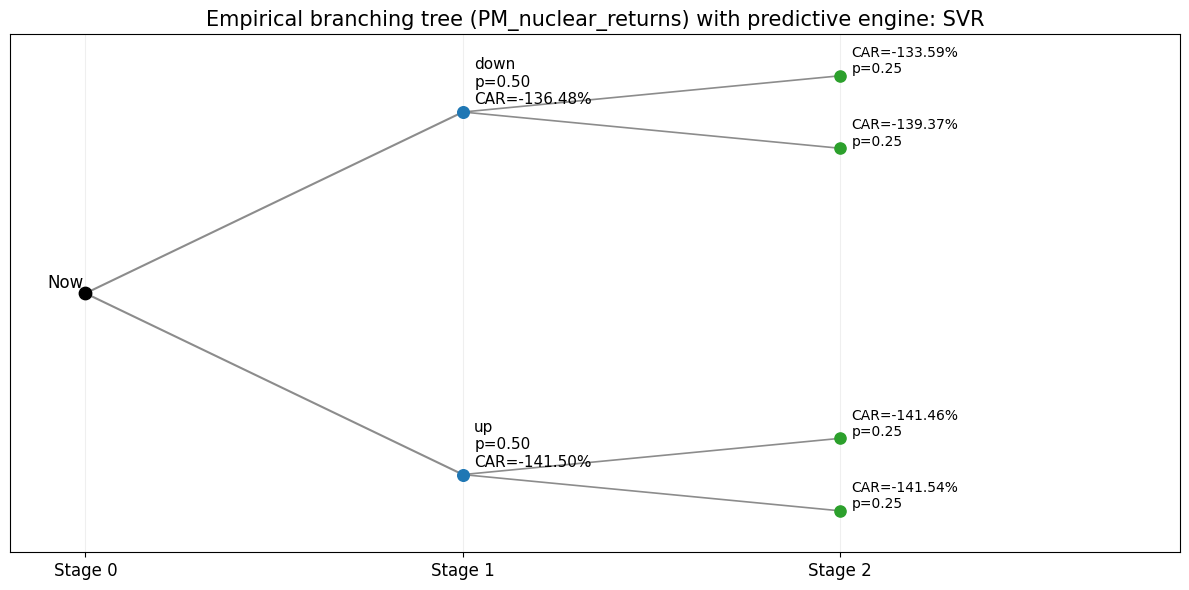

In [23]:
# Stage-based branching-tree visualization (nuclear-only)
import numpy as np
import matplotlib.pyplot as plt

if "scenario_summary_by_market" not in globals() or not isinstance(scenario_summary_by_market, dict) or not scenario_summary_by_market:
    raise ValueError("scenario_summary_by_market is required. Run the market-specific branching simulation cell first.")
if "model_pipeline_summary" not in globals():
    model_pipeline_summary = None


def _fmt_pct(x):
    return f"{100.0 * float(x):+.2f}%"


# Force nuclear-only rendering even if stale multi-market keys remain in kernel memory.
nuclear_keys = [k for k in scenario_summary_by_market.keys() if "nuclear" in str(k).lower()]
if not nuclear_keys:
    raise ValueError("No nuclear market found in scenario_summary_by_market. Run the nuclear branching simulation cell first.")

for market_key in nuclear_keys:
    s_df = scenario_summary_by_market.get(market_key)
    if s_df is None or s_df.empty:
        continue

    work = s_df.copy()
    work = work.sort_values(["stage1", "terminal_resolution"]).reset_index(drop=True)

    stage1_stats = (
        work.groupby("stage1", as_index=False)
        .apply(
            lambda g: pd.Series(
                {
                    "stage1_prob": float(g["probability"].sum()),
                    "stage1_expected_car": float(np.average(g["terminal_abnormal_return"], weights=g["probability"])) if float(g["probability"].sum()) > 0 else np.nan,
                    "stage1_prob_level": float(g["stage1_prob_node"].iloc[0]) if "stage1_prob_node" in g.columns else np.nan,
                }
            )
        )
        .reset_index(drop=True)
    )

    stage1_order = stage1_stats["stage1"].tolist()
    n1 = len(stage1_order)

    x0, x1, x2 = 0.0, 1.0, 2.0
    y0 = 0.0
    y1_vals = np.linspace(0.7, -0.7, n1) if n1 > 1 else np.array([0.0])
    y1_map = {name: float(y) for name, y in zip(stage1_order, y1_vals)}

    leaf_rows = []
    for stg in stage1_order:
        sub = work[work["stage1"] == stg].sort_values("terminal_resolution").reset_index(drop=True)
        m = len(sub)
        if m == 1:
            y_leaf = [y1_map[stg]]
        else:
            spread = 0.28
            y_leaf = np.linspace(y1_map[stg] + spread / 2, y1_map[stg] - spread / 2, m)
        for i in range(m):
            rec = sub.iloc[i].to_dict()
            rec["y_leaf"] = float(y_leaf[i])
            leaf_rows.append(rec)

    fig, ax = plt.subplots(figsize=(12, 6))

    ax.scatter([x0], [y0], color="black", s=80, zorder=3)
    ax.text(x0 - 0.1, y0 + 0.02, "Now", fontsize=12)

    for _, r in stage1_stats.iterrows():
        stg = r["stage1"]
        y1 = y1_map[stg]

        ax.plot([x0, x1], [y0, y1], color="gray", linewidth=1.5, alpha=0.9)
        ax.scatter([x1], [y1], color="#1f77b4", s=70, zorder=3)

        stage_label = (
            f"{stg}\n"
            f"p={float(r['stage1_prob']):.2f}\n"
            f"CAR={_fmt_pct(r['stage1_expected_car'])}"
        )
        ax.text(x1 + 0.03, y1 + 0.03, stage_label, fontsize=11)

    for leaf in leaf_rows:
        stg = str(leaf["stage1"])
        y1 = y1_map[stg]
        y2 = float(leaf["y_leaf"])

        ax.plot([x1, x2], [y1, y2], color="gray", linewidth=1.2, alpha=0.9)
        ax.scatter([x2], [y2], color="#2ca02c", s=65, zorder=3)

        leaf_label = (
            f"CAR={_fmt_pct(leaf['terminal_abnormal_return'])}\n"
            f"p={float(leaf['probability']):.2f}"
        )
        ax.text(x2 + 0.03, y2 + 0.01, leaf_label, fontsize=10)

    model_name = "n/a"
    if isinstance(model_pipeline_summary, pd.DataFrame) and not model_pipeline_summary.empty:
        msel = model_pipeline_summary.loc[model_pipeline_summary["market"] == market_key]
        if not msel.empty:
            model_name = str(msel.iloc[0]["selected_model"])

    ax.set_title(f"Empirical branching tree ({market_key}) with predictive engine: {model_name}", fontsize=15)
    ax.set_xticks([x0, x1, x2])
    ax.set_xticklabels(["Stage 0", "Stage 1", "Stage 2"], fontsize=12)
    ax.set_yticks([])
    ax.grid(axis="x", alpha=0.2)
    ax.set_xlim(-0.2, 2.9)
    ax.set_ylim(-1.0, 1.0)
    plt.tight_layout()
    plt.show()

One-step counterfactual sensitivity to PM return shock (x_t = +/-5pp):


,market,family,model,baseline_h1,delta_h1_if_plus5pp,delta_h1_if_minus5pp,local_dy_dx_approx
0,PM_nuclear_returns,ML,SVR,-23.934453,0.283879,-0.260503,0.054438


Sensitivity grid summary (terminal and cumulative impact):


,market,family,model,horizon_days,shock_pp,impact_h1,impact_terminal,impact_cumulative
0,PM_nuclear_returns,ML,SVR,1,-15.0,-0.664080,-0.664080,-0.664080
1,PM_nuclear_returns,ML,SVR,2,-15.0,-0.664080,2.133612,1.469532
2,PM_nuclear_returns,ML,SVR,3,-15.0,-0.664080,3.375282,4.844814
3,PM_nuclear_returns,ML,SVR,5,-15.0,-0.664080,3.233319,11.300618
4,PM_nuclear_returns,ML,SVR,1,-10.0,-0.484709,-0.484709,-0.484709
5,PM_nuclear_returns,ML,SVR,2,-10.0,-0.484709,1.274659,0.789950
6,PM_nuclear_returns,ML,SVR,3,-10.0,-0.484709,2.268894,3.058844
7,PM_nuclear_returns,ML,SVR,5,-10.0,-0.484709,2.164303,7.378865
8,PM_nuclear_returns,ML,SVR,1,-5.0,-0.260503,-0.260503,-0.260503
9,PM_nuclear_returns,ML,SVR,2,-5.0,-0.260503,0.509462,0.248959


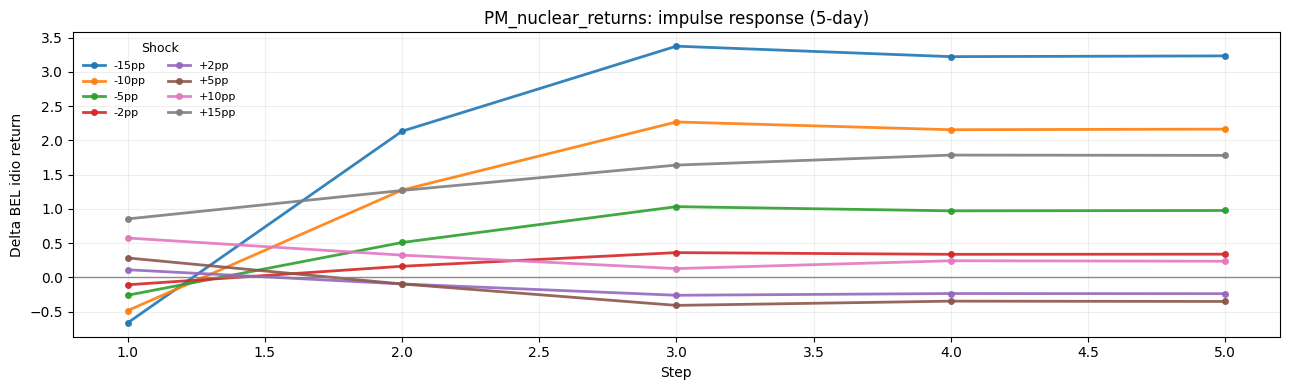

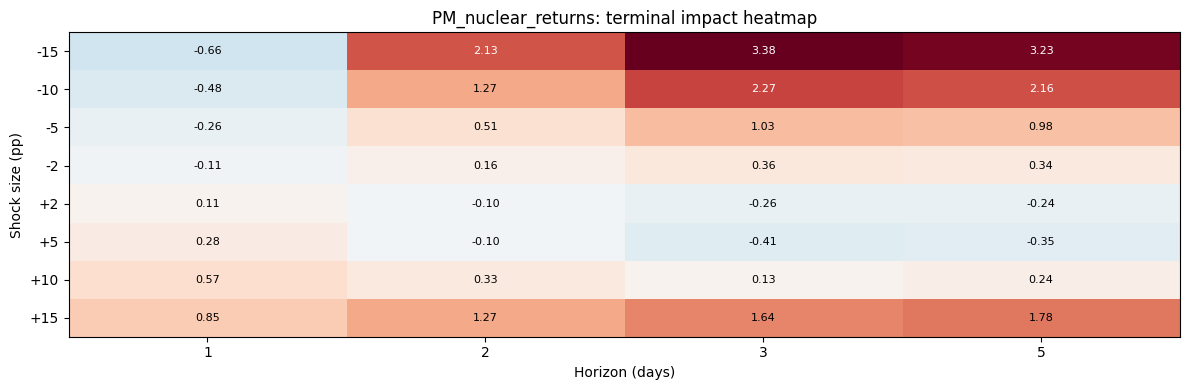

In [24]:
# ====================================================
# Impulse-response and shock sensitivity (Argentina-style)
# Uses market-specific selected models from the two-pipeline cell
# ====================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor

canonical_model = None
canonical_family = "ML"
canonical_source = "combined_bakeoff_validation"
if "best_models" in globals() and isinstance(best_models, dict):
    canonical_model = best_models.get("selected_model_for_simulation") or best_models.get("production_model_name")
    canonical_family = str(best_models.get("selected_model_family", canonical_family))
    canonical_source = str(best_models.get("final_model_selection_source", canonical_source))
if canonical_model is None:
    raise ValueError("Run the model-selection cell before this sensitivity analysis so the selected model is available.")
model_pipeline_summary = pd.DataFrame([
    {
        "market": "PM_nuclear_returns",
        "selected_model": str(canonical_model),
        "selected_family": canonical_family,
        "source": canonical_source,
    }
])
if "sim_df_all" not in globals() or not isinstance(sim_df_all, pd.DataFrame) or sim_df_all.empty:
    if "hourly_aligned" not in globals() or not isinstance(hourly_aligned, pd.DataFrame) or hourly_aligned.empty:
        raise ValueError("hourly_aligned is required to reconstruct sim_df_all.")
    required_cols = ["timestamp", "price_Yes_nuclear", "Country Hourly - Belgium", "BEL_idiosyncratic"]
    missing_cols = [c for c in required_cols if c not in hourly_aligned.columns]
    if missing_cols:
        raise ValueError(f"Missing required columns in hourly_aligned: {missing_cols}")
    sim_df_all = hourly_aligned[required_cols].copy().sort_values("timestamp").reset_index(drop=True)
    sim_df_all["PM_nuclear_returns"] = sim_df_all["price_Yes_nuclear"].pct_change() * 100
    sim_df_all = sim_df_all.dropna().copy()
if "t0_pos" not in globals():
    horizon = 5
    t0_pos = len(sim_df_all) - (horizon + 1)
if "simulate_market_path" not in globals():
    n_lags_ml = 3

    def model_space():
        return {
            "Ridge": Ridge(alpha=1.0),
            "Lasso": Lasso(alpha=0.01, max_iter=20000, random_state=42),
            "ElasticNet": ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=20000, random_state=42),
            "RandomForest": RandomForestRegressor(n_estimators=300, min_samples_leaf=2, random_state=42),
            "ExtraTrees": ExtraTreesRegressor(n_estimators=400, min_samples_leaf=2, random_state=42),
            "GradientBoosting": GradientBoostingRegressor(random_state=42),
            "SVR_linear": Pipeline([("scale", StandardScaler()), ("svr", SVR(C=5.0, epsilon=0.1, kernel="linear", gamma="scale"))]),
            "SVR": Pipeline([("scale", StandardScaler()), ("svr", SVR(C=1.0, epsilon=0.1, gamma="scale"))]),
            "FoundationModel": GradientBoostingRegressor(n_estimators=500, learning_rate=0.02, max_depth=2, random_state=42),
        }

    def build_lagged_xy(train_df, x_col, y_col, n_lags):
        rows = []
        for t in range(n_lags, len(train_df)):
            rec = {"target": float(train_df.iloc[t][y_col])}
            for lag in range(1, n_lags + 1):
                rec[f"{x_col}_lag{lag}"] = float(train_df.iloc[t - lag][x_col])
                rec[f"{y_col}_lag{lag}"] = float(train_df.iloc[t - lag][y_col])
            rows.append(rec)
        out = pd.DataFrame(rows)
        if out.empty:
            return pd.DataFrame(), pd.Series(dtype=float), []
        feat_cols = [c for c in out.columns if c != "target"]
        return out[feat_cols], out["target"], feat_cols

    def simulate_market_path(train_market, x_col, y_col, selected_model, x_future_path):
        x_hist = train_market[x_col].astype(float).tolist()
        y_hist = train_market[y_col].astype(float).tolist()
        mspace = model_space()
        if selected_model not in mspace:
            raise ValueError(f"Selected model {selected_model} is not available in the simulation model space.")
        X_train, y_train, feat_cols = build_lagged_xy(train_market, x_col, y_col, n_lags_ml)
        if len(X_train) < 30:
            return np.zeros(len(x_future_path), dtype=float)
        model = clone(mspace[selected_model])
        model.fit(X_train, y_train)
        y_path = []
        for x_shock in np.asarray(x_future_path, dtype=float):
            x_next = x_hist[-1] + float(x_shock)
            rec = {}
            x_tmp = x_hist + [x_next]
            y_tmp = y_hist
            for lag in range(1, n_lags_ml + 1):
                rec[f"{x_col}_lag{lag}"] = float(x_tmp[-lag])
                rec[f"{y_col}_lag{lag}"] = float(y_tmp[-lag])
            X_next = pd.DataFrame([rec], columns=feat_cols)
            y_next = float(model.predict(X_next)[0])
            y_path.append(y_next)
            x_hist.append(x_next)
            y_hist.append(y_next)
        return np.asarray(y_path, dtype=float)

y_idio_col = "BEL_idiosyncratic"
market_cols = ["PM_nuclear_returns"]
horizon_grid = [1, 2, 3, 5]
shock_pp_grid = [2, 5, 10, 15]
full_horizon = int(globals().get("horizon", 5))

rows = []
one_step_rows = []
irf_curve_rows = []

for mkt in market_cols:
    sel = model_pipeline_summary.loc[model_pipeline_summary["market"] == mkt]
    if sel.empty:
        raise ValueError(f"Selected model not found in model_pipeline_summary for {mkt}")

    selected_model = str(sel.iloc[0]["selected_model"])
    selected_family = str(sel.iloc[0]["selected_family"])
    train_market = sim_df_all.iloc[: t0_pos + 1][[mkt, y_idio_col]].copy()

    # Build branch summaries for downstream reporting
    pm_hist = train_market[mkt].dropna().astype(float)
    q_up = float(pm_hist.quantile(0.75))
    q_down = float(pm_hist.quantile(0.25))
    stage1_nodes = {"up": q_up, "down": q_down}
    scenario_rows = []
    for stage1, s1_shock in stage1_nodes.items():
        x_stage1 = np.zeros(full_horizon, dtype=float)
        x_stage1[0] = s1_shock
        y_stage1 = simulate_market_path(train_market, mkt, y_idio_col, selected_model, x_stage1)
        stage1_expected_car = float(np.sum(y_stage1[:1]) / 100.0)
        for stage2, s2_shock in {"up": q_up, "down": q_down}.items():
            x_path = np.zeros(full_horizon, dtype=float)
            x_path[0] = s1_shock
            x_path[1] = s2_shock
            y_path = simulate_market_path(train_market, mkt, y_idio_col, selected_model, x_path)
            terminal_abnormal_return = float(np.sum(y_path) / 100.0)
            scenario_rows.append({
                "market": mkt,
                "stage1": stage1,
                "stage2": stage2,
                "probability": 0.25,
                "stage1_prob": 0.50,
                "stage1_expected_car": stage1_expected_car,
                "terminal_abnormal_return": terminal_abnormal_return,
                "terminal_resolution": stage2,
            })
    scenario_summary = pd.DataFrame(scenario_rows)
    terminal_summary = (
        scenario_summary.groupby("terminal_resolution", as_index=False)
        .agg(probability=("probability", "sum"), terminal_abnormal_return=("terminal_abnormal_return", "mean"))
        .sort_values("terminal_resolution")
        .reset_index(drop=True)
    )
    scenario_summary_by_market = {mkt: scenario_summary.copy()}
    terminal_summary_by_market = {mkt: terminal_summary.copy()}

    x_base_full = np.zeros(full_horizon, dtype=float)
    y_base_full = simulate_market_path(train_market, mkt, y_idio_col, selected_model, x_base_full)

    for horizon_days in horizon_grid:
        if horizon_days > full_horizon:
            raise ValueError(f"Requested horizon {horizon_days} exceeds full horizon {full_horizon}")

        y_base = y_base_full[:horizon_days]

        for shock_pp in shock_pp_grid:
            for shock_sign in [1.0, -1.0]:
                signed_shock = float(shock_sign * shock_pp)
                x_shock_full = np.zeros(full_horizon, dtype=float)
                x_shock_full[0] = signed_shock

                y_shock_full = simulate_market_path(train_market, mkt, y_idio_col, selected_model, x_shock_full)
                y_shock = y_shock_full[:horizon_days]
                irf_path = y_shock - y_base

                rows.append({
                    "market": mkt,
                    "family": selected_family,
                    "model": selected_model,
                    "horizon_days": int(horizon_days),
                    "shock_pp": float(signed_shock),
                    "impact_h1": float(irf_path[0]),
                    "impact_terminal": float(irf_path[-1]),
                    "impact_cumulative": float(np.sum(irf_path)),
                })

                for h in range(horizon_days):
                    irf_curve_rows.append({
                        "market": mkt,
                        "model": selected_model,
                        "family": selected_family,
                        "shock_pp": float(signed_shock),
                        "horizon_days": int(horizon_days),
                        "step": int(h + 1),
                        "irf_delta_idio_return": float(irf_path[h]),
                    })

    x0 = np.zeros(full_horizon, dtype=float)
    y0 = simulate_market_path(train_market, mkt, y_idio_col, selected_model, x0)[0]
    x_p5 = np.zeros(full_horizon, dtype=float)
    x_p5[0] = 5.0
    x_m5 = np.zeros(full_horizon, dtype=float)
    x_m5[0] = -5.0
    y_p5 = simulate_market_path(train_market, mkt, y_idio_col, selected_model, x_p5)[0]
    y_m5 = simulate_market_path(train_market, mkt, y_idio_col, selected_model, x_m5)[0]

    one_step_rows.append({
        "market": mkt,
        "family": selected_family,
        "model": selected_model,
        "baseline_h1": float(y0),
        "delta_h1_if_plus5pp": float(y_p5 - y0),
        "delta_h1_if_minus5pp": float(y_m5 - y0),
        "local_dy_dx_approx": float((y_p5 - y_m5) / 10.0),
    })

sensitivity_irf_grid = pd.DataFrame(rows).sort_values(["market", "shock_pp", "horizon_days"]).reset_index(drop=True)
irf_curve_df = pd.DataFrame(irf_curve_rows).sort_values(["market", "shock_pp", "horizon_days", "step"]).reset_index(drop=True)
one_step_irf_sensitivity = pd.DataFrame(one_step_rows).sort_values("market").reset_index(drop=True)

print("One-step counterfactual sensitivity to PM return shock (x_t = +/-5pp):")
display(one_step_irf_sensitivity)

print("Sensitivity grid summary (terminal and cumulative impact):")
display(sensitivity_irf_grid)

plot_df = irf_curve_df[irf_curve_df["horizon_days"] == 5].copy()
fig, axes = plt.subplots(1, len(market_cols), figsize=(13, 4), sharey=True)
if len(market_cols) == 1:
    axes = [axes]

for ax, mkt in zip(axes, market_cols):
    sub = plot_df[plot_df["market"] == mkt].copy()
    for shock in sorted(sub["shock_pp"].unique()):
        s = sub[sub["shock_pp"] == shock].sort_values("step")
        ax.plot(s["step"], s["irf_delta_idio_return"], marker="o", markersize=4, linewidth=2.0, alpha=0.9, label=f"{shock:+.0f}pp")
    ax.axhline(0.0, color="gray", linewidth=1.0, alpha=0.9)
    ax.set_title(f"{mkt}: impulse response (5-day)", fontsize=12)
    ax.set_xlabel("Step")
    ax.set_ylabel("Delta BEL idio return")
    ax.grid(alpha=0.2)
    ax.legend(title="Shock", fontsize=8, title_fontsize=9, ncol=2, frameon=False, loc="best")

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, len(market_cols), figsize=(12, 4), sharey=True)
if len(market_cols) == 1:
    axes = [axes]

for ax, mkt in zip(axes, market_cols):
    sub = sensitivity_irf_grid[sensitivity_irf_grid["market"] == mkt].copy()
    piv = sub.pivot(index="shock_pp", columns="horizon_days", values="impact_terminal").sort_index()

    vmax = float(np.nanmax(np.abs(piv.values))) if np.isfinite(piv.values).any() else 1.0
    norm = TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)
    ax.imshow(piv.values, aspect="auto", cmap="RdBu_r", norm=norm)

    ax.set_title(f"{mkt}: terminal impact heatmap", fontsize=12)
    ax.set_xlabel("Horizon (days)")
    ax.set_ylabel("Shock size (pp)")
    ax.set_xticks(np.arange(len(piv.columns)))
    ax.set_xticklabels([str(c) for c in piv.columns])
    ax.set_yticks(np.arange(len(piv.index)))
    ax.set_yticklabels([f"{v:+.0f}" for v in piv.index])

    for i in range(piv.shape[0]):
        for j in range(piv.shape[1]):
            val = float(piv.values[i, j])
            txt_color = "white" if abs(val) > 0.55 * vmax else "black"
            ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=8, color=txt_color)

plt.tight_layout()
plt.show()

## 9) Nuclear Market Analysis
Produce path-level branch summaries, terminal-node reporting, one-step counterfactual sensitivity, and multi-horizon shock grids for the nuclear pipeline.

In [25]:
# Nuclear-only reporting block (Argentina-style summaries)
import pandas as pd

nuclear_key = "PM_nuclear_returns"
if "scenario_summary_by_market" not in globals() or nuclear_key not in scenario_summary_by_market:
    raise ValueError("Nuclear scenario summary missing. Run the market-specific branching cell first.")
if "terminal_summary_by_market" not in globals() or nuclear_key not in terminal_summary_by_market:
    raise ValueError("Nuclear terminal summary missing. Run the market-specific branching cell first.")
if "one_step_irf_sensitivity" not in globals() or not isinstance(one_step_irf_sensitivity, pd.DataFrame):
    raise ValueError("one_step_irf_sensitivity missing. Run the impulse-response cell first.")
if "sensitivity_irf_grid" not in globals() or not isinstance(sensitivity_irf_grid, pd.DataFrame):
    raise ValueError("sensitivity_irf_grid missing. Run the impulse-response cell first.")

nuclear_paths = scenario_summary_by_market[nuclear_key].copy()
nuclear_terminal = terminal_summary_by_market[nuclear_key].copy()
nuclear_one_step = one_step_irf_sensitivity[one_step_irf_sensitivity["market"] == nuclear_key].copy().reset_index(drop=True)
nuclear_grid = sensitivity_irf_grid[sensitivity_irf_grid["market"] == nuclear_key].copy().reset_index(drop=True)

print("Binomial path-level summary:")
display(nuclear_paths)

print("Terminal-node summary (only two final nodes):")
display(nuclear_terminal)

print("One-step counterfactual sensitivity to PM return shock (x_t = +/-5pp):")
display(nuclear_one_step)

print("Sensitivity grid summary (terminal and cumulative impact):")
display(nuclear_grid)

nuclear_prob_check = float(nuclear_paths["probability"].sum())
print(f"Total probability across all branches: {nuclear_prob_check:.6f}")

Binomial path-level summary:


,market,stage1,stage2,probability,stage1_prob,stage1_expected_car,terminal_abnormal_return,terminal_resolution
0,PM_nuclear_returns,up,up,0.25,0.5,-0.237270,-1.415423,up
1,PM_nuclear_returns,up,down,0.25,0.5,-0.237270,-1.414619,down
2,PM_nuclear_returns,down,up,0.25,0.5,-0.242548,-1.393734,up
3,PM_nuclear_returns,down,down,0.25,0.5,-0.242548,-1.335871,down


Terminal-node summary (only two final nodes):


,terminal_resolution,probability,terminal_abnormal_return
0,down,0.5,-1.375245
1,up,0.5,-1.404579


One-step counterfactual sensitivity to PM return shock (x_t = +/-5pp):


,market,family,model,baseline_h1,delta_h1_if_plus5pp,delta_h1_if_minus5pp,local_dy_dx_approx
0,PM_nuclear_returns,ML,SVR,-23.934453,0.283879,-0.260503,0.054438


Sensitivity grid summary (terminal and cumulative impact):


,market,family,model,horizon_days,shock_pp,impact_h1,impact_terminal,impact_cumulative
0,PM_nuclear_returns,ML,SVR,1,-15.0,-0.664080,-0.664080,-0.664080
1,PM_nuclear_returns,ML,SVR,2,-15.0,-0.664080,2.133612,1.469532
2,PM_nuclear_returns,ML,SVR,3,-15.0,-0.664080,3.375282,4.844814
3,PM_nuclear_returns,ML,SVR,5,-15.0,-0.664080,3.233319,11.300618
4,PM_nuclear_returns,ML,SVR,1,-10.0,-0.484709,-0.484709,-0.484709
5,PM_nuclear_returns,ML,SVR,2,-10.0,-0.484709,1.274659,0.789950
6,PM_nuclear_returns,ML,SVR,3,-10.0,-0.484709,2.268894,3.058844
7,PM_nuclear_returns,ML,SVR,5,-10.0,-0.484709,2.164303,7.378865
8,PM_nuclear_returns,ML,SVR,1,-5.0,-0.260503,-0.260503,-0.260503
9,PM_nuclear_returns,ML,SVR,2,-5.0,-0.260503,0.509462,0.248959


Total probability across all branches: 1.000000


In [26]:
# Compare daily factor-model explanatory power: weather-only vs weather+load (daily frequency)
import numpy as np
import pandas as pd

if "hourly_aligned" not in globals() or not isinstance(hourly_aligned, pd.DataFrame):
    raise ValueError("hourly_aligned (daily data) is required. Run the factor-model cells first.")

print("Columns in hourly_aligned:", hourly_aligned.columns.tolist())

base_target = "Country Hourly - Belgium"
weather_cols = ["BE Temp (C)", "BE Precipitation (mm)", "BE Wind Speed (km/h)"]
load_cols = ["pct_BE_actual_load", "pct_BE_forecast_load", "pct_BE_forecast_vs_actual_load"]

missing_weather = [c for c in weather_cols + [base_target] if c not in hourly_aligned.columns]
if missing_weather:
    raise ValueError(f"Missing weather/target columns in hourly_aligned: {missing_weather}")

def fit_pca_factor_model(df, target_col, factor_cols, label):
    work = df[["timestamp", target_col] + factor_cols].copy().sort_values("timestamp").reset_index(drop=True)
    work[factor_cols + [target_col]] = work[factor_cols + [target_col]].interpolate(method="linear", limit_area="inside")
    work["BEL_returns"] = work[target_col].pct_change() * 100
    ret_df = work[["timestamp", "BEL_returns"] + factor_cols].dropna().copy()

    if len(ret_df) < 5:
        return {"label": label, "n_obs": len(ret_df), "error": "too_few_rows"}

    std = ret_df[factor_cols].std(axis=0, ddof=0)
    active = std[std > 0].index.tolist()
    if not active:
        return {"label": label, "n_obs": len(ret_df), "error": "no_active_factors"}

    X = ret_df[active]
    y = ret_df["BEL_returns"]
    Xz = ((X - X.mean(axis=0)) / X.std(axis=0, ddof=0)).dropna().copy()
    y = y.loc[Xz.index]

    U, S, _ = np.linalg.svd(Xz.to_numpy(), full_matrices=False)
    explained = (S**2) / np.sum(S**2)
    n_components = max(1, int(np.searchsorted(np.cumsum(explained), 0.95) + 1))
    scores = U * S
    X_pca = scores[:, :n_components]

    X_design = np.column_stack([np.ones(len(X_pca)), X_pca])
    coef = np.linalg.lstsq(X_design, y.to_numpy(), rcond=None)[0]
    fitted = X_design @ coef
    resid = y.to_numpy() - fitted

    rss = float(np.sum(resid**2))
    tss = float(np.sum((y.to_numpy() - y.mean())**2))
    r2 = float(1 - rss / tss) if tss > 0 else float("nan")
    n = len(y)
    k = n_components
    adj_r2 = float(1 - (1 - r2) * (n - 1) / (n - k - 1)) if n > (k + 1) else float("nan")

    return {
        "label": label,
        "n_obs": int(n),
        "n_active_factors": int(len(active)),
        "n_components": int(n_components),
        "r2": r2,
        "adj_r2": adj_r2,
        "resid_std": float(np.std(resid, ddof=1)) if n > 1 else float("nan"),
        "active_factors": active,
    }

results = []
results.append(fit_pca_factor_model(hourly_aligned, base_target, weather_cols, "Weather only (daily)"))

available_load_cols = [c for c in load_cols if c in hourly_aligned.columns]
print(f"Available load columns: {available_load_cols}")
if len(available_load_cols) == len(load_cols):
    results.append(
        fit_pca_factor_model(
            hourly_aligned,
            base_target,
            weather_cols + load_cols,
            "Weather + daily load factors",
        )
    )
else:
    print("Skipping weather+load comparison because load factors are missing:", [c for c in load_cols if c not in hourly_aligned.columns])

comp = pd.DataFrame([{k: v for k, v in r.items() if k != "active_factors"} for r in results])
display(comp)

for r in results:
    print("\n", r["label"], sep="")
    if "error" in r:
        print("Error:", r["error"])
        continue
    print("Active factors:", r["active_factors"])
    print(f"R2: {r['r2']:.4f} | Adj R2: {r['adj_r2']:.4f} | Residual std: {r['resid_std']:.4f}")

Columns in hourly_aligned: ['timestamp', 'price_No', 'price_Yes', 'price_Yes_nuclear', 'Country Hourly - Belgium', 'BE Temp (C)', 'BE Precipitation (mm)', 'BE Wind Speed (km/h)', 'pct_BE_actual_load', 'pct_BE_forecast_load', 'pct_BE_forecast_vs_actual_load', 'BEL_returns', 'BEL_fitted', 'BEL_idiosyncratic']
Available load columns: ['pct_BE_actual_load', 'pct_BE_forecast_load', 'pct_BE_forecast_vs_actual_load']


,label,n_obs,n_active_factors,n_components,r2,adj_r2,resid_std
0,Weather only (daily),363,3,3,0.011027,0.002763,557.690872
1,Weather + daily load factors,363,6,5,0.011082,-0.002768,557.675476



Weather only (daily)
Active factors: ['BE Temp (C)', 'BE Precipitation (mm)', 'BE Wind Speed (km/h)']
R2: 0.0110 | Adj R2: 0.0028 | Residual std: 557.6909

Weather + daily load factors
Active factors: ['BE Temp (C)', 'BE Precipitation (mm)', 'BE Wind Speed (km/h)', 'pct_BE_actual_load', 'pct_BE_forecast_load', 'pct_BE_forecast_vs_actual_load']
R2: 0.0111 | Adj R2: -0.0028 | Residual std: 557.6755


## 10) Deterministic Hedge Sizing
Translate deterministic joint branch outcomes into hedge sizing inputs and recommendation tables.

In [27]:
# ====================================================
# Proposal-aligned hedge sizing using JOINT market probabilities
# Consumes joint_terminal_scenarios from the separate-tree simulation cell
# ====================================================

portfolio_value = 1_000_000
risk_budget_fraction = 0.015
execution_haircut = 0.70
hedge_efficiency = 0.60  # conservative payoff efficiency after costs/slippage

# Exposure convention:
# - short_price: rising electricity prices are adverse (buyer/procurement view)
# - long_price: falling electricity prices are adverse (producer view)
exposure_to_price = "short_price"

if "scenario_summary" in globals() and isinstance(scenario_summary, pd.DataFrame) and not scenario_summary.empty:
    hedge_table = scenario_summary.copy()
elif "joint_terminal_scenarios" in globals() and isinstance(joint_terminal_scenarios, pd.DataFrame) and not joint_terminal_scenarios.empty:
    hedge_table = joint_terminal_scenarios.copy()
else:
    raise ValueError("No scenario table found. Run the separate-tree simulation cell first.")

# Keep compatibility fields
if "year_shift" not in hedge_table.columns:
    hedge_table["year_shift"] = np.nan
if "horizon_days" not in hedge_table.columns:
    hedge_table["horizon_days"] = np.nan
if "terminal_resolution" not in hedge_table.columns:
    hedge_table["terminal_resolution"] = np.nan
if "stage1" not in hedge_table.columns:
    hedge_table["stage1"] = hedge_table["branch"].astype(str).str.lower().map({
        "advanced agi": "advanced",
        "central": "central",
        "delayed agi": "severe_delay",
    }).fillna("unknown")

ret = hedge_table["terminal_abnormal_return"].to_numpy(dtype=float)
w = hedge_table["probability"].to_numpy(dtype=float)

if exposure_to_price == "short_price":
    loss = np.maximum(ret, 0.0)
elif exposure_to_price == "long_price":
    loss = np.maximum(-ret, 0.0)
else:
    raise ValueError("exposure_to_price must be 'short_price' or 'long_price'.")

weighted_loss = float(np.sum(w * loss))

if weighted_loss <= risk_budget_fraction:
    target_coverage = 0.0
else:
    target_coverage = (weighted_loss - risk_budget_fraction) / weighted_loss

raw_hedge_notional_pct = target_coverage / hedge_efficiency if hedge_efficiency > 0 else 0.0
hedge_notional_pct = float(np.clip(raw_hedge_notional_pct * execution_haircut, 0.0, 0.80))
hedge_notional_usd = hedge_notional_pct * portfolio_value


def hedge_instrument_mix(terminal_ret: float, side: str) -> str:
    if side == "short_price":
        if terminal_ret <= 0:
            return "No upside power-price hedge required; keep optional flexibility."
        if terminal_ret < 0.02:
            return "Light hedge: staged baseload futures/swaps for near delivery window."
        if terminal_ret < 0.05:
            return "Medium hedge: layered fixed-price forwards + upside cap structure."
        return "Strong hedge: high hedge ratio via strips/swaps plus call-option caps."

    if terminal_ret >= 0:
        return "No downside power-price hedge required; keep upside participation."
    if terminal_ret > -0.02:
        return "Light hedge: modest floor via put spread or fixed-price tranche."
    if terminal_ret > -0.05:
        return "Medium hedge: protective floor/collar with staged execution."
    return "Strong hedge: high floor coverage + partial de-risking of merchant exposure."


hedge_table["recommended_hedge_structure"] = hedge_table["terminal_abnormal_return"].apply(
    lambda x: hedge_instrument_mix(float(x), exposure_to_price)
)
hedge_table["suggested_hedge_notional_pct_of_exposure"] = hedge_notional_pct
hedge_table["suggested_hedge_notional_usd"] = hedge_notional_usd

# Display columns depending on joint-vs-legacy format
base_cols = [
    "branch",
    "stage1",
    "probability",
    "year_shift",
    "horizon_days",
    "terminal_abnormal_return",
    "max_drawdown",
    "recommended_hedge_structure",
    "suggested_hedge_notional_pct_of_exposure",
    "suggested_hedge_notional_usd",
]

joint_cols = ["market1", "market1_resolution", "market2", "market2_resolution", "joint_probability_source"]
show_cols = [c for c in (joint_cols + base_cols) if c in hedge_table.columns]

print(f"Exposure mode: {exposure_to_price}")
display(hedge_table[show_cols])

hedge_policy = pd.DataFrame(
    {
        "parameter": [
            "portfolio_value",
            "exposure_to_price",
            "risk_budget_fraction",
            "execution_haircut",
            "hedge_efficiency",
            "weighted_loss",
            "target_coverage",
            "final_hedge_notional_pct",
            "final_hedge_notional_usd",
        ],
        "value": [
            portfolio_value,
            exposure_to_price,
            risk_budget_fraction,
            execution_haircut,
            hedge_efficiency,
            weighted_loss,
            target_coverage,
            hedge_notional_pct,
            hedge_notional_usd,
        ],
    }
)

display(hedge_policy)

market_hedge_rows = []
if "terminal_summary_by_market" in globals() and isinstance(terminal_summary_by_market, dict):
    for market_key, terminal_df in terminal_summary_by_market.items():
        if not isinstance(terminal_df, pd.DataFrame) or terminal_df.empty:
            continue

        ts = terminal_df.copy()
        prob_col = "total_probability" if "total_probability" in ts.columns else "probability"
        ret_col = "expected_terminal_abnormal_return" if "expected_terminal_abnormal_return" in ts.columns else "terminal_abnormal_return"
        probs_m = ts[prob_col].to_numpy(dtype=float)
        rets_m = ts[ret_col].to_numpy(dtype=float)

        if exposure_to_price == "short_price":
            loss_m = np.maximum(rets_m, 0.0)
            downside_prob_m = float(np.sum(probs_m[rets_m > 0]))
            adverse_ret_m = float(np.nanmax(rets_m))
        else:
            loss_m = np.maximum(-rets_m, 0.0)
            downside_prob_m = float(np.sum(probs_m[rets_m < 0]))
            adverse_ret_m = float(np.nanmin(rets_m))

        weighted_loss_m = float(np.sum(probs_m * loss_m))
        if weighted_loss_m <= risk_budget_fraction:
            target_coverage_m = 0.0
        else:
            target_coverage_m = (weighted_loss_m - risk_budget_fraction) / weighted_loss_m

        raw_notional_pct_m = target_coverage_m / hedge_efficiency if hedge_efficiency > 0 else 0.0
        hedge_notional_pct_m = float(np.clip(raw_notional_pct_m * execution_haircut, 0.0, 0.80))
        hedge_notional_usd_m = hedge_notional_pct_m * portfolio_value

        exp_ret_m = float(np.average(rets_m, weights=probs_m)) if float(np.sum(probs_m)) > 0 else np.nan
        if "weighted_max_drawdown" in ts.columns:
            exp_drawdown_m = float(np.average(ts["weighted_max_drawdown"].to_numpy(dtype=float), weights=probs_m)) if float(np.sum(probs_m)) > 0 else np.nan
        else:
            exp_drawdown_m = np.nan

        market_key_lower = str(market_key).lower()
        if "nuclear" in market_key_lower:
            market_label = "Nuclear PM"
        else:
            market_label = str(market_key).replace("pm_", "").replace("_return", "").replace("_", " ").strip().title()

        market_hedge_rows.append(
            {
                "market": market_label if market_label else str(market_key),
                "expected_terminal_abnormal_return": exp_ret_m,
                "downside_probability": downside_prob_m,
                "expected_weighted_max_drawdown": exp_drawdown_m,
                "suggested_hedge_notional_pct_of_exposure": hedge_notional_pct_m,
                "suggested_hedge_notional_usd": hedge_notional_usd_m,
                "recommended_hedge_structure": hedge_instrument_mix(adverse_ret_m, exposure_to_price),
            }
        )

hedge_recommendation_by_market_table = pd.DataFrame(market_hedge_rows)
if not hedge_recommendation_by_market_table.empty:
    hedge_recommendation_by_market_table = hedge_recommendation_by_market_table.sort_values(
        "suggested_hedge_notional_pct_of_exposure", ascending=False
    ).reset_index(drop=True)
    print("Hedge recommendation by PM market (from each PM terminal analysis):")
    display(hedge_recommendation_by_market_table)

print("Research use only: scenario-based hedge sizing for thesis simulation, not investment advice.")

hedge_recommendation_table = hedge_table
hedge_recommendation_by_market = hedge_recommendation_by_market_table
hedge_policy_table = hedge_policy


Exposure mode: short_price


,stage1,probability,year_shift,horizon_days,terminal_abnormal_return,recommended_hedge_structure,suggested_hedge_notional_pct_of_exposure,suggested_hedge_notional_usd
0,up,0.25,NaN,NaN,-1.415423,No upside power-price hedge required; keep opt...,0.0,0.0
1,up,0.25,NaN,NaN,-1.414619,No upside power-price hedge required; keep opt...,0.0,0.0
2,down,0.25,NaN,NaN,-1.393734,No upside power-price hedge required; keep opt...,0.0,0.0
3,down,0.25,NaN,NaN,-1.335871,No upside power-price hedge required; keep opt...,0.0,0.0


,parameter,value
0,portfolio_value,1000000
1,exposure_to_price,short_price
2,risk_budget_fraction,0.015
3,execution_haircut,0.7
4,hedge_efficiency,0.6
5,weighted_loss,0.0
6,target_coverage,0.0
7,final_hedge_notional_pct,0.0
8,final_hedge_notional_usd,0.0


Hedge recommendation by PM market (from each PM terminal analysis):


,market,expected_terminal_abnormal_return,downside_probability,expected_weighted_max_drawdown,suggested_hedge_notional_pct_of_exposure,suggested_hedge_notional_usd,recommended_hedge_structure
0,Nuclear PM,-1.389912,0.0,NaN,0.0,0.0,No upside power-price hedge required; keep opt...


Research use only: scenario-based hedge sizing for thesis simulation, not investment advice.


In [28]:
import numpy as np
import pandas as pd
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor, ExtraTreesRegressor
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

if "separate_pm_performance" not in globals() or separate_pm_performance.empty:
    raise ValueError("Run the PM comparison cell first (it creates separate_pm_performance).")
if "ts_daily" not in globals() or not isinstance(ts_daily, pd.DataFrame):
    raise ValueError("ts_daily is required. Run upstream modeling cells first.")

nuclear_row = separate_pm_performance.loc[separate_pm_performance["market"] == "Nuclear"].iloc[0]
spec = dict(nuclear_row["spec"] if isinstance(nuclear_row["spec"], dict) else {})
model_name = str(nuclear_row["model"])

n_lags = int(spec.get("n_lags", 1))
params = dict(spec.get("params", {}))

def build_model(name: str, p: dict):
    p = dict(p)
    if name == "GradientBoosting":
        p.setdefault("random_state", 42)
        return GradientBoostingRegressor(**p)
    if name == "RandomForest":
        p.setdefault("random_state", 42)
        return RandomForestRegressor(**p)
    if name == "ExtraTrees":
        p.setdefault("random_state", 42)
        return ExtraTreesRegressor(**p)
    if name == "SVR":
        return Pipeline([("scaler", StandardScaler()), ("model", SVR(**p))])
    if name == "Ridge":
        return Pipeline([("scaler", StandardScaler()), ("model", Ridge(**p))])
    if name == "Lasso":
        return Pipeline([("scaler", StandardScaler()), ("model", Lasso(**p))])
    if name == "ElasticNet":
        return Pipeline([("scaler", StandardScaler()), ("model", ElasticNet(**p))])
    raise ValueError(f"Unsupported model for this diagnostic: {name}")

x_col = "PM_nuclear_returns"
y_col = "BEL_idiosyncratic"
ts_mkt = ts_daily[["timestamp", x_col, y_col]].dropna().reset_index(drop=True)
split_idx = len(ts_mkt) - 10
train = ts_mkt.iloc[:split_idx][[x_col, y_col]].copy()
val = ts_mkt.iloc[split_idx:][[x_col, y_col]].copy()

# Build lagged features using only nuclear driver + target lags
rows = []
for t in range(n_lags, len(train)):
    rec = {"target": float(train.iloc[t][y_col])}
    for lag in range(1, n_lags + 1):
        rec[f"x_lag{lag}"] = float(train.iloc[t - lag][x_col])
        rec[f"y_lag{lag}"] = float(train.iloc[t - lag][y_col])
    rows.append(rec)
lagged = pd.DataFrame(rows)
feat_cols = [c for c in lagged.columns if c != "target"]
X_train = lagged[feat_cols]
y_train = lagged["target"]

model = build_model(model_name, params)
model.fit(X_train, y_train)

# One-step-ahead validation using realized lags
preds = []
for i in range(len(val)):
    hist = pd.concat([train, val.iloc[:i]], axis=0).reset_index(drop=True)
    rec = {}
    for lag in range(1, n_lags + 1):
        rec[f"x_lag{lag}"] = float(hist.iloc[-lag][x_col])
        rec[f"y_lag{lag}"] = float(hist.iloc[-lag][y_col])
    x_next = pd.DataFrame([rec], columns=feat_cols)
    preds.append(float(model.predict(x_next)[0]))

y_true = val[y_col].to_numpy(dtype=float)
y_pred = np.array(preds, dtype=float)

directional_accuracy = float(np.mean(np.sign(y_pred) == np.sign(y_true)))
rmse = float(np.sqrt(np.mean((y_pred - y_true) ** 2)))
mae = float(np.mean(np.abs(y_pred - y_true)))

diag = pd.DataFrame([
    {
        "market": "Nuclear",
        "method": model_name,
        "n_validation_points": int(len(y_true)),
        "directional_accuracy": directional_accuracy,
        "rmse": rmse,
        "mae": mae,
    }
])

display(diag)
print(f"Directional accuracy (Nuclear {model_name}): {directional_accuracy:.2%}")

,market,method,n_validation_points,directional_accuracy,rmse,mae
0,Nuclear,GradientBoosting,10,1.0,64.845663,51.69348


Directional accuracy (Nuclear GradientBoosting): 100.00%


## 11) Time-Series Generalization Check
Evaluate out-of-sample robustness with chronology-preserving validation (expanding-window and rolling-window CV) using RMSE, MAE, and directional accuracy.

In [2]:
import numpy as np
import pandas as pd
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor, ExtraTreesRegressor
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

if "separate_pm_performance" not in globals() or separate_pm_performance.empty:
    raise ValueError("Run the PM comparison cell first (requires separate_pm_performance).")
if "ts_daily" not in globals() or not isinstance(ts_daily, pd.DataFrame):
    raise ValueError("Run upstream data/modeling cells first (requires ts_daily).")

# Pull selected nuclear method/spec from existing pipeline
nuclear_row = separate_pm_performance.loc[separate_pm_performance["market"] == "Nuclear"].iloc[0]
model_name = str(nuclear_row["model"])
spec = dict(nuclear_row["spec"] if isinstance(nuclear_row["spec"], dict) else {})
n_lags = int(spec.get("n_lags", 1))
params = dict(spec.get("params", {}))

def build_model(name: str, p: dict):
    p = dict(p)
    if name == "GradientBoosting":
        p.setdefault("random_state", 42)
        return GradientBoostingRegressor(**p)
    if name == "RandomForest":
        p.setdefault("random_state", 42)
        return RandomForestRegressor(**p)
    if name == "ExtraTrees":
        p.setdefault("random_state", 42)
        return ExtraTreesRegressor(**p)
    if name == "SVR":
        return Pipeline([("scaler", StandardScaler()), ("model", SVR(**p))])
    if name == "Ridge":
        return Pipeline([("scaler", StandardScaler()), ("model", Ridge(**p))])
    if name == "Lasso":
        return Pipeline([("scaler", StandardScaler()), ("model", Lasso(**p))])
    if name == "ElasticNet":
        return Pipeline([("scaler", StandardScaler()), ("model", ElasticNet(**p))])
    raise ValueError(f"Unsupported model for this CV block: {name}")

x_col = "PM_nuclear_returns"
y_col = "BEL_idiosyncratic"
ts_mkt = ts_daily[["timestamp", x_col, y_col]].dropna().reset_index(drop=True)

if len(ts_mkt) < 220:
    raise ValueError(f"Need at least ~220 rows for robust CV. Found {len(ts_mkt)}")

def build_lagged_train(df, n_lags):
    rows = []
    for t in range(n_lags, len(df)):
        rec = {"target": float(df.iloc[t][y_col])}
        for lag in range(1, n_lags + 1):
            rec[f"x_lag{lag}"] = float(df.iloc[t - lag][x_col])
            rec[f"y_lag{lag}"] = float(df.iloc[t - lag][y_col])
        rows.append(rec)
    out = pd.DataFrame(rows)
    feat_cols = [c for c in out.columns if c != "target"]
    return out[feat_cols], out["target"], feat_cols

def one_step_recursive_forecast(train_df, test_df, n_lags, model_name, params):
    X_train, y_train, feat_cols = build_lagged_train(train_df, n_lags)
    model = build_model(model_name, params)
    model.fit(X_train, y_train)

    preds = []
    for i in range(len(test_df)):
        hist = pd.concat([train_df, test_df.iloc[:i]], axis=0).reset_index(drop=True)
        rec = {}
        for lag in range(1, n_lags + 1):
            rec[f"x_lag{lag}"] = float(hist.iloc[-lag][x_col])
            rec[f"y_lag{lag}"] = float(hist.iloc[-lag][y_col])
        x_next = pd.DataFrame([rec], columns=feat_cols)
        preds.append(float(model.predict(x_next)[0]))

    y_true = test_df[y_col].to_numpy(dtype=float)
    y_pred = np.array(preds, dtype=float)

    rmse = float(np.sqrt(np.mean((y_pred - y_true) ** 2)))
    mae = float(np.mean(np.abs(y_pred - y_true)))
    da = float(np.mean(np.sign(y_pred) == np.sign(y_true)))
    return rmse, mae, da

# CV design
min_train = 180
test_size = 10
step = 10
rolling_train_size = 180

expanding_rows = []
rolling_rows = []

fold = 0
for train_end in range(min_train, len(ts_mkt) - test_size + 1, step):
    fold += 1
    test_start = train_end
    test_end = train_end + test_size

    # Expanding window: [0 : train_end)
    train_exp = ts_mkt.iloc[:train_end].copy()
    test_fold = ts_mkt.iloc[test_start:test_end].copy()
    rmse_e, mae_e, da_e = one_step_recursive_forecast(train_exp, test_fold, n_lags, model_name, params)
    expanding_rows.append(
        {
            "fold": fold,
            "train_start": int(0),
            "train_end": int(train_end - 1),
            "test_start": int(test_start),
            "test_end": int(test_end - 1),
            "train_size": int(len(train_exp)),
            "test_size": int(len(test_fold)),
            "rmse": rmse_e,
            "mae": mae_e,
            "directional_accuracy": da_e,
        }
    )

    # Rolling window: [train_end-rolling_train_size : train_end)
    train_start_roll = max(0, train_end - rolling_train_size)
    train_roll = ts_mkt.iloc[train_start_roll:train_end].copy()
    rmse_r, mae_r, da_r = one_step_recursive_forecast(train_roll, test_fold, n_lags, model_name, params)
    rolling_rows.append(
        {
            "fold": fold,
            "train_start": int(train_start_roll),
            "train_end": int(train_end - 1),
            "test_start": int(test_start),
            "test_end": int(test_end - 1),
            "train_size": int(len(train_roll)),
            "test_size": int(len(test_fold)),
            "rmse": rmse_r,
            "mae": mae_r,
            "directional_accuracy": da_r,
        }
    )

expanding_cv_results = pd.DataFrame(expanding_rows)
rolling_cv_results = pd.DataFrame(rolling_rows)

cv_summary = pd.DataFrame(
    [
        {
            "scheme": "expanding",
            "n_folds": int(len(expanding_cv_results)),
            "mean_rmse": float(expanding_cv_results["rmse"].mean()),
            "std_rmse": float(expanding_cv_results["rmse"].std(ddof=0)),
            "mean_mae": float(expanding_cv_results["mae"].mean()),
            "std_mae": float(expanding_cv_results["mae"].std(ddof=0)),
            "mean_directional_accuracy": float(expanding_cv_results["directional_accuracy"].mean()),
            "std_directional_accuracy": float(expanding_cv_results["directional_accuracy"].std(ddof=0)),
        },
        {
            "scheme": "rolling",
            "n_folds": int(len(rolling_cv_results)),
            "mean_rmse": float(rolling_cv_results["rmse"].mean()),
            "std_rmse": float(rolling_cv_results["rmse"].std(ddof=0)),
            "mean_mae": float(rolling_cv_results["mae"].mean()),
            "std_mae": float(rolling_cv_results["mae"].std(ddof=0)),
            "mean_directional_accuracy": float(rolling_cv_results["directional_accuracy"].mean()),
            "std_directional_accuracy": float(rolling_cv_results["directional_accuracy"].std(ddof=0)),
        },
    ]
)

print("Nuclear model CV configuration:")
print(f"Model: {model_name} | n_lags={n_lags} | params={params}")
print(f"Rows: {len(ts_mkt)} | min_train={min_train} | test_size={test_size} | step={step} | rolling_train_size={rolling_train_size}")

print("\nExpanding-window fold metrics:")
display(expanding_cv_results)

print("Rolling-window fold metrics:")
display(rolling_cv_results)

print("CV aggregate summary:")
display(cv_summary)

# Store for downstream narrative/tables
nuclear_cv_summary = cv_summary
nuclear_expanding_cv = expanding_cv_results
nuclear_rolling_cv = rolling_cv_results

ValueError: Run the PM comparison cell first (requires separate_pm_performance).

In [1]:
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor, ExtraTreesRegressor
from sklearn.inspection import permutation_importance
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

if "ts_daily" not in globals() or not isinstance(ts_daily, pd.DataFrame):
    raise ValueError("ts_daily is required. Run the PM modeling cell first.")

x_col = "PM_nuclear_returns"
y_col = "BEL_idiosyncratic"
if x_col not in ts_daily.columns or y_col not in ts_daily.columns:
    raise ValueError(f"Required columns not found in ts_daily: {x_col}, {y_col}")

# Pull the exact canonical model used for simulation/branching.
sim_model_name = None
sim_model_family = None
if "best_models" in globals() and isinstance(best_models, dict):
    sim_model_name = best_models.get("selected_model_for_simulation") or best_models.get("production_model_name")
    sim_model_family = best_models.get("selected_model_family")
if not sim_model_name and "production_model_name" in globals():
    sim_model_name = production_model_name
if not sim_model_family and "selected_model_family" in globals():
    sim_model_family = selected_model_family

sim_model_name = str(sim_model_name) if sim_model_name else None
sim_model_family = str(sim_model_family) if sim_model_family else "unknown"

if not sim_model_name:
    raise ValueError("Could not resolve simulation model. Run the branching/simulation selection cell first.")

# Match simulation training window when available.
feature_base_cols = [x_col, y_col]
if "train_market" in globals() and isinstance(train_market, pd.DataFrame) and set(feature_base_cols).issubset(train_market.columns):
    train_df = train_market[feature_base_cols].dropna().copy().reset_index(drop=True)
elif "sim_df_all" in globals() and isinstance(sim_df_all, pd.DataFrame) and set(feature_base_cols).issubset(sim_df_all.columns):
    if "t0_pos" in globals() and isinstance(t0_pos, (int, np.integer)):
        train_df = sim_df_all.iloc[: int(t0_pos) + 1][feature_base_cols].dropna().copy().reset_index(drop=True)
    else:
        train_df = sim_df_all[feature_base_cols].dropna().copy().reset_index(drop=True)
else:
    train_df = ts_daily[feature_base_cols].dropna().copy().reset_index(drop=True)

if len(train_df) < 40:
    raise ValueError(f"Not enough rows to interpret simulation model. Found {len(train_df)}.")

# Match simulation lag convention.
n_lags = int(globals().get("n_lags_ml", 3))
if n_lags < 1:
    n_lags = 1


def build_lagged_train(df, n_lags_local):
    rows = []
    for t in range(n_lags_local, len(df)):
        rec = {"target": float(df.iloc[t][y_col])}
        for lag in range(1, n_lags_local + 1):
            rec[f"x_lag{lag}"] = float(df.iloc[t - lag][x_col])
            rec[f"y_lag{lag}"] = float(df.iloc[t - lag][y_col])
        rows.append(rec)
    out = pd.DataFrame(rows)
    if out.empty:
        return pd.DataFrame(), pd.Series(dtype=float), []
    feat_cols_local = [c for c in out.columns if c != "target"]
    return out[feat_cols_local], out["target"], feat_cols_local


def ml_model_space_local():
    return {
        "Ridge": Ridge(alpha=1.0),
        "Lasso": Lasso(alpha=0.01, max_iter=20000, random_state=42),
        "ElasticNet": ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=20000, random_state=42),
        "RandomForest": RandomForestRegressor(n_estimators=300, min_samples_leaf=2, random_state=42),
        "ExtraTrees": ExtraTreesRegressor(n_estimators=400, min_samples_leaf=2, random_state=42),
        "GradientBoosting": GradientBoostingRegressor(random_state=42),
        "SVR": Pipeline([("scale", StandardScaler()), ("svr", SVR(C=1.0, epsilon=0.1, gamma="scale"))]),
        "FoundationModel": GradientBoostingRegressor(n_estimators=500, learning_rate=0.02, max_depth=2, random_state=42),
    }


X_train, y_train, feat_cols = build_lagged_train(train_df, n_lags)
if len(X_train) < 25:
    raise ValueError(f"Not enough lagged training rows for interpretation. Found {len(X_train)}.")

model_map = ml_model_space_local()
if sim_model_name not in model_map:
    raise ValueError(f"Simulation model {sim_model_name} is not an ML model with feature importances in this block.")

est = clone(model_map[sim_model_name])
est.fit(X_train, y_train)

fitted = est.named_steps["model"] if hasattr(est, "named_steps") and "model" in est.named_steps else est
y_hat_train = np.asarray(est.predict(X_train), dtype=float)
ss_res = float(np.sum((y_train.to_numpy(dtype=float) - y_hat_train) ** 2))
ss_tot = float(np.sum((y_train.to_numpy(dtype=float) - float(np.mean(y_train))) ** 2))
train_r2 = float(1.0 - ss_res / ss_tot) if ss_tot > 0 else np.nan

x_lag1_col = "x_lag1"
if x_lag1_col not in X_train.columns:
    raise ValueError("x_lag1 feature not found. Confirm lagged design includes the market lag.")

base_row = X_train.iloc[[-1]].copy()
yhat_x0 = float(est.predict(base_row)[0])

x_grid = np.array([-0.30, -0.15, -0.05, 0.00, 0.05, 0.15, 0.30], dtype=float)
counter_rows = []
for xv in x_grid:
    row = base_row.copy()
    row.loc[:, x_lag1_col] = float(xv)
    yhat = float(est.predict(row)[0])
    counter_rows.append({"x_lag1_test": float(xv), "predicted_next_idio_ret": yhat, "delta_vs_x0": float(yhat - yhat_x0)})

counter_df = pd.DataFrame(counter_rows)
cf_range = float(counter_df["predicted_next_idio_ret"].max() - counter_df["predicted_next_idio_ret"].min())

if hasattr(fitted, "feature_importances_"):
    importance_vals = np.asarray(fitted.feature_importances_, dtype=float)
    importance_type = "feature_importance"
elif hasattr(fitted, "coef_"):
    importance_vals = np.abs(np.asarray(fitted.coef_, dtype=float).reshape(-1))
    importance_type = "abs_coef"
else:
    perm = permutation_importance(
        est,
        X_train,
        y_train,
        n_repeats=30,
        random_state=42,
        scoring="neg_mean_squared_error",
    )
    importance_vals = np.asarray(perm.importances_mean, dtype=float)
    importance_type = "permutation_importance"

feat_imp = pd.DataFrame(
    {
        "feature": feat_cols,
        "importance": importance_vals,
        "type": importance_type,
    }
).sort_values("importance", ascending=False, na_position="last").reset_index(drop=True)

summary_tbl = pd.DataFrame(
    [
        {"metric": "Simulation model", "value": sim_model_name},
        {"metric": "Simulation family", "value": sim_model_family},
        {"metric": "ML train window", "value": int(len(X_train))},
        {"metric": "ML lag count", "value": int(n_lags)},
        {"metric": "ML in-sample R2", "value": float(train_r2) if pd.notna(train_r2) else np.nan},
        {"metric": "Counterfactual yhat range when x_lag1 in [-30%, 30%]", "value": float(cf_range)},
    ]
)

display(summary_tbl)
print("\nOne-step ML counterfactual sensitivity to PM return shock (x_lag1):")
display(counter_df)

print("Top ML features used by fitted model:")
display(feat_imp.head(10))

ValueError: ts_daily is required. Run the PM modeling cell first.

In [30]:
# Post-handoff consistency audit (transform-aware)
import numpy as np
import pandas as pd

if "hourly_aligned" not in globals():
    raise ValueError("hourly_aligned not found.")

target_col = "Country Hourly - Belgium"
req = ["timestamp", target_col, "BEL_returns", "BEL_idiosyncratic", "BEL_fitted"]
missing = [c for c in req if c not in hourly_aligned.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

diag = hourly_aligned[req].copy().sort_values("timestamp").reset_index(drop=True)
lag_price = diag[target_col].shift(1)

# Infer active transform from model state.
transform_name = "pct_change_100"
if "factor_model_state" in globals() and isinstance(factor_model_state, dict):
    transform_name = factor_model_state.get("return_transform", "pct_change_100")

if transform_name == "symmetric_200":
    eps = 1e-9
    recalc = 200.0 * (diag[target_col] - lag_price) / (diag[target_col].abs() + lag_price.abs() + eps)
else:
    recalc = diag[target_col].pct_change() * 100.0

diag["BEL_returns_recalc"] = recalc
diag["return_abs_diff"] = (diag["BEL_returns"] - diag["BEL_returns_recalc"]).abs()

print("Post-handoff return agreement diagnostics")
print("Active transform:", transform_name)
print("Rows compared:", int(diag["return_abs_diff"].notna().sum()))
print("Max absolute diff (stored vs recalc):", float(diag["return_abs_diff"].max()))
print("Mean absolute diff:", float(diag["return_abs_diff"].mean()))

close_mask = np.isclose(
    diag["BEL_returns"].to_numpy(dtype=float),
    diag["BEL_returns_recalc"].to_numpy(dtype=float),
    atol=1e-10,
    equal_nan=True,
)
print("All close at tolerance 1e-10 (NaN-aware):", bool(close_mask.all()))

top_ret = diag.loc[diag["BEL_returns"].notna()].copy()
top_ret["abs_ret"] = top_ret["BEL_returns"].abs()
top_ret = top_ret.sort_values("abs_ret", ascending=False).head(10)
print("\nTop 10 absolute BEL return observations:")
display(top_ret[["timestamp", target_col, "BEL_returns", "BEL_returns_recalc", "return_abs_diff"]])

top_resid = diag.loc[diag["BEL_idiosyncratic"].notna()].copy()
top_resid["abs_resid"] = top_resid["BEL_idiosyncratic"].abs()
top_resid = top_resid.sort_values("abs_resid", ascending=False).head(10)
print("\nTop 10 absolute idiosyncratic residual observations:")
display(top_resid[["timestamp", target_col, "BEL_returns", "BEL_fitted", "BEL_idiosyncratic"]])

print("\nResidual scale summary:")
display(diag["BEL_idiosyncratic"].dropna().describe(percentiles=[0.01, 0.05, 0.95, 0.99]).to_frame("BEL_idiosyncratic"))

Post-handoff return agreement diagnostics
Active transform: pct_change_100
Rows compared: 359
Max absolute diff (stored vs recalc): 0.0
Mean absolute diff: 0.0
All close at tolerance 1e-10 (NaN-aware): False

Top 10 absolute BEL return observations:


,timestamp,Country Hourly - Belgium,BEL_returns,BEL_returns_recalc,return_abs_diff
277,2025-10-05 00:00:00+00:00,9.024271,10582.244143,10582.244143,0.0
278,2025-10-06 00:00:00+00:00,88.896979,885.087669,885.087669,0.0
258,2025-09-16 00:00:00+00:00,30.178333,662.319756,662.319756,0.0
131,2025-05-12 00:00:00+00:00,63.553333,-656.488745,-656.488745,0.0
1,2025-01-02 00:00:00+00:00,115.652083,389.489463,389.489463,0.0
250,2025-09-08 00:00:00+00:00,99.772083,254.845068,254.845068,0.0
145,2025-05-26 00:00:00+00:00,58.399583,190.022141,190.022141,0.0
117,2025-04-28 00:00:00+00:00,71.540417,153.374948,153.374948,0.0
298,2025-10-26 00:00:00+00:00,NaN,151.865462,NaN,NaN
96,2025-04-07 00:00:00+00:00,89.054583,147.626054,147.626054,0.0



Top 10 absolute idiosyncratic residual observations:


,timestamp,Country Hourly - Belgium,BEL_returns,BEL_fitted,BEL_idiosyncratic
277,2025-10-05 00:00:00+00:00,9.024271,10582.244143,158.690499,10423.553644
278,2025-10-06 00:00:00+00:00,88.896979,885.087669,69.396161,815.691508
131,2025-05-12 00:00:00+00:00,63.553333,-656.488745,7.906137,-664.394881
258,2025-09-16 00:00:00+00:00,30.178333,662.319756,179.963701,482.356055
1,2025-01-02 00:00:00+00:00,115.652083,389.489463,-46.323843,435.813306
257,2025-09-15 00:00:00+00:00,3.958750,-89.263679,223.045630,-312.309309
250,2025-09-08 00:00:00+00:00,99.772083,254.845068,10.911398,243.933670
5,2025-01-06 00:00:00+00:00,39.800000,-25.098802,217.402859,-242.501661
26,2025-01-27 00:00:00+00:00,52.727500,-34.685261,205.035536,-239.720797
351,2025-12-18 00:00:00+00:00,62.022188,-37.218483,195.321911,-232.540394



Residual scale summary:


,BEL_idiosyncratic
count,3.630000e+02
mean,-2.505495e-15
std,5.576755e+02
min,-6.643949e+02
1%,-2.352689e+02
5%,-1.583774e+02
95%,9.699642e+01
99%,3.168479e+02
max,1.042355e+04
